<table>
<tr>
<td style="text-align: center">
<h1> Mental Health Classification – Kompleksowa Analiza ML</h1>
<h2>Klasyfikacja problemów zdrowia psychicznego na danych tabelarycznych</h2>
<h3>Dataset: <a href='https://www.kaggle.com/datasets/bhavikjikadara/mental-health-dataset'>Mental Health Dataset – Kaggle</a></h3>
</td>
</tr>
</table>

---

##  Plan eksperymentu

1. **Eksploracyjna Analiza Danych (EDA)** – wizualizacje, rozkłady, korelacje
2. **Preprocessing** – enkodowanie, imputacja, skalowanie, balansowanie klas
3. **Modele bazowe** – Regresja Logistyczna, Drzewa Decyzyjne, Lasy Losowe, SVM, XGBoost
4. **Sieci Neuronowe** – krok po kroku optymalizacja hiperparametrów
5. **Równoległe Sieci Neuronowe** – architektura wielogałęziowa
6. **Walidacja Krzyżowa** – stabilna ocena generalizacji
7. **Analiza wyników** – SHAP, feature importance, krzywe ROC
8. **Checkpointy** – zapis najlepszych modeli


In [1]:
# # =========================================
# # KROK 0: Instalacja brakujących pakietów
# # =========================================
# import sys, subprocess

# def install_if_missing(package, import_name=None):
#     import_name = import_name or package
#     try:
#         __import__(import_name)
#         print(f'{package} już zainstalowany')
#     except ImportError:
#         print(f'Instaluję {package}...')
#         subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
#         print(f'{package} zainstalowany pomyślnie')

# install_if_missing('xgboost')
# install_if_missing('shap')
# install_if_missing('imbalanced-learn', 'imblearn')

In [1]:
# ===========================
# KROK 1: Import bibliotek
# ===========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os, pickle, json, time
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input, Concatenate
)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras import regularizers

# SHAP
import shap
import xgboost as xgb
print("SHAP version:", shap.__version__)
print("XGBoost version:", xgb.__version__)

# Ustawienie ziarna losowości
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('Wszystkie biblioteki załadowane!')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU dostępne: {tf.config.list_physical_devices("GPU")}')

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
# ===============================
# KROK 1b: Szerwsze wypisywanie
# ===============================
from IPython.display import display, HTML

display(HTML("<style>pre { white-space: pre !important; }</style>"))

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_columns', None)
np.set_printoptions(linewidth=2000)


In [4]:
# =========================================
# KROK 2: Foldery na checkpointy i wyniki
# =========================================
CHECKPOINT_DIR = 'checkpoints'
RESULTS_DIR = 'results'
PLOTS_DIR = 'plots'

for d in [CHECKPOINT_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

def save_checkpoint(obj, name):
    """Zapisz obiekt (model, słownik, df) do pliku checkpoint."""
    path = os.path.join(CHECKPOINT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'Checkpoint zapisany: {path}')
    return path

def load_checkpoint(name):
    """Wczytaj checkpoint jeśli istnieje."""
    path = os.path.join(CHECKPOINT_DIR, f'{name}.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        print(f'Checkpoint wczytany: {path}')
        return obj
    return None

def save_keras_checkpoint(model, name, score=None):
    """Zapisz model Keras."""
    fname = f'{name}_acc{score:.4f}.keras' if score else f'{name}.keras'
    path = os.path.join(CHECKPOINT_DIR, fname)
    model.save(path)
    print(f'Model Keras zapisany: {path}')
    return path

print('System checkpointów gotowy!')
print(f'  Checkpointy → {CHECKPOINT_DIR}/')
print(f'  Wyniki      → {RESULTS_DIR}/')
print(f'  Wykresy     → {PLOTS_DIR}/')

System checkpointów gotowy!
  Checkpointy → checkpoints/
  Wyniki      → results/
  Wykresy     → plots/


---
##  CZĘŚĆ 1: Wczytywanie i Eksploracja Danych (EDA)


In [5]:
# ============================
# KROK 3: Wczytanie datasetu
# ============================

df = pd.read_csv('../data/Mental Health Dataset.csv')

print(f'\nWymiary datasetu: {df.shape[0]} wierszy × {df.shape[1]} kolumn')
print('\nPierwsze 5 wierszy:')
df.head()


Wymiary datasetu: 292364 wierszy × 17 kolumn

Pierwsze 5 wierszy:


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [6]:
# ===========================================
# KROK 4: Podstawowe informacje o datasecie
# ===========================================

print('- PODSTAWOWE INFORMACJE O DATASECIE')
print(f'\n- Wymiary: {df.shape}')
print(f'\n- Typy danych:')
print(df.dtypes.value_counts())
print('\n- Informacje szczegółowe:')
df.info()
print('\n- Statystyki opisowe (numeryczne):')
df.describe()

- PODSTAWOWE INFORMACJE O DATASECIE

- Wymiary: (292364, 17)

- Typy danych:
object    17
Name: count, dtype: int64

- Informacje szczegółowe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-nul

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


Analiza brakujących wartości:
               Brakujące wartości  Procent [%]
self_employed                5202         1.78


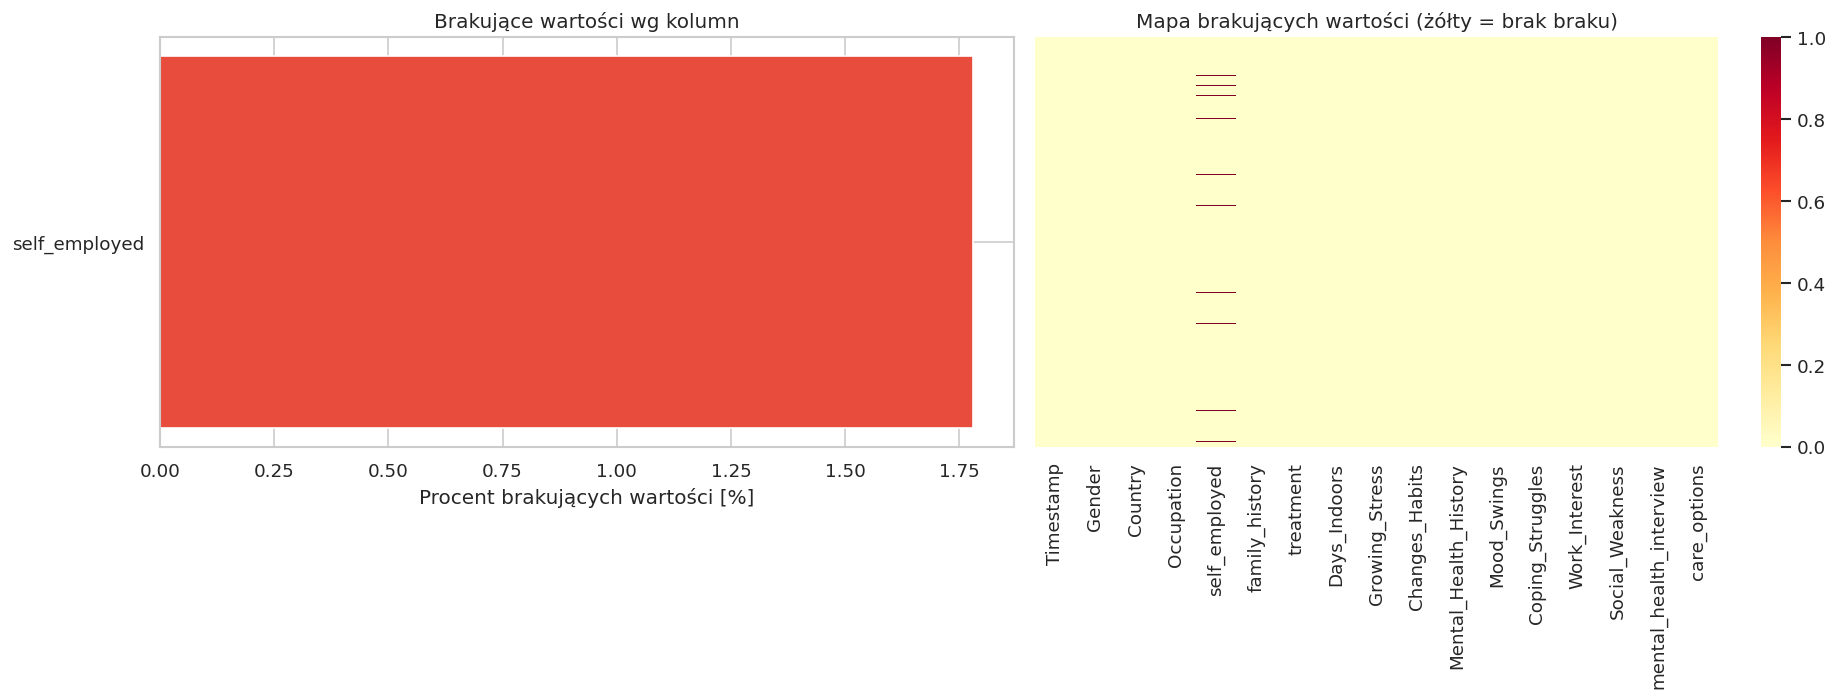

Wykres zapisany: plots/01_missing_values.png


In [7]:
# ======================================
# KROK 5: Analiza brakujących wartości
# ======================================

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Brakujące wartości': missing,
    'Procent [%]': missing_pct
}).sort_values('Procent [%]', ascending=False)

print('Analiza brakujących wartości:')
print(missing_df[missing_df['Brakujące wartości'] > 0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres brakujących wartości
if missing_df['Brakujące wartości'].sum() > 0:
    missing_plot = missing_df[missing_df['Brakujące wartości'] > 0]
    axes[0].barh(missing_plot.index, missing_plot['Procent [%]'], color='#e74c3c', edgecolor='white')
    axes[0].set_xlabel('Procent brakujących wartości [%]')
    axes[0].set_title('Brakujące wartości wg kolumn')
else:
    axes[0].text(0.5, 0.5, 'Brak brakujących wartości!', 
                ha='center', va='center', fontsize=14, color='green',
                transform=axes[0].transAxes)
    axes[0].set_title('Brakujące wartości')

# Heatmapa brakujących wartości
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='YlOrRd',
            ax=axes[1])
axes[1].set_title('Mapa brakujących wartości (żółty = brak braku)')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_missing_values.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/01_missing_values.png')

In [8]:
# =========================================================
# KROK 6: Identyfikacja zmiennej docelowej i analiza klas
# =========================================================

print('Kolumny kategoryczne i ich unikalne wartości:')
for col in df.select_dtypes(include=['object']).columns:
    unique_vals = df[col].nunique()
    print(f'- {col}: {unique_vals} unikalnych wartości → {df[col].unique()[:5]}')

print('\nKolumny numeryczne:')
print(df.select_dtypes(include=[np.number]).columns.tolist())

Kolumny kategoryczne i ich unikalne wartości:
- Timestamp: 580 unikalnych wartości → ['8/27/2014 11:29' '8/27/2014 11:31' '8/27/2014 11:32' '8/27/2014 11:37' '8/27/2014 11:43']
- Gender: 2 unikalnych wartości → ['Female' 'Male']
- Country: 35 unikalnych wartości → ['United States' 'Poland' 'Australia' 'Canada' 'United Kingdom']
- Occupation: 5 unikalnych wartości → ['Corporate' 'Student' 'Business' 'Housewife' 'Others']
- self_employed: 2 unikalnych wartości → [nan 'No' 'Yes']
- family_history: 2 unikalnych wartości → ['No' 'Yes']
- treatment: 2 unikalnych wartości → ['Yes' 'No']
- Days_Indoors: 5 unikalnych wartości → ['1-14 days' 'Go out Every day' 'More than 2 months' '15-30 days' '31-60 days']
- Growing_Stress: 3 unikalnych wartości → ['Yes' 'No' 'Maybe']
- Changes_Habits: 3 unikalnych wartości → ['No' 'Yes' 'Maybe']
- Mental_Health_History: 3 unikalnych wartości → ['Yes' 'No' 'Maybe']
- Mood_Swings: 3 unikalnych wartości → ['Medium' 'Low' 'High']
- Coping_Struggles: 2 unikalnych w

In [9]:
# =========================================
# KROK 7: Identyfikacja kolumny docelowej
# =========================================

print('Kolumny z małą liczbą unikalnych wartości:')
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 10:
        print(f'- {col}: {n_unique} unikalnych → {df[col].value_counts().to_dict()}')

Kolumny z małą liczbą unikalnych wartości:
- Gender: 2 unikalnych → {'Male': 239850, 'Female': 52514}
- Occupation: 5 unikalnych → {'Housewife': 66351, 'Student': 61794, 'Corporate': 61229, 'Others': 52841, 'Business': 50149}
- self_employed: 2 unikalnych → {'No': 257994, 'Yes': 29168}
- family_history: 2 unikalnych → {'No': 176832, 'Yes': 115532}
- treatment: 2 unikalnych → {'Yes': 147606, 'No': 144758}
- Days_Indoors: 5 unikalnych → {'1-14 days': 63548, '31-60 days': 60705, 'Go out Every day': 58366, 'More than 2 months': 55916, '15-30 days': 53829}
- Growing_Stress: 3 unikalnych → {'Maybe': 99985, 'Yes': 99653, 'No': 92726}
- Changes_Habits: 3 unikalnych → {'Yes': 109523, 'Maybe': 95166, 'No': 87675}
- Mental_Health_History: 3 unikalnych → {'No': 104018, 'Maybe': 95378, 'Yes': 92968}
- Mood_Swings: 3 unikalnych → {'Medium': 101064, 'Low': 99834, 'High': 91466}
- Coping_Struggles: 2 unikalnych → {'No': 154328, 'Yes': 138036}
- Work_Interest: 3 unikalnych → {'No': 105843, 'Maybe': 101

In [10]:
# ==========================================================
# KROK 8: Ustawienie zmiennej docelowej/klasy do predykcji
# ==========================================================

TARGET_COLUMN = 'treatment'

print(f'\nRozkład klas w "{TARGET_COLUMN}":')
print(df[TARGET_COLUMN].value_counts())
print(f'\nProporcje klas:')
print(df[TARGET_COLUMN].value_counts(normalize=True).round(3))


Rozkład klas w "treatment":
treatment
Yes    147606
No     144758
Name: count, dtype: int64

Proporcje klas:
treatment
Yes    0.505
No     0.495
Name: proportion, dtype: float64


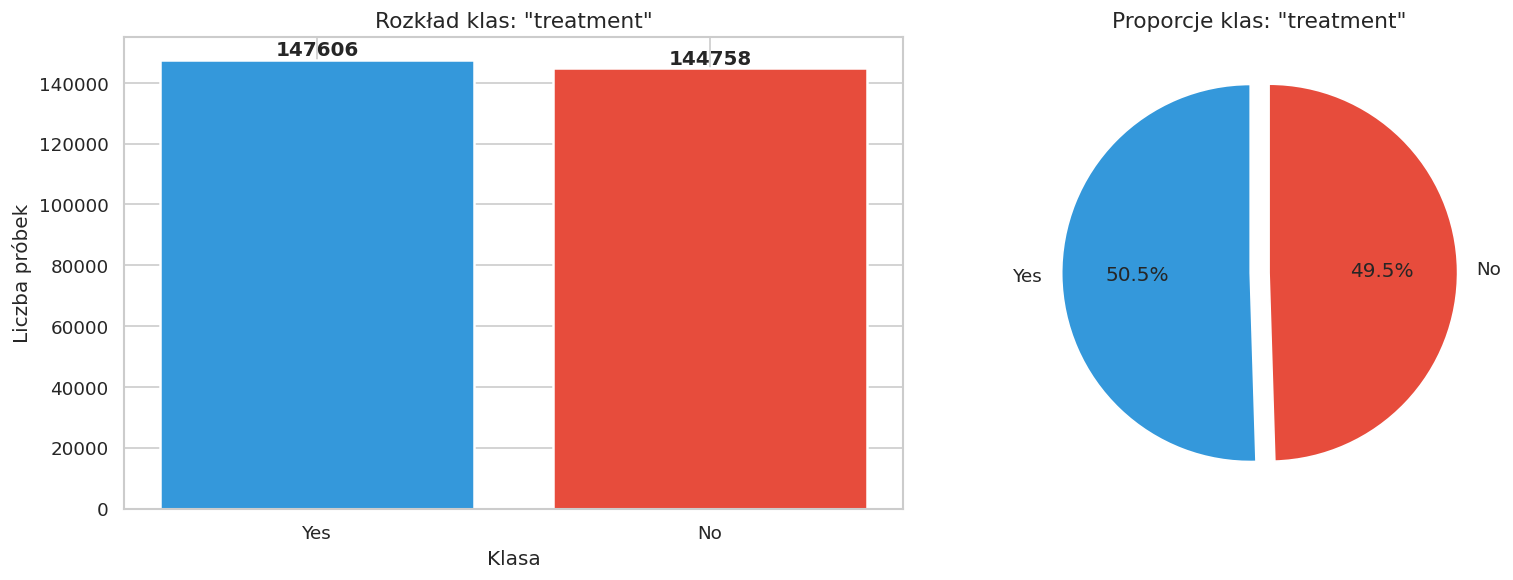

Wykres zapisany: plots/02_class_distribution.png


In [11]:
# =============================================
# KROK 9: Wizualizacja rozkładu klas targetu
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df[TARGET_COLUMN].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Wykres słupkowy
bars = axes[0].bar(class_counts.index.astype(str), class_counts.values, 
                   color=colors[:len(class_counts)], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title(f'Rozkład klas: "{TARGET_COLUMN}"', fontsize=13)
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Liczba próbek')

# Wykres kołowy
axes[1].pie(class_counts.values, labels=class_counts.index.astype(str),
            autopct='%1.1f%%', colors=colors[:len(class_counts)],
            startangle=90, explode=[0.05]*len(class_counts))
axes[1].set_title(f'Proporcje klas: "{TARGET_COLUMN}"', fontsize=13)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_class_distribution.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/02_class_distribution.png')

In [12]:
# ===========================================
# KROK 10: EDA – Rozkłady cech numerycznych
# ===========================================

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Kolumny numeryczne ({len(num_cols)}): {num_cols}')

if len(num_cols) > 0:
    n_cols_plot = min(len(num_cols), 12)
    n_rows_plot = (n_cols_plot + 2) // 3
    
    fig, axes = plt.subplots(n_rows_plot, 3, figsize=(18, n_rows_plot * 4))
    axes = axes.flatten() if n_rows_plot > 1 else [axes] if n_cols_plot == 1 else axes.flatten()
    
    for idx, col in enumerate(num_cols[:n_cols_plot]):
        ax = axes[idx]
        data_col = df[col].dropna()
        ax.hist(data_col, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
        ax.axvline(data_col.mean(), color='red', linestyle='--', label=f'Śr: {data_col.mean():.2f}')
        ax.axvline(data_col.median(), color='green', linestyle=':', label=f'Med: {data_col.median():.2f}')
        ax.set_title(f'{col}', fontsize=11)
        ax.set_xlabel('Wartość')
        ax.set_ylabel('Częstość')
        ax.legend(fontsize=8)
    
    for idx in range(n_cols_plot, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Rozkłady cech numerycznych', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/03_numeric_distributions.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres zapisany: {PLOTS_DIR}/03_numeric_distributions.png')
else:
    print('Brak kolumn numerycznych')

Kolumny numeryczne (0): []
Brak kolumn numerycznych


Kolumny kategoryczne (16): ['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']


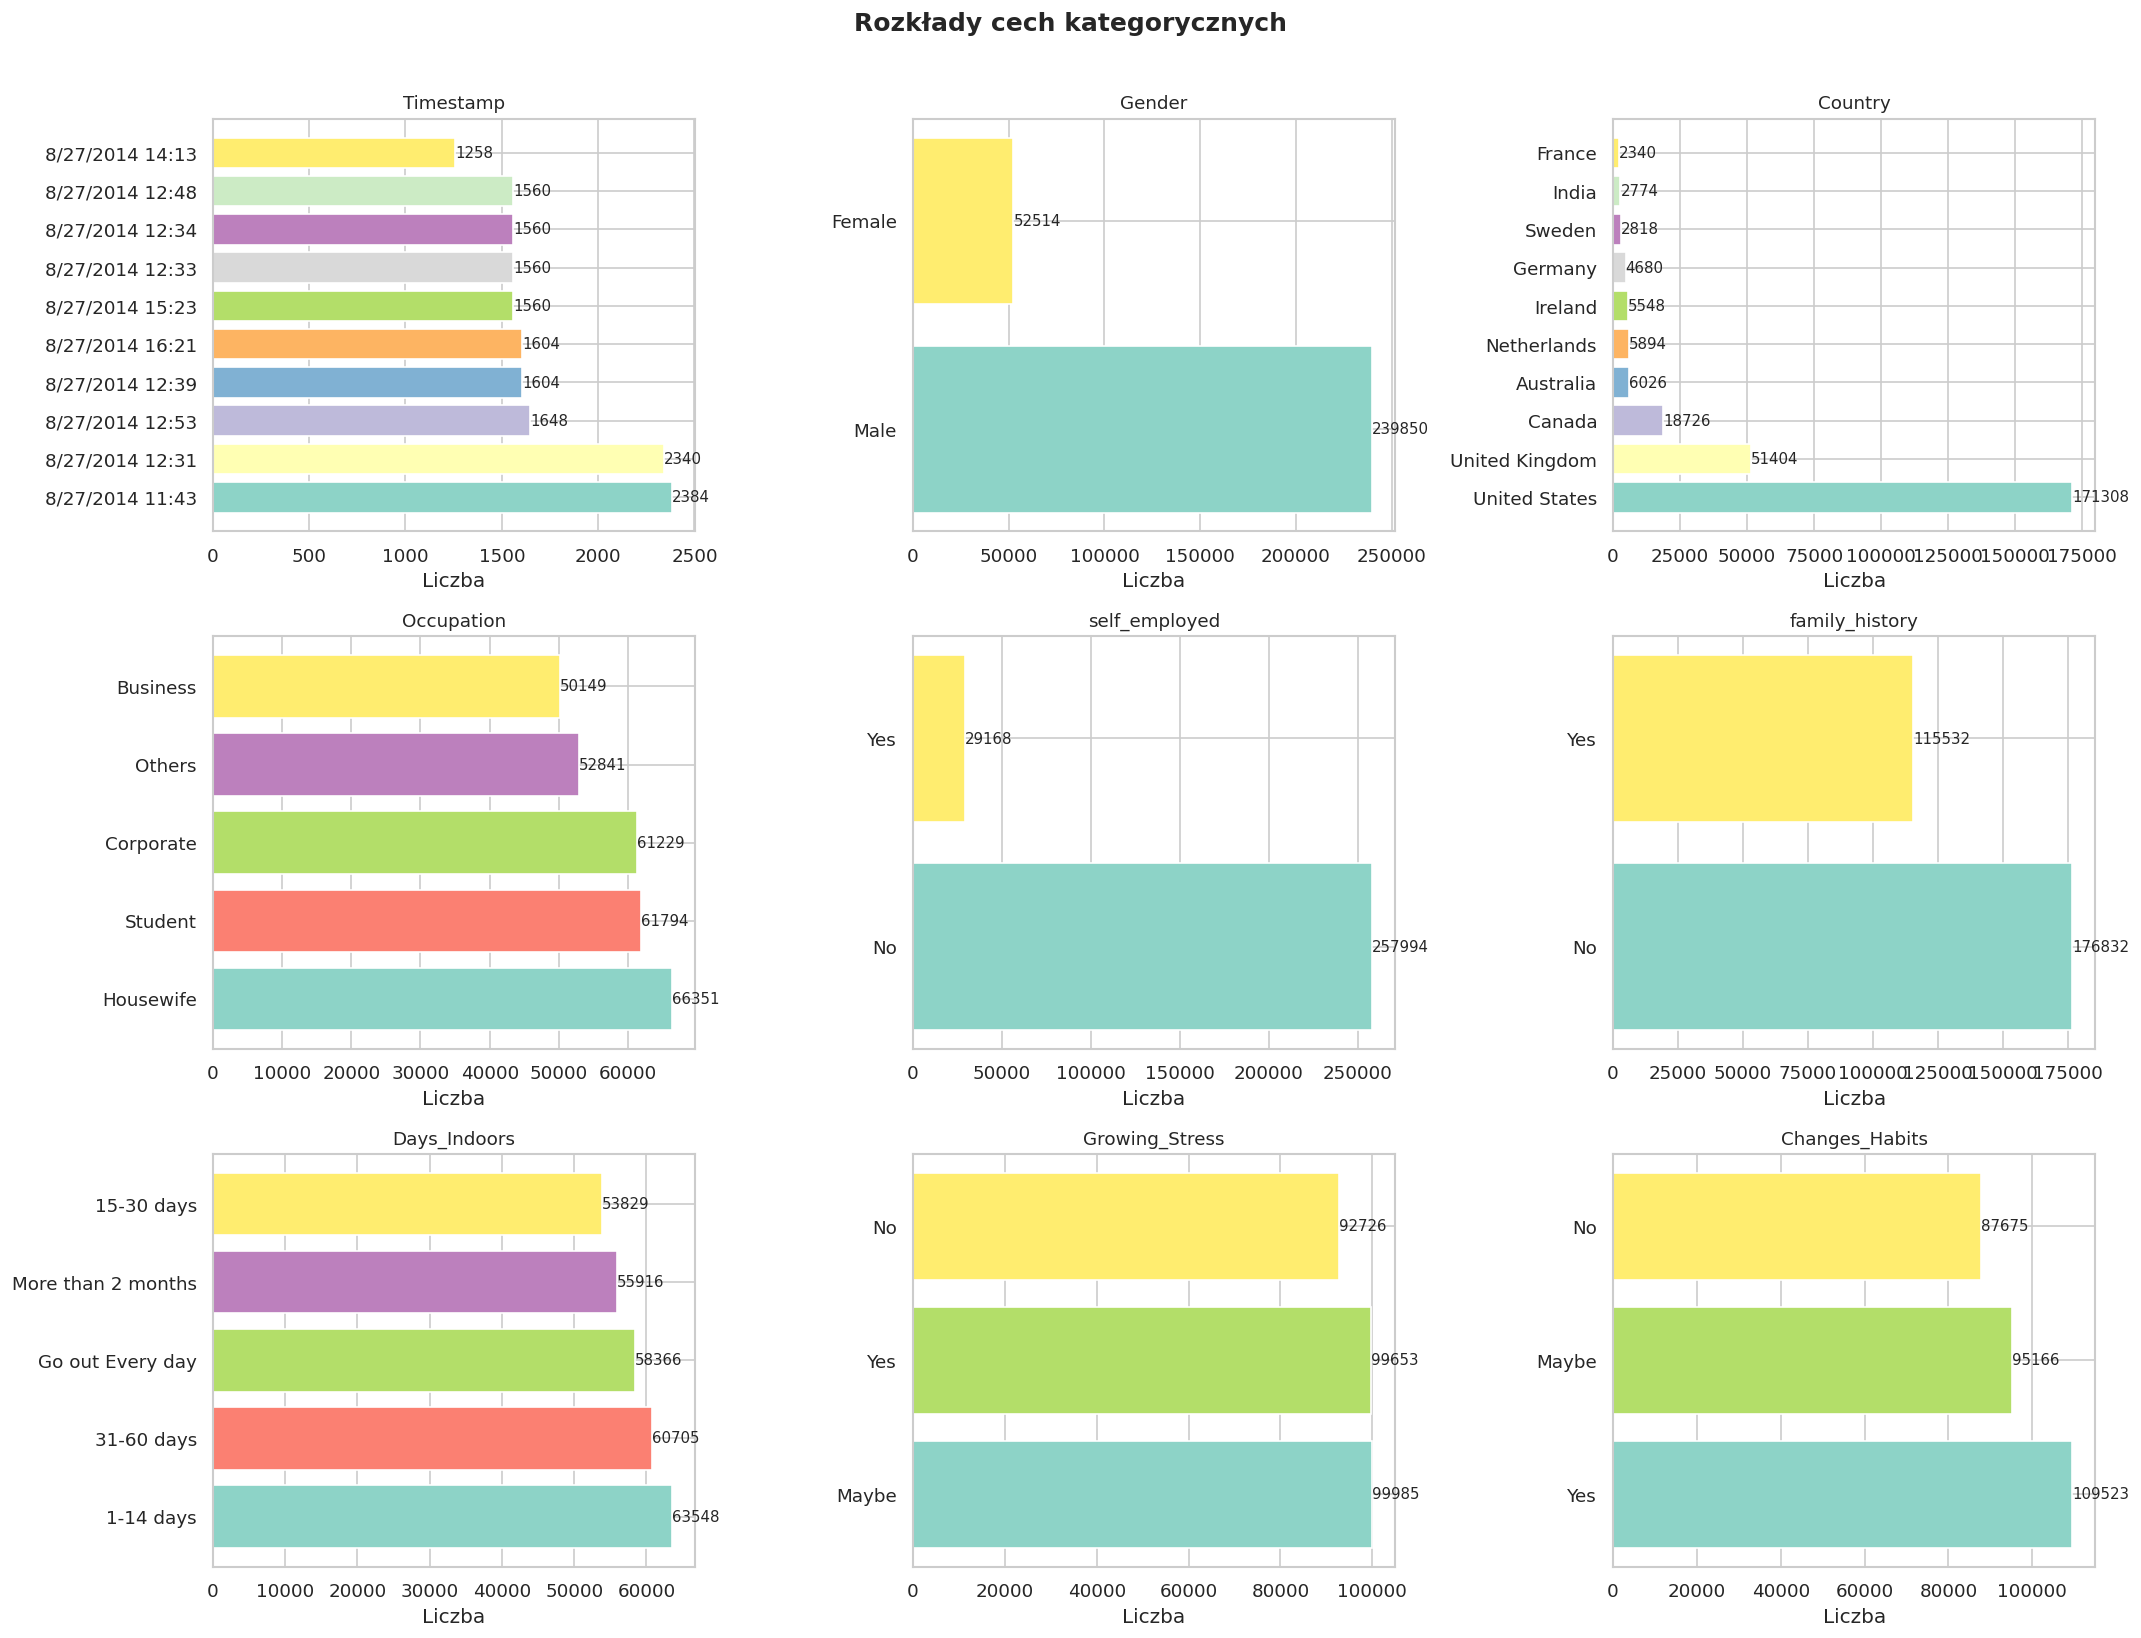

Wykres zapisany: plots/04_categorical_distributions.png


In [13]:
# =====================================
# KROK 11: EDA – Kolumny kategoryczne
# =====================================

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if TARGET_COLUMN in cat_cols:
    cat_cols.remove(TARGET_COLUMN)

print(f'Kolumny kategoryczne ({len(cat_cols)}): {cat_cols}')

if len(cat_cols) > 0:
    n_show = min(len(cat_cols), 9)
    n_rows_plot = (n_show + 2) // 3
    
    fig, axes = plt.subplots(n_rows_plot, 3, figsize=(18, n_rows_plot * 4.5))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for idx, col in enumerate(cat_cols[:n_show]):
        ax = axes_flat[idx]
        val_counts = df[col].value_counts().head(10)
        colors_bar = plt.cm.Set3(np.linspace(0, 1, len(val_counts)))
        bars = ax.barh(val_counts.index.astype(str), val_counts.values, 
                      color=colors_bar, edgecolor='white')
        for bar, val in zip(bars, val_counts.values):
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                   str(val), va='center', fontsize=9)
        ax.set_title(f'{col}', fontsize=11)
        ax.set_xlabel('Liczba')
    
    for idx in range(n_show, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.suptitle('Rozkłady cech kategorycznych', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/04_categorical_distributions.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres zapisany: {PLOTS_DIR}/04_categorical_distributions.png')

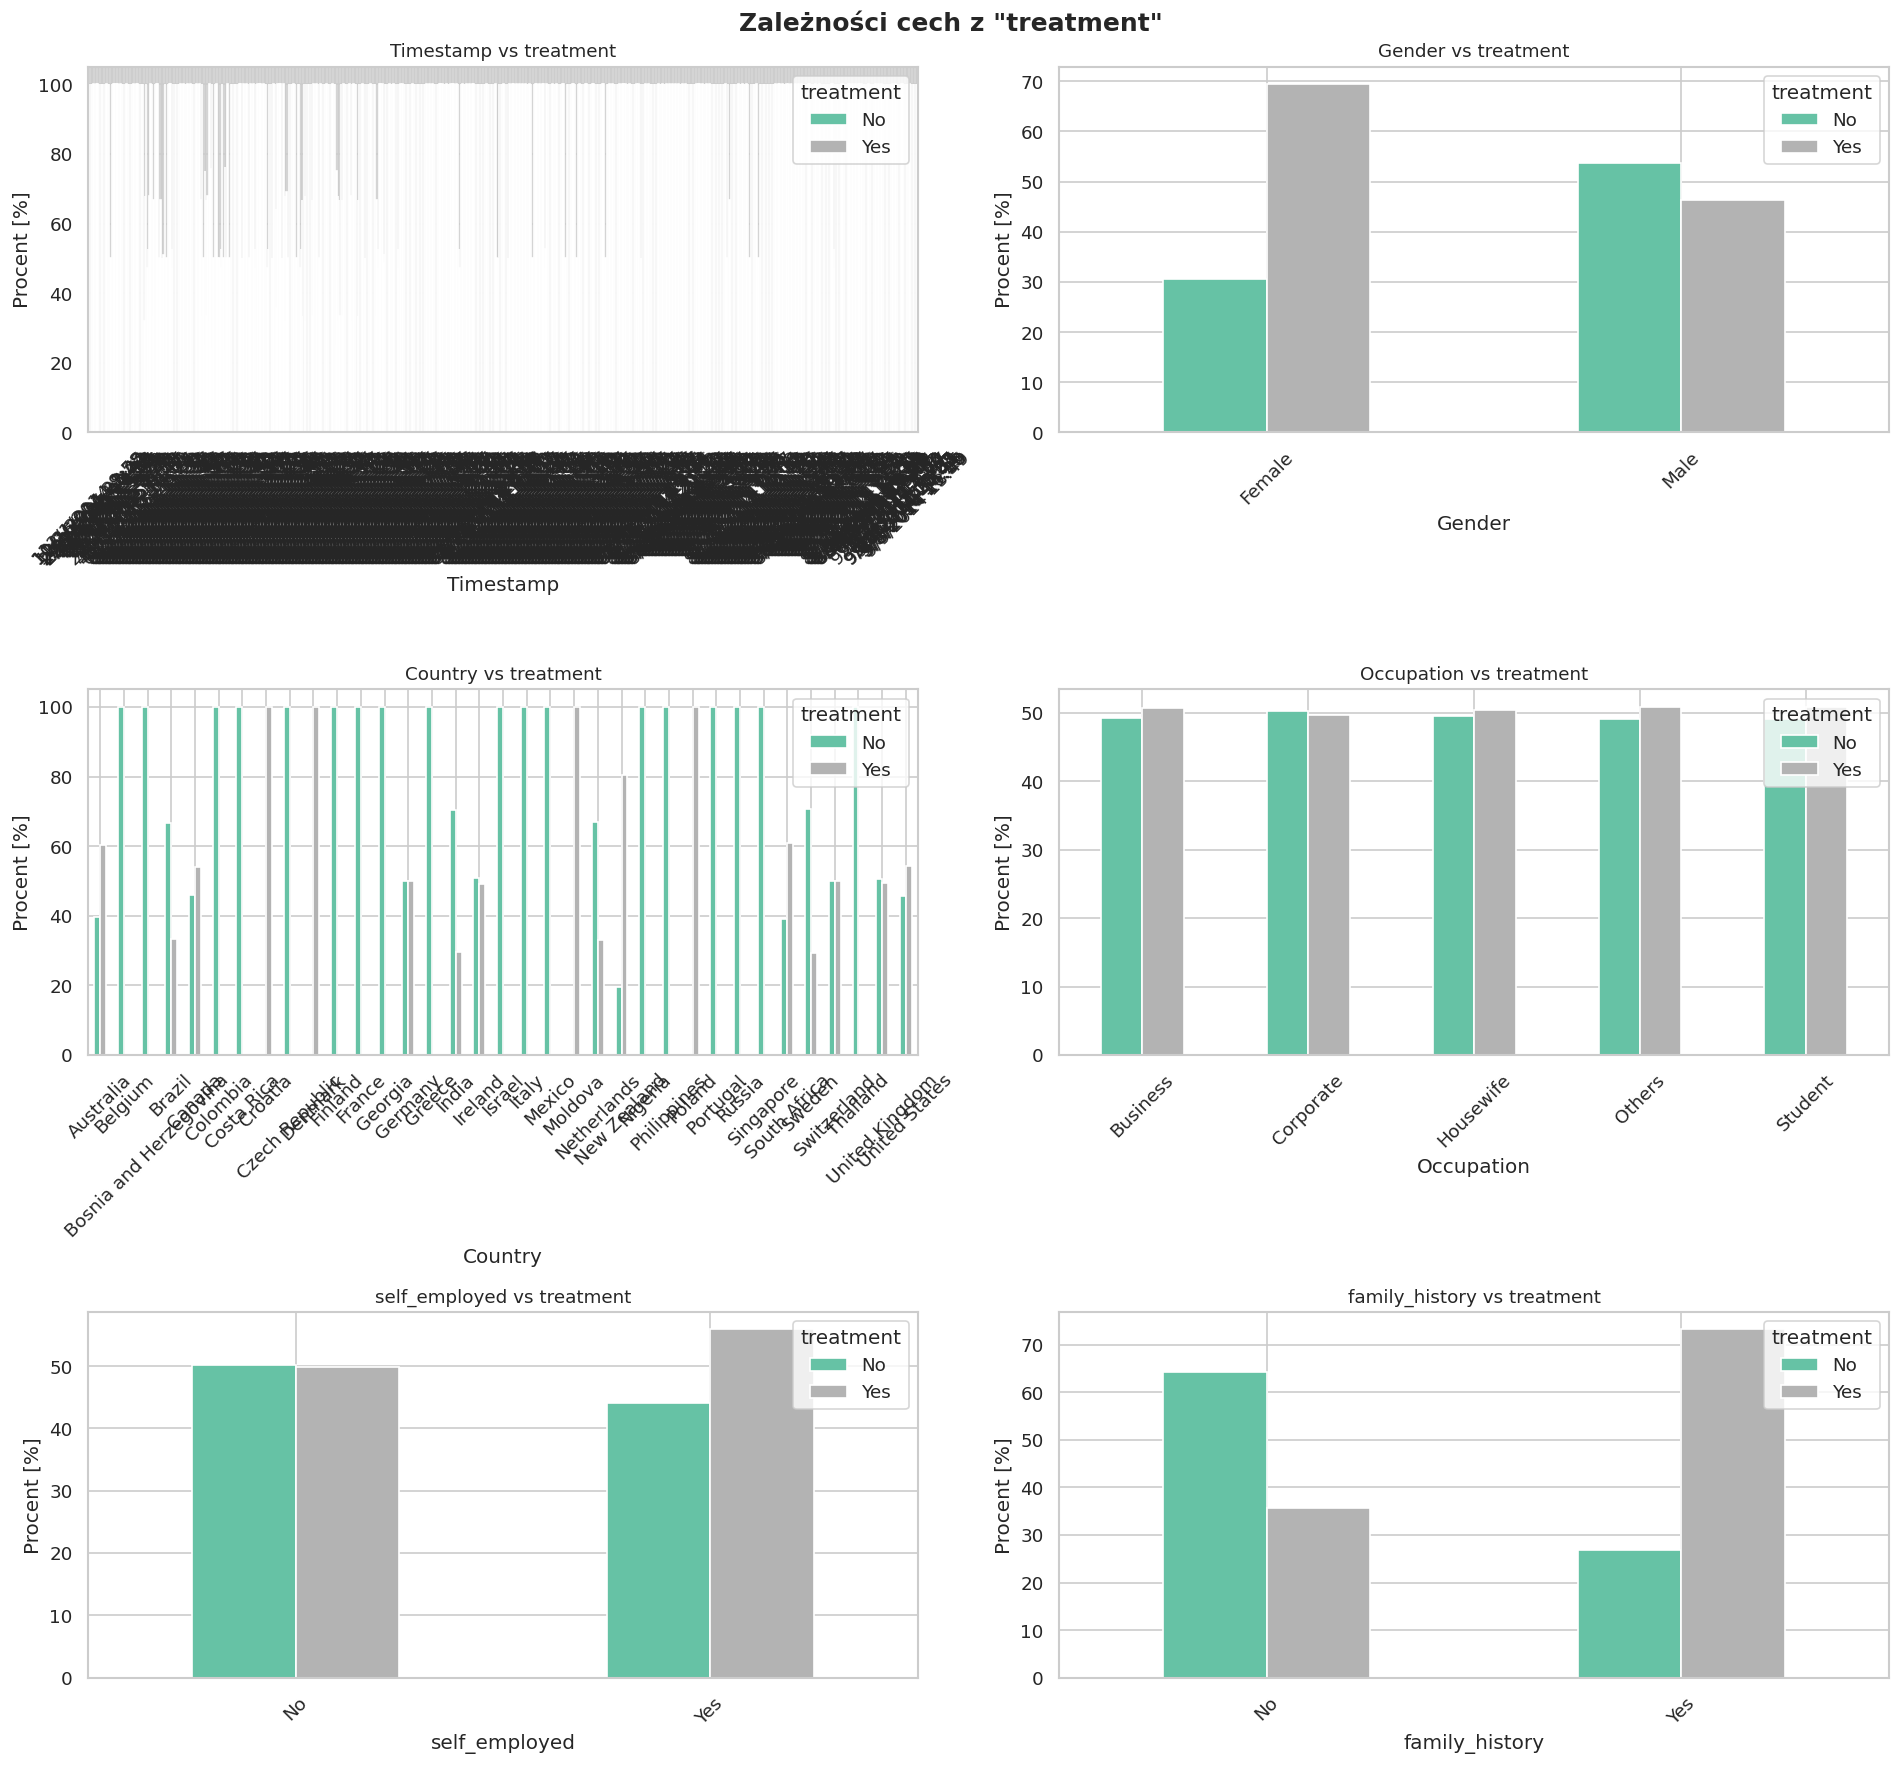

Wykres zapisany: plots/05_feature_vs_target.png


In [14]:
# ===================================================
# KROK 12: EDA – Analiza zależności cech z targetem
# ===================================================

cat_cols_for_target = df.select_dtypes(include=['object']).columns.tolist()
if TARGET_COLUMN in cat_cols_for_target:
    cat_cols_for_target.remove(TARGET_COLUMN)

if len(cat_cols_for_target) > 0:
    n_show = min(len(cat_cols_for_target), 6)
    n_rows_plot = (n_show + 1) // 2
    
    fig, axes = plt.subplots(n_rows_plot, 2, figsize=(16, n_rows_plot * 5))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for idx, col in enumerate(cat_cols_for_target[:n_show]):
        ax = axes_flat[idx]
        ct = pd.crosstab(df[col], df[TARGET_COLUMN], normalize='index') * 100
        ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
        ax.set_title(f'{col} vs {TARGET_COLUMN}', fontsize=11)
        ax.set_ylabel('Procent [%]')
        ax.set_xlabel(col)
        ax.legend(title=TARGET_COLUMN, loc='upper right')
        ax.tick_params(axis='x', rotation=45)
    
    for idx in range(n_show, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.suptitle(f'Zależności cech z "{TARGET_COLUMN}"', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/05_feature_vs_target.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres zapisany: {PLOTS_DIR}/05_feature_vs_target.png')

In [15]:
# =================================
# KROK 13: EDA – Macierz korelacji 
# =================================

num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

if len(num_cols_all) >= 2:
    corr_matrix = df[num_cols_all].corr()
    
    fig, ax = plt.subplots(figsize=(max(10, len(num_cols_all)), max(8, len(num_cols_all))))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, mask=mask,
                square=True, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Korelacja Pearsona'})
    ax.set_title('Macierz korelacji cech numerycznych', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/06_correlation_matrix.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres zapisany: {PLOTS_DIR}/06_correlation_matrix.png')
else:
    print('Za mało kolumn numerycznych do macierzy korelacji')

Za mało kolumn numerycznych do macierzy korelacji


---
##  CZĘŚĆ 2: Preprocessing Danych


In [16]:
# =====================================
# KROK 14: Preprocessing – enkodowanie
# =====================================

df_processed = df.copy()

# usuwanie duplikatow
n_before = len(df_processed)
df_processed = df_processed.drop_duplicates()
n_removed = n_before - len(df_processed)
print(f'Usunięto duplikatów: {n_removed}')

# ujednolicenie wartości tekstowych
for col in df_processed.select_dtypes(include=['object']).columns:
    df_processed[col] = df_processed[col].str.strip().str.lower()

# enkodowanie zmiennej docelowej
le_target = LabelEncoder()
y_raw = df_processed[TARGET_COLUMN]
y_encoded = le_target.fit_transform(y_raw)
target_classes = le_target.classes_
print(f'Klasy docelowe: {target_classes}')
print(f'Zakodowano: {dict(zip(target_classes, range(len(target_classes))))}')

# enkodowanie cech kategorycznych
X_df = df_processed.drop(columns=[TARGET_COLUMN])
cat_cols_enc = X_df.select_dtypes(include=['object']).columns.tolist()
print(f'Enkodowanie {len(cat_cols_enc)} kolumn kategorycznych...')

label_encoders = {}
for col in cat_cols_enc:
    le = LabelEncoder()
    X_df[col] = le.fit_transform(X_df[col].astype(str))
    label_encoders[col] = le

# imputacja brakujących wartości
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_df)
X_df_clean = pd.DataFrame(X_imputed, columns=X_df.columns)

feature_names = X_df_clean.columns.tolist()
print(f'\nPreprocessing zakończony!')
print(f'Wymiary X: {X_df_clean.shape}')
print(f'Liczba cech: {len(feature_names)}')
print(f'Rozkład klas y: {dict(zip(*np.unique(y_encoded, return_counts=True)))}')

Usunięto duplikatów: 2313
Klasy docelowe: ['no' 'yes']
Zakodowano: {'no': 0, 'yes': 1}
Enkodowanie 16 kolumn kategorycznych...

Preprocessing zakończony!
Wymiary X: (290051, 16)
Liczba cech: 16
Rozkład klas y: {np.int64(0): np.int64(143867), np.int64(1): np.int64(146184)}


In [17]:
# =================================================
# KROK 15: Podział na train/val/test i skalowanie
# =================================================

X = X_df_clean.values
y = y_encoded

# podział: 70% train, 15% val, 15% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=RANDOM_STATE, stratify=y_train_full
) 

# Skalowanie
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Podział datasetu:')
print(f'  Train: {X_train.shape[0]} próbek ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Val:   {X_val.shape[0]} próbek ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'  Test:  {X_test.shape[0]} próbek ({X_test.shape[0]/len(X)*100:.1f}%)')

save_checkpoint({'scaler': scaler, 'imputer': imputer, 'label_encoders': label_encoders, 'le_target': le_target}, 'preprocessors')

Podział datasetu:
  Train: 203151 próbek (70.0%)
  Val:   43392 próbek (15.0%)
  Test:  43508 próbek (15.0%)
Checkpoint zapisany: checkpoints/preprocessors.pkl


'checkpoints/preprocessors.pkl'

In [18]:
# ==================================
# KROK 16: Balansowanie klas SMOTE
# ==================================

class_counts_train = np.unique(y_train, return_counts=True)
max_count = class_counts_train[1].max()
min_count = class_counts_train[1].min()
imbalance_ratio = max_count / min_count

print(f'Wskaźnik nierównowagi klas: {imbalance_ratio:.2f}')

USE_SMOTE = imbalance_ratio > 1.5

if USE_SMOTE:
    print(f'Wykryto nierównowagę (ratio={imbalance_ratio:.2f}) → Stosuję SMOTE')
    try:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, min_count-1))
        X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        print(f'Po SMOTE: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}')
    except Exception as e:
        print(f'SMOTE nie powiódł się: {e} → Używam oryginalnych danych')
        X_train_bal, y_train_bal = X_train, y_train
else:
    print('Klasy względnie zbalansowane')
    X_train_bal, y_train_bal = X_train, y_train

n_classes = len(np.unique(y))
IS_BINARY = n_classes == 2
print(f'\nZadanie: {"binarne" if IS_BINARY else f"wieloklasowe ({n_classes} klas)"}'
      f' | Liczba cech: {X_train.shape[1]}')

Wskaźnik nierównowagi klas: 1.02
Klasy względnie zbalansowane

Zadanie: binarne | Liczba cech: 16


---
##  CZĘŚĆ 3: Modele Bazowe (Baseline)


In [19]:
# ====================================
# KROK 17: Definicja modeli bazowych
# ====================================

xgb_obj = 'binary:logistic' if IS_BINARY else 'multi:softmax'
xgb_eval = 'logloss' if IS_BINARY else 'mlogloss'

baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        random_state=RANDOM_STATE
    ),
    'SVM': LinearSVC(
        C=1.0, random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=7, metric='euclidean', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        base_score=0.5,
        objective=xgb_obj, eval_metric=xgb_eval,
        use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

print(f'Zdefiniowano {len(baseline_models)} modeli bazowych:')
for name in baseline_models:
    print(f'  - {name}')

Zdefiniowano 7 modeli bazowych:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - SVM
  - KNN
  - XGBoost


In [20]:
# ==============================================
# KROK 18: Trening i ewaluacja modeli bazowych
# ==============================================

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, is_binary=True):
    """Trenuj i ewaluuj model, zwróć słownik wyników."""
    start = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='binary' if is_binary else 'weighted')
    prec = precision_score(y_te, y_pred, average='binary' if is_binary else 'weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='binary' if is_binary else 'weighted', zero_division=0)
    
    auc = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)
        if is_binary:
            auc = roc_auc_score(y_te, y_prob[:, 1])
        else:
            auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted')
            
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
        if is_binary:
            auc = roc_auc_score(y_te, y_score)
        else:
            auc = roc_auc_score(y_te, y_score, multi_class='ovr', average='weighted')
    
    return {
        'model': model,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': prec,
        'Recall': rec,
        'AUC-ROC': auc if auc else 0.0,
        'Time [s]': elapsed
    }

baseline_results = {}
print('Trening modeli bazowych')
print('-'*60)

for name, model in baseline_models.items():
    print(f'  {name}...', end=' ')
    result = evaluate_model(name, model, X_train_bal, y_train_bal, X_test, y_test, IS_BINARY)
    baseline_results[name] = result
    print(f'Acc={result["Accuracy"]:.4f} | F1={result["F1-Score"]:.4f} | AUC={result["AUC-ROC"]:.4f} | {result["Time [s]"]:.1f}s')


results_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'model'}
    for name, res in baseline_results.items()
}).T.sort_values('Accuracy', ascending=False)

save_checkpoint(results_df, 'baseline_results')
print('\nPodsumowanie wyników:')
results_df.round(4)

Trening modeli bazowych...
------------------------------------------------------------
  Logistic Regression... Acc=0.6972 | F1=0.7036 | AUC=0.7560 | 0.1s
  Decision Tree... Acc=0.7423 | F1=0.7486 | AUC=0.8041 | 0.3s
  Random Forest... Acc=0.8261 | F1=0.8291 | AUC=0.9218 | 3.3s
  Gradient Boosting... Acc=0.9506 | F1=0.9502 | AUC=0.9905 | 32.2s
  SVM... Acc=0.6937 | F1=0.6940 | AUC=0.7559 | 0.2s
  KNN... Acc=0.6937 | F1=0.6985 | AUC=0.7516 | 0.0s
  XGBoost... Acc=0.9408 | F1=0.9405 | AUC=0.9890 | 0.4s
Checkpoint zapisany: checkpoints/baseline_results.pkl

Podsumowanie wyników:


,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Time [s]
Gradient Boosting,0.9506,0.9502,0.9658,0.9352,0.9905,32.2044
XGBoost,0.9408,0.9405,0.9537,0.9276,0.9890,0.3786
Random Forest,0.8261,0.8291,0.8214,0.8370,0.9218,3.2887
Decision Tree,0.7423,0.7486,0.7364,0.7613,0.8041,0.3339
Logistic Regression,0.6972,0.7036,0.6944,0.7130,0.7560,0.0556
SVM,0.6937,0.6940,0.6990,0.6892,0.7559,0.2105
KNN,0.6937,0.6985,0.6931,0.7041,0.7516,0.0148


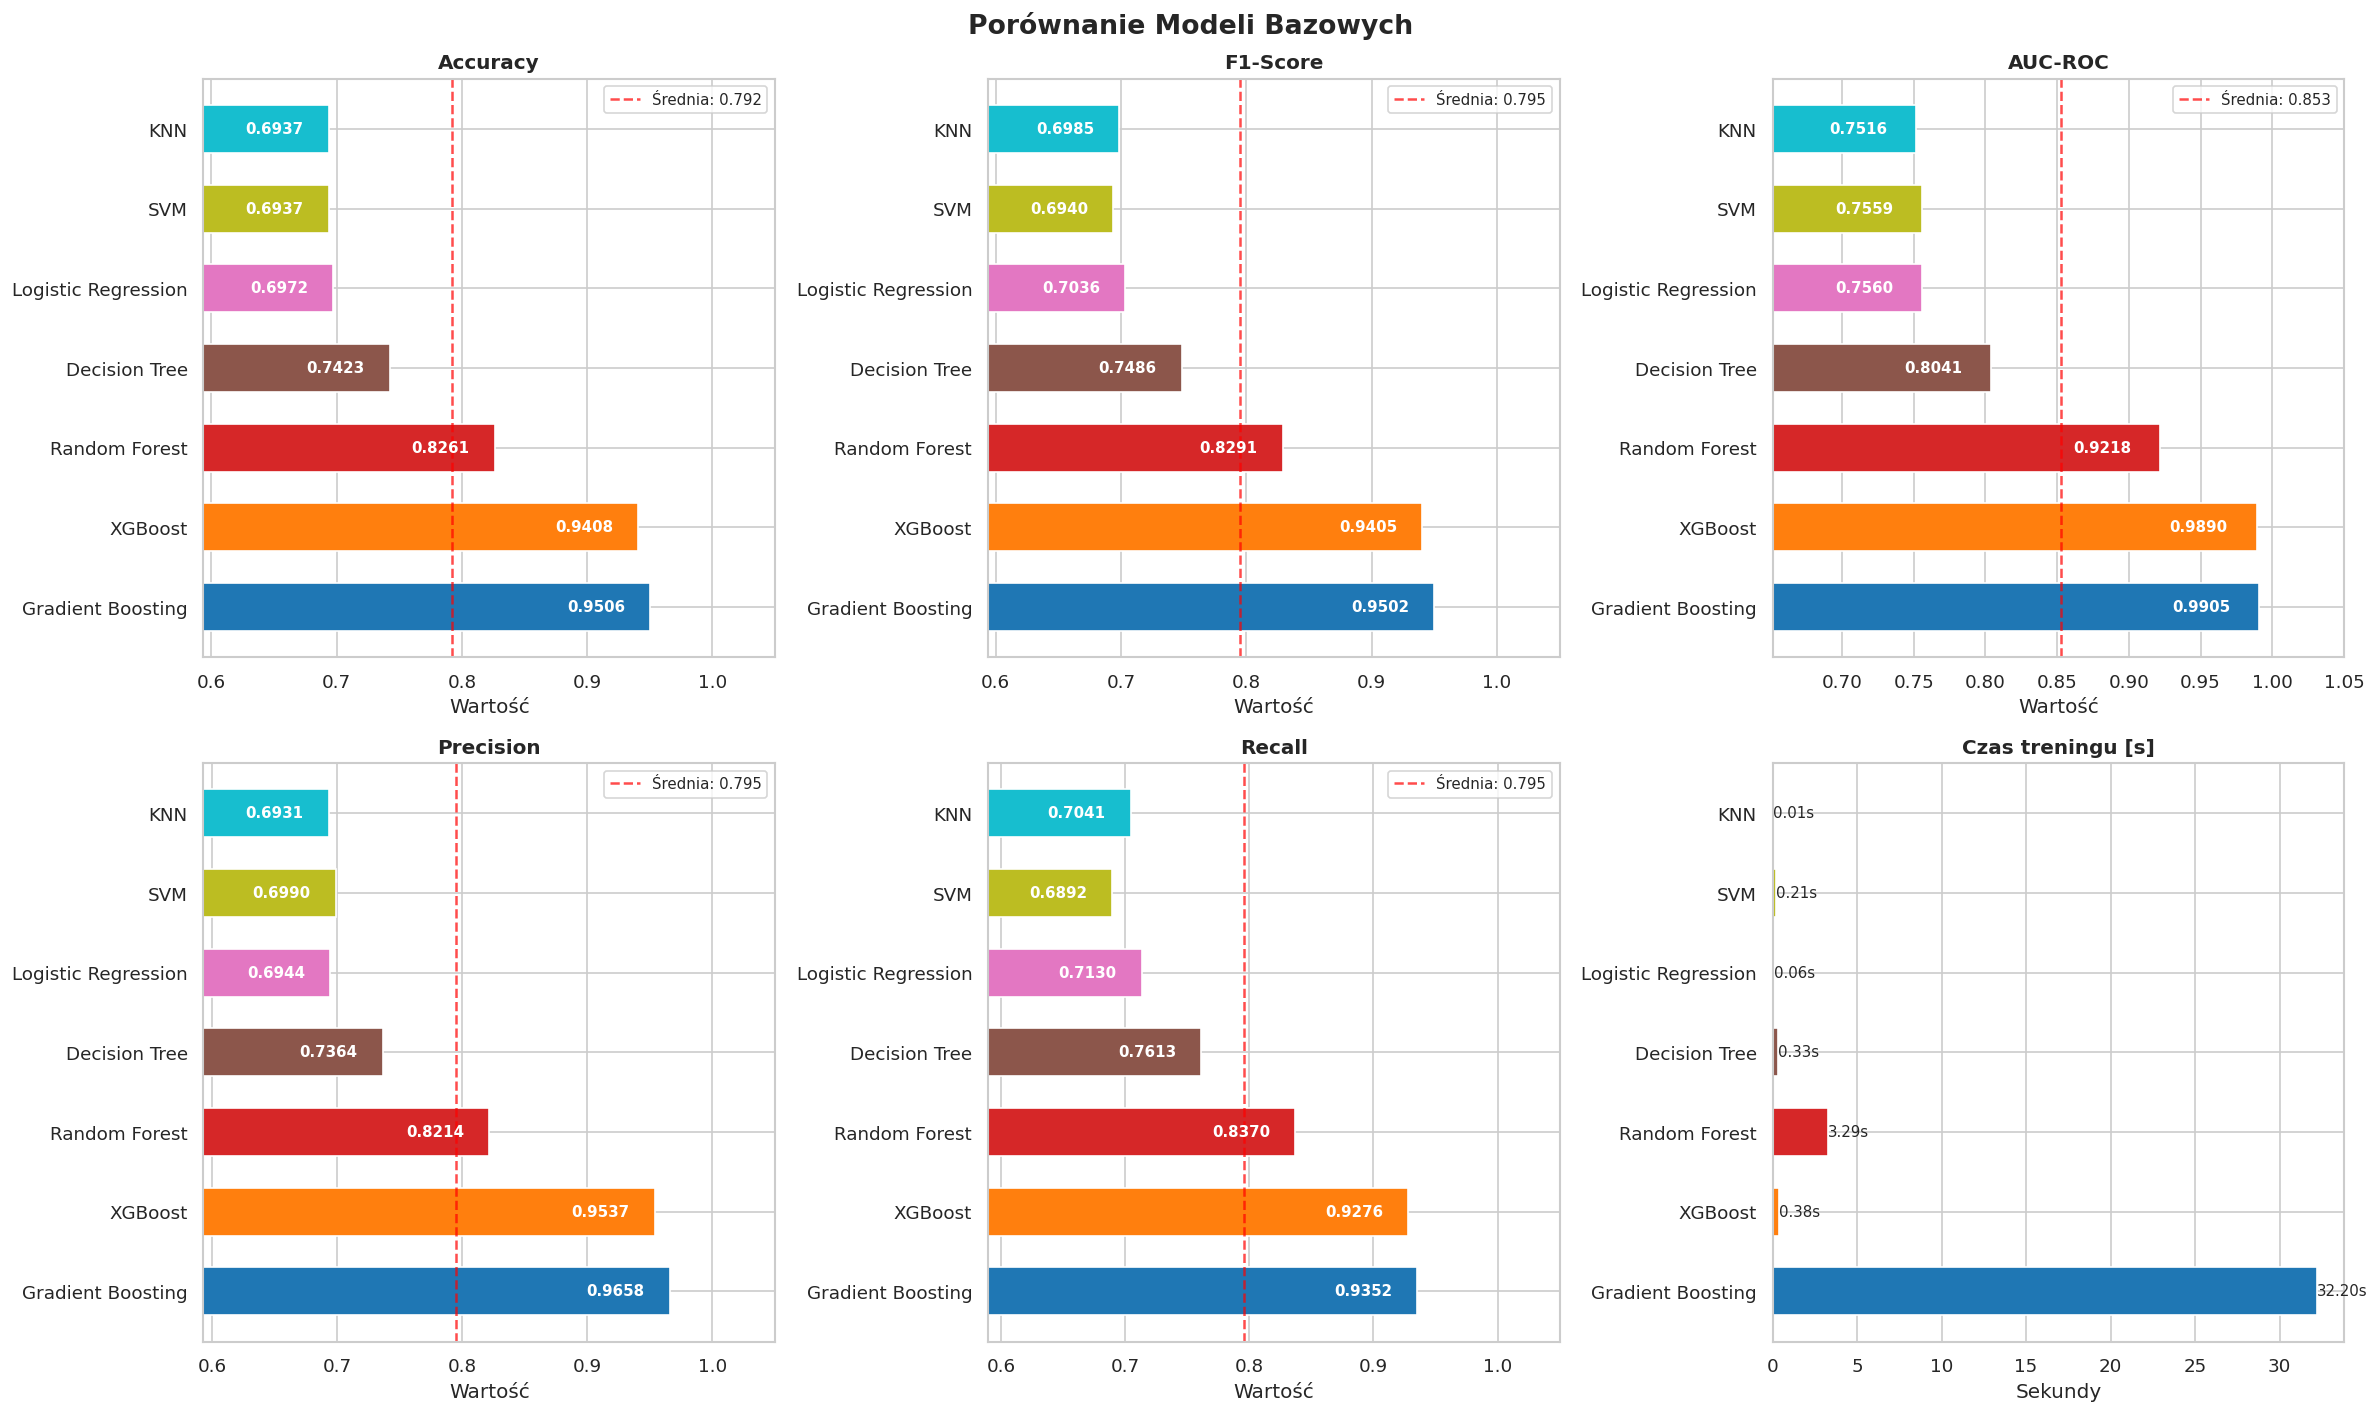

Wykres zapisany: plots/07_baseline_comparison.png

Najlepszy model bazowy: Gradient Boosting (Accuracy=0.9506)


In [21]:
# ==================================================
# KROK 19: Wizualizacja porównania modeli bazowych
# ==================================================

metrics = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Precision', 'Recall']
model_names = results_df.index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

colors_palette = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    vals = results_df[metric].values.astype(float)
    bars = ax.barh(model_names, vals, color=colors_palette, edgecolor='white', height=0.6)
    for bar, val in zip(bars, vals):
        ax.text(max(val - 0.02, 0.01), bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)
    ax.set_xlim(max(0, min(vals) - 0.1), 1.05)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Wartość')
    ax.axvline(x=vals.mean(), color='red', linestyle='--', alpha=0.7, label=f'Średnia: {vals.mean():.3f}')
    ax.legend(fontsize=9)

# czasy
ax = axes_flat[5]
times = results_df['Time [s]'].values.astype(float)
bars = ax.barh(model_names, times, color=colors_palette, edgecolor='white', height=0.6)
for bar, val in zip(bars, times):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
           f'{val:.2f}s', va='center', fontsize=9)
ax.set_title('Czas treningu [s]', fontsize=12, fontweight='bold')
ax.set_xlabel('Sekundy')

plt.suptitle('Porównanie Modeli Bazowych', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/07_baseline_comparison.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/07_baseline_comparison.png')

best_baseline = results_df['Accuracy'].idxmax()
print(f'\nNajlepszy model bazowy: {best_baseline} (Accuracy={results_df.loc[best_baseline, "Accuracy"]:.4f})')

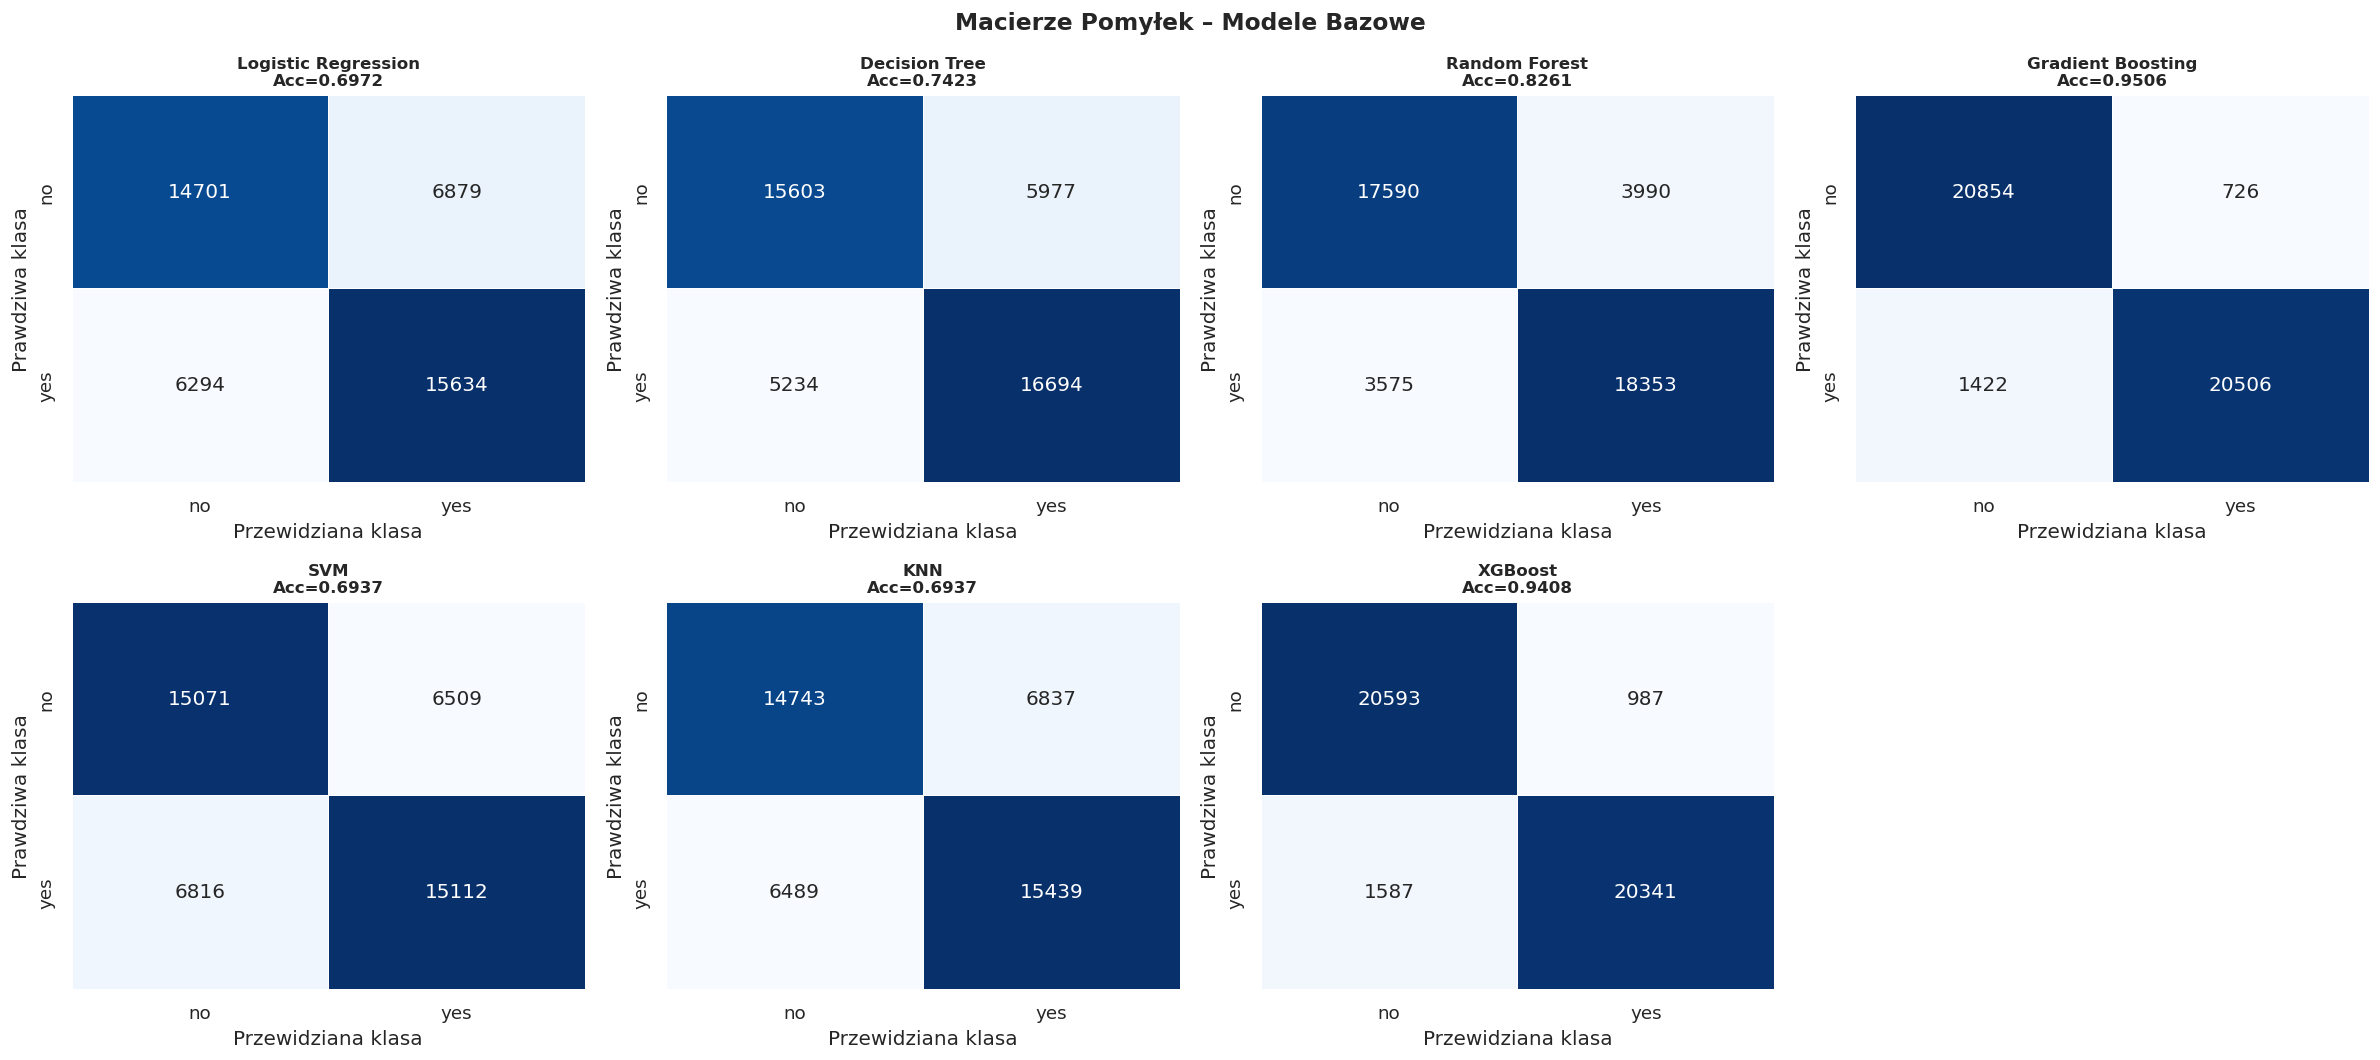

Wykres zapisany: plots/08_confusion_matrices.png


In [22]:
# =================================================
# KROK 20: Macierze pomyłek dla wszystkich modeli
# =================================================

n_models = len(baseline_models)
n_cols_cm = 4
n_rows_cm = (n_models + n_cols_cm - 1) // n_cols_cm

fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(n_cols_cm * 5, n_rows_cm * 4.5))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for idx, (name, res) in enumerate(baseline_results.items()):
    ax = axes_flat[idx]
    model = res['model']
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=target_classes, yticklabels=target_classes,
               linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAcc={res["Accuracy"]:.4f}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Prawdziwa klasa')
    ax.set_xlabel('Przewidziana klasa')

for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Macierze Pomyłek – Modele Bazowe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/08_confusion_matrices.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/08_confusion_matrices.png')

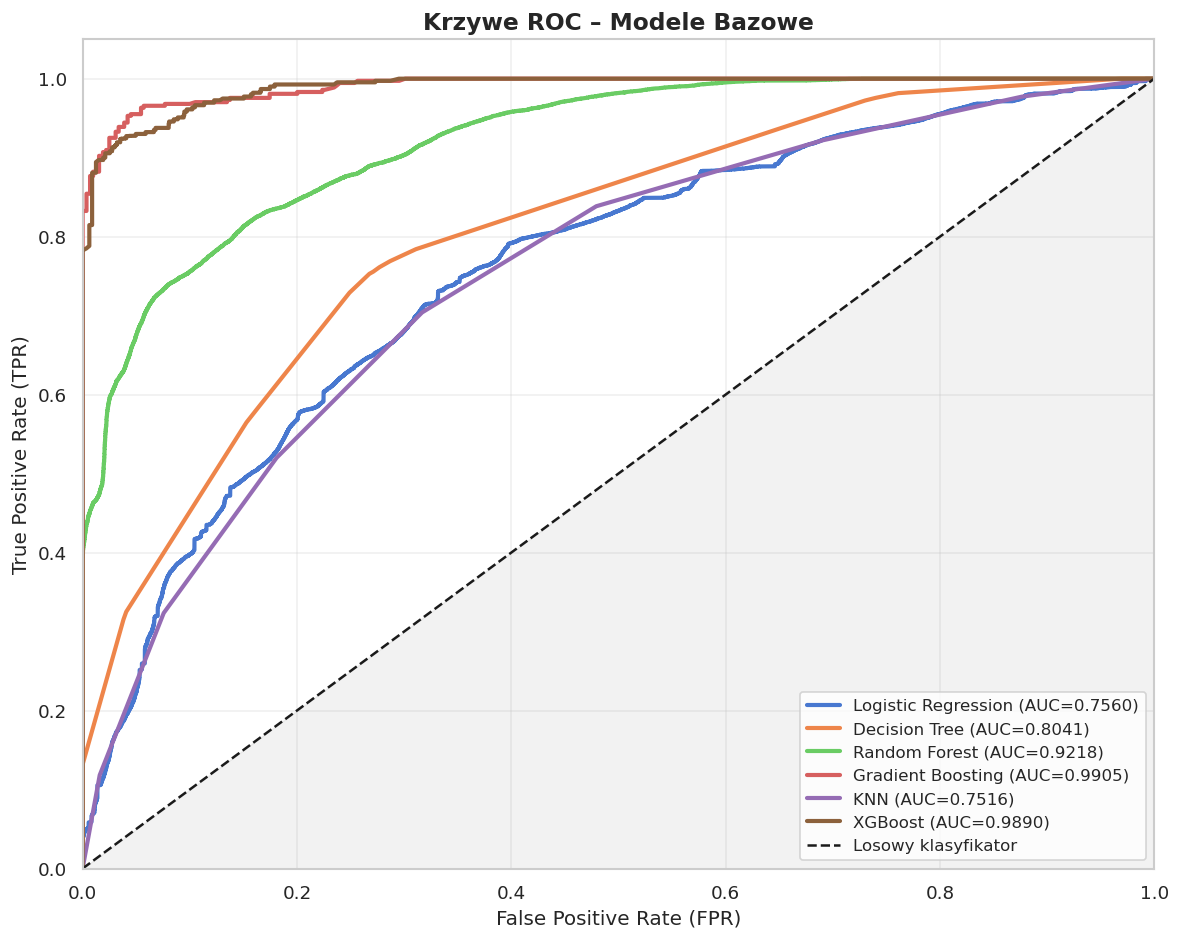

Wykres zapisany: plots/09_roc_curves.png


In [23]:
# =========================================
# KROK 21: Krzywe ROC dla modeli bazowych
# =========================================
if IS_BINARY:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for name, res in baseline_results.items():
        model = res['model']
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            ax.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={auc:.4f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Losowy klasyfikator')
    ax.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
    ax.set_title('Krzywe ROC – Modele Bazowe', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/09_roc_curves.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres zapisany: {PLOTS_DIR}/09_roc_curves.png')
else:
    print('nie dotyczy')

---
##  CZĘŚĆ 4: Optymalizacja XGBoost


Walidacja krzyżowa
  Logistic Regression... CV Mean=0.6976 ± 0.0004
  Random Forest... CV Mean=0.8262 ± 0.0005
  Gradient Boosting... CV Mean=0.9551 ± 0.0033
  XGBoost... CV Mean=0.9470 ± 0.0028


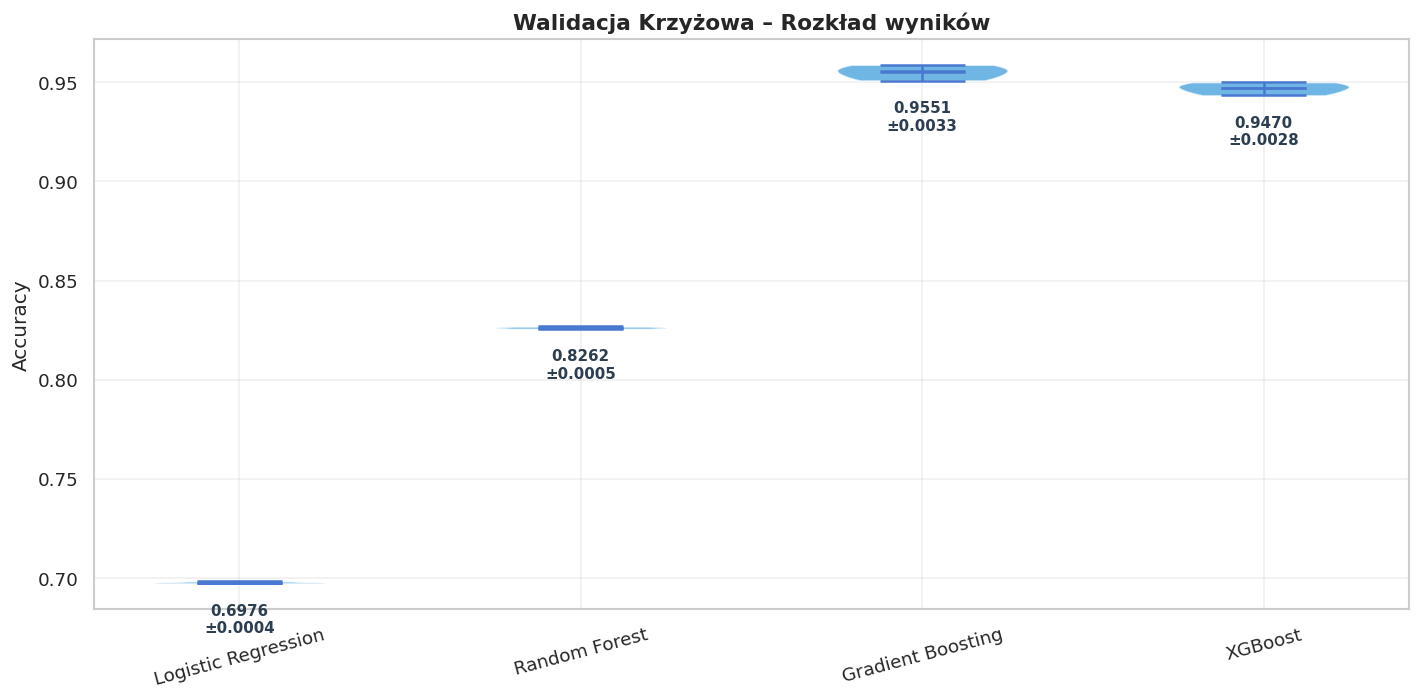

Wykres zapisany: plots/10_cross_validation.png


In [24]:
# =============================================
# KROK 22: Walidacja Krzyżowa modeli bazowych
# =============================================

print('Walidacja krzyżowa')
cv_results = {}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


cv_models = {k: v['model'] for k, v in baseline_results.items()
             if k in ['Random Forest', 'XGBoost', 'Gradient Boosting', 'Logistic Regression']}

for name, model in cv_models.items():
    print(f'  {name}...', end=' ')
    scores = cross_val_score(model, X_train_full, y_train_full, 
                            cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'CV Mean={scores.mean():.4f} ± {scores.std():.4f}')


fig, ax = plt.subplots(figsize=(12, 6))
positions = range(len(cv_results))
parts = ax.violinplot([cv_results[n] for n in cv_results], positions=positions,
                     showmeans=True, showmedians=True)

for pc in parts['bodies']:
    pc.set_facecolor('#3498db')
    pc.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(list(cv_results.keys()), rotation=15)
ax.set_ylabel('Accuracy')
ax.set_title('Walidacja Krzyżowa – Rozkład wyników', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

for i, (name, scores) in enumerate(cv_results.items()):
    ax.text(i, scores.min() - 0.01, f'{scores.mean():.4f}\n±{scores.std():.4f}',
           ha='center', va='top', fontsize=9, color='#2c3e50', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/10_cross_validation.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/10_cross_validation.png')

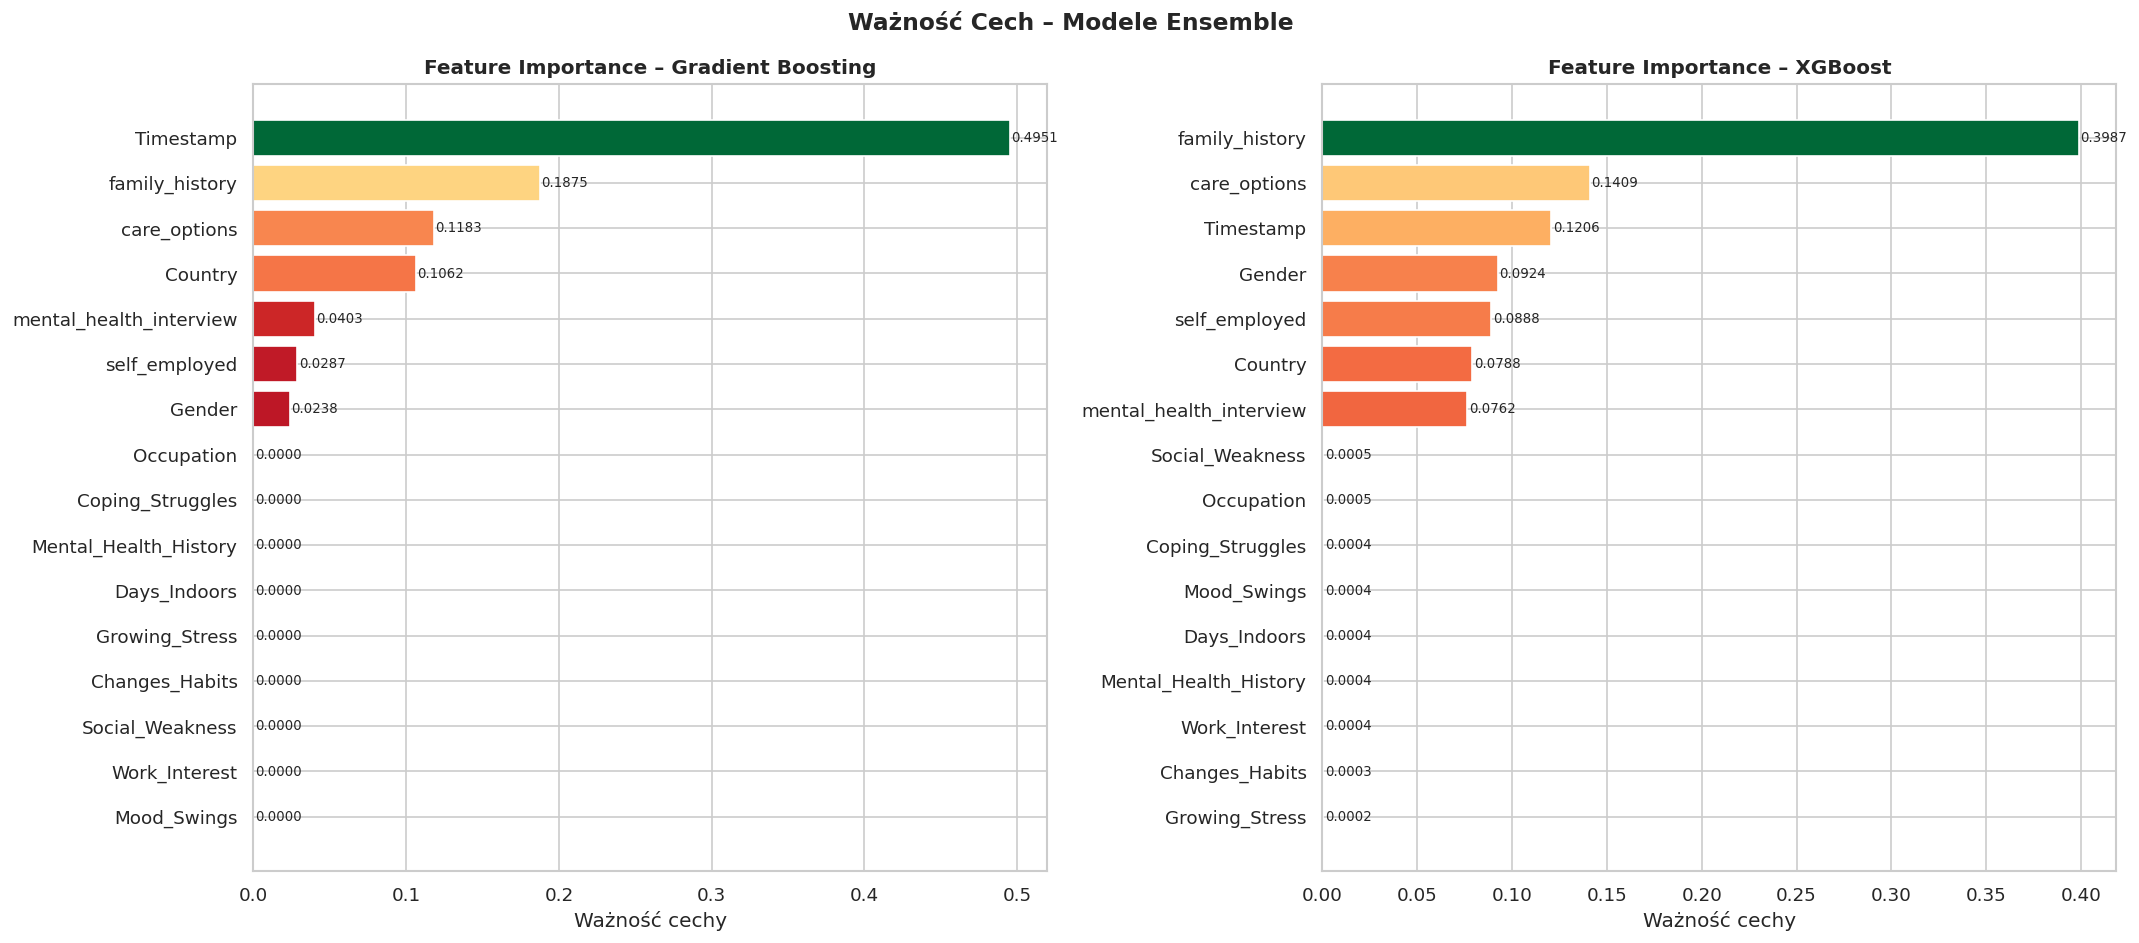

Wykres zapisany: plots/11_feature_importance.png


In [25]:
# =======================================================
# KROK 23: Feature Importance (Gradient Boosting + XGBoost)
# =======================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, model_name in zip(axes, ['Gradient Boosting', 'XGBoost']):
    if model_name in baseline_results:
        model = baseline_results[model_name]['model']
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:20]
        
        colors_fi = plt.cm.RdYlGn(importances[indices] / importances[indices].max())
        bars = ax.barh(
            [feature_names[i] if i < len(feature_names) else f'f{i}' for i in indices[::-1]],
            importances[indices[::-1]],
            color=colors_fi[::-1], edgecolor='white'
        )
        ax.set_title(f'Feature Importance – {model_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Ważność cechy')
        
        for bar, val in zip(bars, importances[indices[::-1]]):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                   f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Ważność Cech – Modele Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/11_feature_importance.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/11_feature_importance.png')

PermutationExplainer explainer: 301it [00:19,  9.33it/s]                                                                         


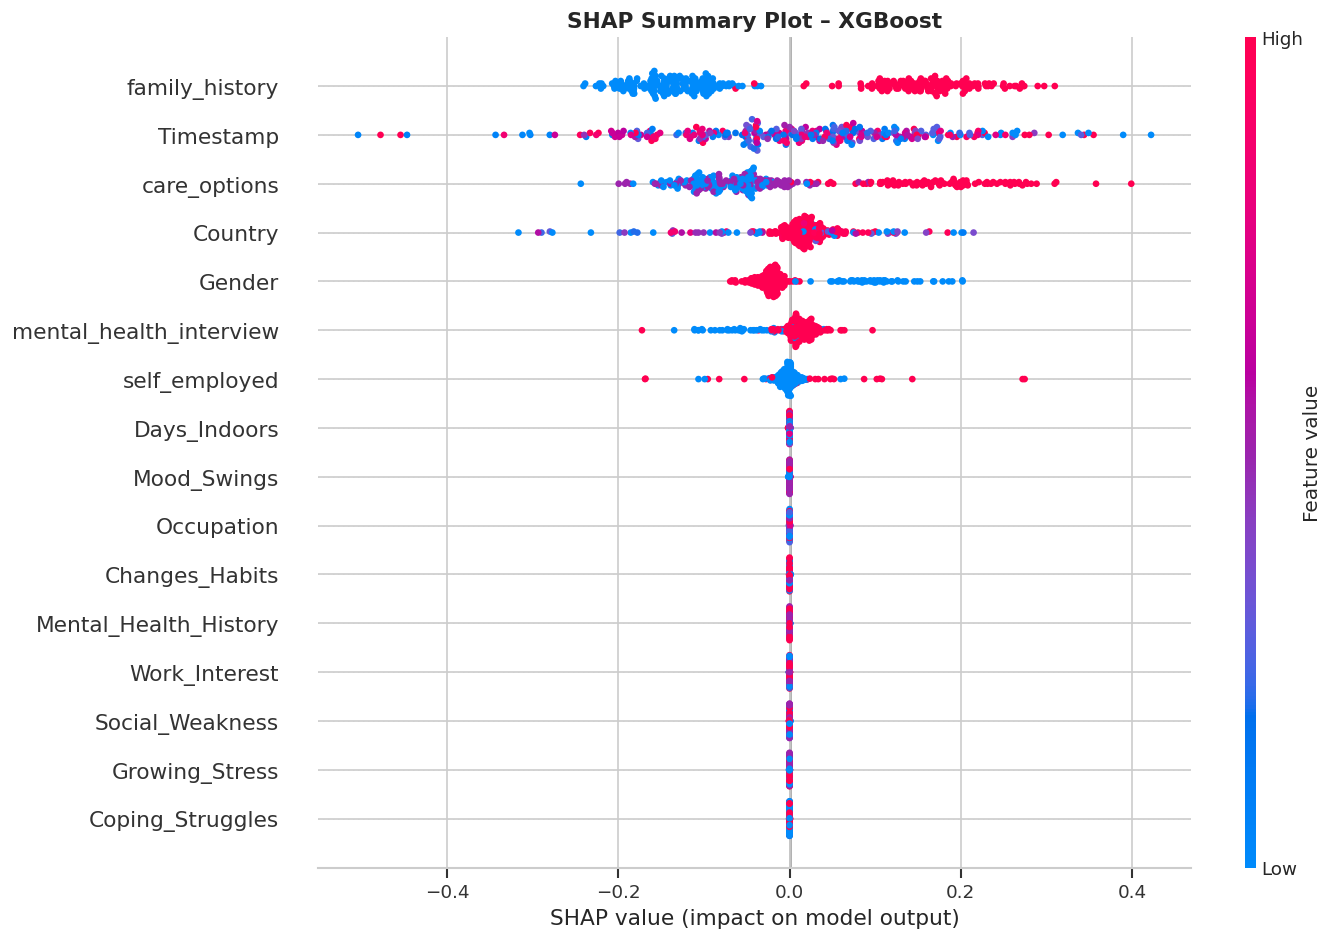

Wykres SHAP zapisany: plots/12_shap_summary.png


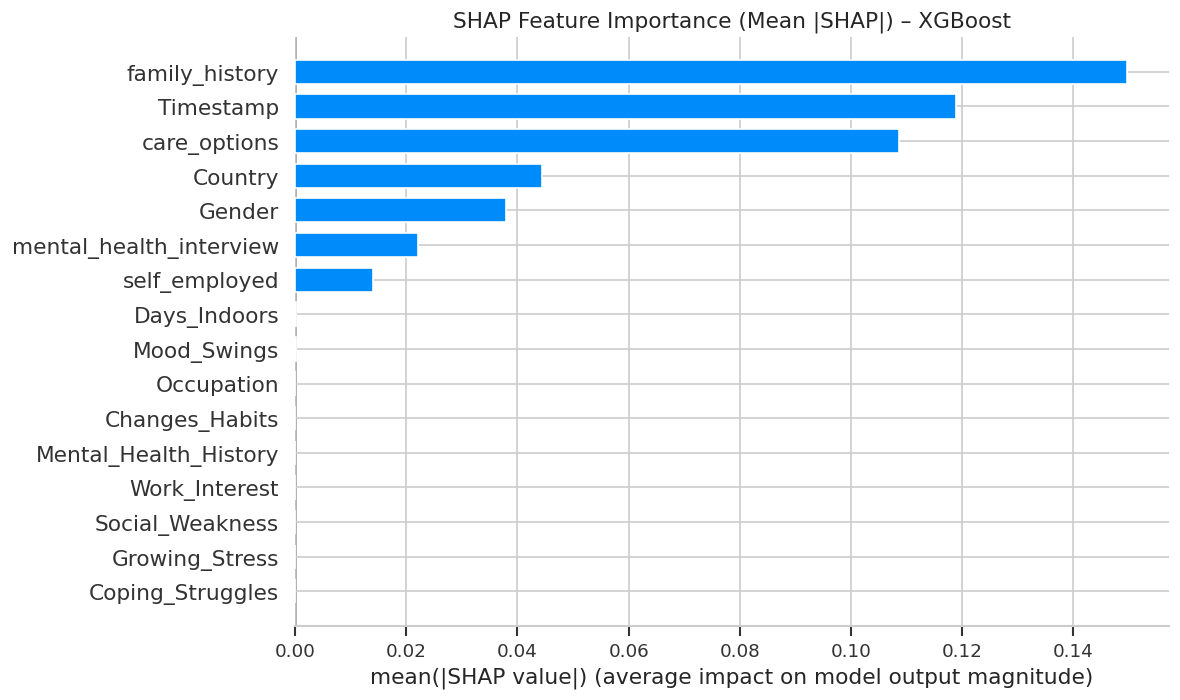

Wykres SHAP bar zapisany: plots/13_shap_bar.png


In [26]:
# ==========================================
# KROK 24: SHAP Explainability dla XGBoost 
# ==========================================

if 'XGBoost' in baseline_results:
    import numpy as np
    import pandas as pd
    import shap
    import matplotlib.pyplot as plt

    xgb_model = baseline_results['XGBoost']['model']

    sample_size = min(300, len(X_test))
    X_test_sample = X_test[:sample_size]
    X_test_df = pd.DataFrame(X_test_sample, columns=feature_names)

    bg_size = min(100, len(X_train))
    X_background = pd.DataFrame(X_train[:bg_size], columns=feature_names)

    predict_fn = lambda data: xgb_model.predict_proba(data)[:, 1]

    explainer = shap.Explainer(predict_fn, X_background)
    shap_exp = explainer(X_test_df)

    # wykres 1 
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_exp.values, X_test_df, show=False, plot_size=None)
    plt.title('SHAP Summary Plot – XGBoost', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/12_shap_summary.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres SHAP zapisany: {PLOTS_DIR}/12_shap_summary.png')

    # wykres 2
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_exp.values, X_test_df, plot_type='bar', show=False, plot_size=None)
    plt.title('SHAP Feature Importance (Mean |SHAP|) – XGBoost', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/13_shap_bar.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres SHAP bar zapisany: {PLOTS_DIR}/13_shap_bar.png')

else:
    print('XGBoost nie został wytrenowany')

In [27]:
# ===============================================
# KROK 25: Optymalizacja XGBoost – GridSearchCV
# ===============================================

# wersja wieksza
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

# wersja szybka
xgb_param_grid_fast = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_base = XGBClassifier(
    objective=xgb_obj, eval_metric=xgb_eval,
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
)

grid_search_xgb = GridSearchCV(
    xgb_base, xgb_param_grid_fast, cv=3, scoring='accuracy',
    n_jobs=-1, verbose=1, refit=True
)

grid_search_xgb.fit(X_train_bal, y_train_bal)

print(f'\nNajlepsze parametry XGBoost:')
for k, v in grid_search_xgb.best_params_.items():
    print(f'   {k}: {v}')
print(f'\nNajlepszy CV score: {grid_search_xgb.best_score_:.4f}')

# ewaluacja najlepszego
xgb_best = grid_search_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'Test Accuracy (tuned XGBoost): {acc_xgb:.4f}')

gs_results = pd.DataFrame(grid_search_xgb.cv_results_)
gs_results.to_csv(f'{RESULTS_DIR}/xgb_gridsearch_results.csv', index=False)
save_checkpoint(xgb_best, 'xgb_best_model')
print(f'Najlepszy XGBoost zapisany!')

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Najlepsze parametry XGBoost:
   colsample_bytree: 1.0
   learning_rate: 0.1
   max_depth: 7
   n_estimators: 200
   subsample: 0.8

Najlepszy CV score: 0.9939
Test Accuracy (tuned XGBoost): 0.9940
Checkpoint zapisany: checkpoints/xgb_best_model.pkl
Najlepszy XGBoost zapisany!


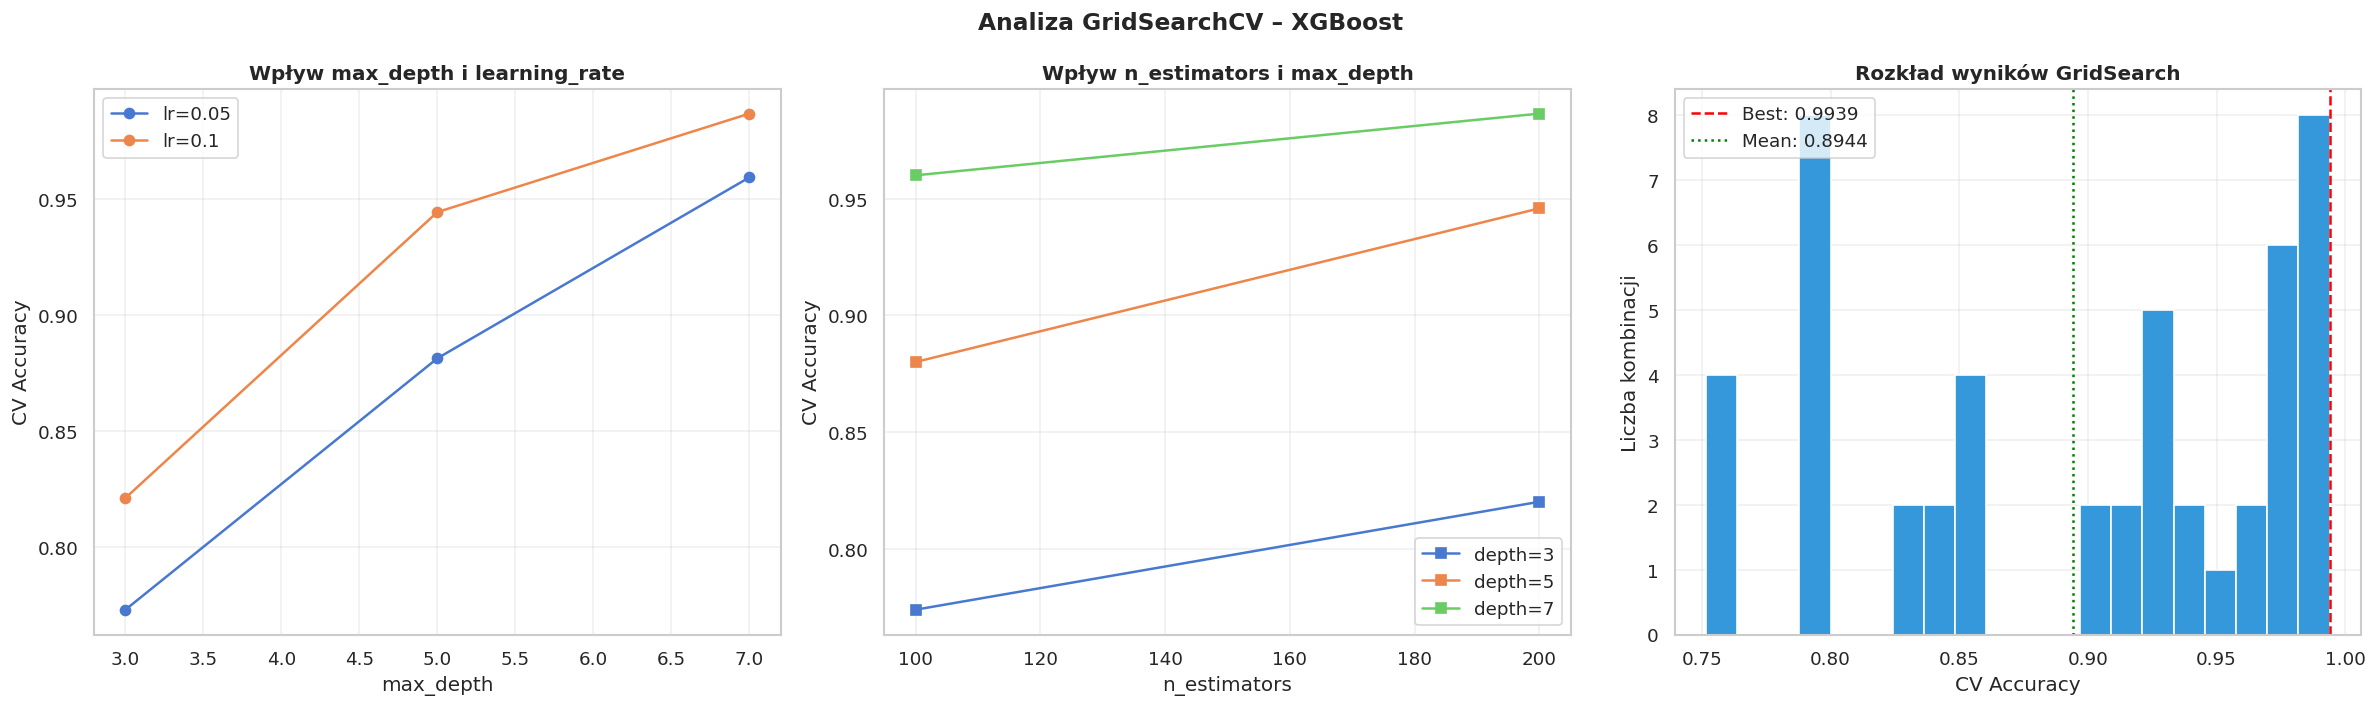

Wykres GridSearch zapisany: plots/14_xgb_gridsearch.png


In [28]:
# ==================================================
# KROK 26: Wizualizacja wyników GridSearch XGBoost
# ==================================================

gs_df = pd.DataFrame(grid_search_xgb.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Wpływ max_depth
for lr in gs_df['param_learning_rate'].unique():
    subset = gs_df[gs_df['param_learning_rate'] == lr]
    depth_means = subset.groupby('param_max_depth')['mean_test_score'].mean()
    axes[0].plot(depth_means.index, depth_means.values, marker='o', label=f'lr={lr}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('Wpływ max_depth i learning_rate', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Wpływ n_estimators
for depth in gs_df['param_max_depth'].unique():
    subset = gs_df[gs_df['param_max_depth'] == depth]
    est_means = subset.groupby('param_n_estimators')['mean_test_score'].mean()
    axes[1].plot(est_means.index, est_means.values, marker='s', label=f'depth={depth}')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('Wpływ n_estimators i max_depth', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Rozkład wszystkich CV scores
axes[2].hist(gs_df['mean_test_score'], bins=20, color='#3498db', edgecolor='white')
axes[2].axvline(gs_df['mean_test_score'].max(), color='red', linestyle='--', 
               label=f'Best: {gs_df["mean_test_score"].max():.4f}')
axes[2].axvline(gs_df['mean_test_score'].mean(), color='green', linestyle=':', 
               label=f'Mean: {gs_df["mean_test_score"].mean():.4f}')
axes[2].set_xlabel('CV Accuracy')
axes[2].set_ylabel('Liczba kombinacji')
axes[2].set_title('Rozkład wyników GridSearch', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Analiza GridSearchCV – XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/14_xgb_gridsearch.png', bbox_inches='tight')
plt.show()
print(f'Wykres GridSearch zapisany: {PLOTS_DIR}/14_xgb_gridsearch.png')

---
## CZESC 4b: Selekcja Cech przed Sieciami Neuronowymi

Po analizie waznosci cech (Random Forest + XGBoost) usuwamy cechy o niskiej waznosci,
aby przyspieszyc trening sieci neuronowych.



Wszystkie cechy (16):
                feature  RF_importance  XGB_importance  avg_importance
         family_history       1.000000        1.000000        1.000000
              Timestamp       0.937702        0.302515        0.620109
           care_options       0.684442        0.353433        0.518938
                Country       0.410456        0.197633        0.304044
                 Gender       0.177871        0.231733        0.204802
mental_health_interview       0.174009        0.191109        0.182559
          self_employed       0.129442        0.222699        0.176070
             Occupation       0.002149        0.001145        0.001647
           Days_Indoors       0.002107        0.000983        0.001545
        Social_Weakness       0.001461        0.001269        0.001365
            Mood_Swings       0.001415        0.001070        0.001242
          Work_Interest       0.001392        0.000931        0.001162
  Mental_Health_History       0.001311        0.000948 

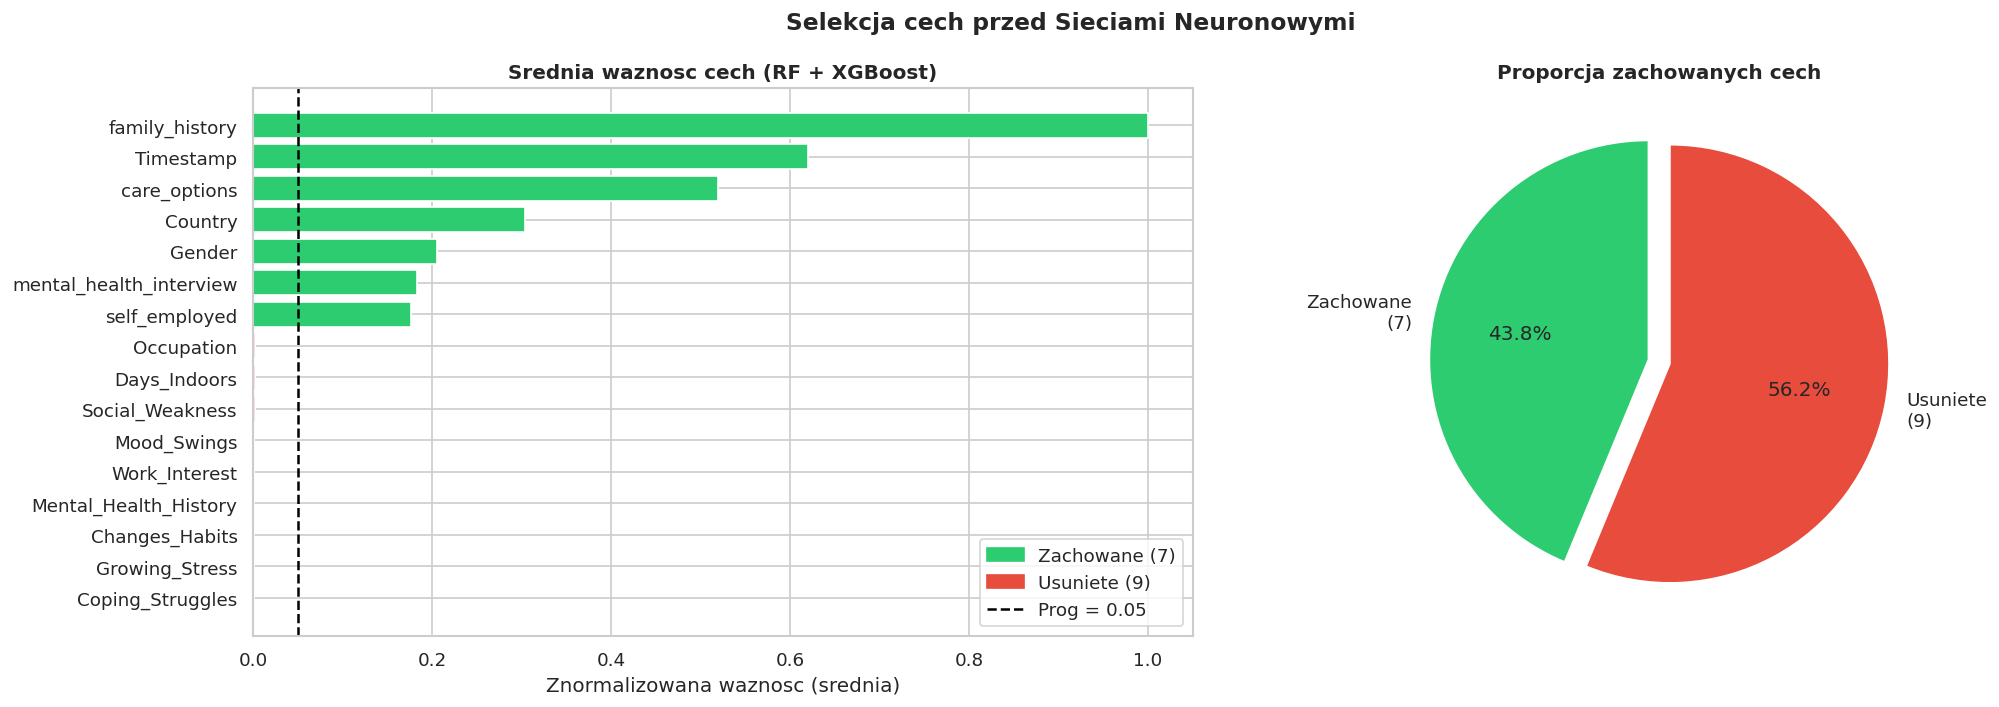

Wykres zapisany: plots/14b_feature_selection.png

Wymiary danych po selekcji:
  X_train: (203151, 16) -> (203151, 7)
  X_val:   (43392, 16)   -> (43392, 7)
  X_test:  (43508, 16)  -> (43508, 7)
Checkpoint zapisany: checkpoints/feature_selection.pkl
Subsampling aktywny: 203151 -> 30472 probek train (frac=0.15)
Rozmiar train (eksperymenty NN): (30472, 7)
Rozmiar val:                     (43392, 7)
Rozmiar test:                    (43508, 7)

Selekcja cech zakonczona. Sieci neuronowe beda trenowane na 7 cechach.


In [29]:
# =========================================================
# KROK 26b: Selekcja cech na podstawie Feature Importance
# =========================================================

# Zbierz importance z Random Forest i XGBoost (srednia)
rf_imp  = baseline_results['Random Forest']['model'].feature_importances_
xgb_imp = baseline_results['XGBoost']['model'].feature_importances_

# Normalizacja i srednia
rf_imp_norm  = rf_imp  / rf_imp.max()
xgb_imp_norm = xgb_imp / xgb_imp.max()
avg_imp = (rf_imp_norm + xgb_imp_norm) / 2

imp_df = pd.DataFrame({
    'feature':        feature_names,
    'RF_importance':  rf_imp_norm,
    'XGB_importance': xgb_imp_norm,
    'avg_importance': avg_imp
}).sort_values('avg_importance', ascending=False)

print(f'Wszystkie cechy ({len(feature_names)}):')
print(imp_df.to_string(index=False))

IMPORTANCE_THRESHOLD = 0.05  
selected_features_mask = avg_imp >= IMPORTANCE_THRESHOLD
selected_feature_names = [feature_names[i] for i, keep in enumerate(selected_features_mask) if keep]
dropped_feature_names  = [feature_names[i] for i, keep in enumerate(selected_features_mask) if not keep]

print(f'\nProg waznosci: {IMPORTANCE_THRESHOLD}')
print(f'Zachowane cechy ({len(selected_feature_names)}): {selected_feature_names}')
print(f'Usuniete cechy  ({len(dropped_feature_names)}):  {dropped_feature_names}')

# wykresy
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_sel = ['#2ecc71' if keep else '#e74c3c' for keep in selected_features_mask]
sorted_idx = np.argsort(avg_imp)
axes[0].barh(
    [feature_names[i] for i in sorted_idx],
    avg_imp[sorted_idx],
    color=[colors_sel[i] for i in sorted_idx],
    edgecolor='white'
)
axes[0].axvline(IMPORTANCE_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
               label=f'Prog = {IMPORTANCE_THRESHOLD}')
axes[0].set_title('Srednia waznosc cech (RF + XGBoost)', fontweight='bold')
axes[0].set_xlabel('Znormalizowana waznosc (srednia)')

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#2ecc71', label=f'Zachowane ({len(selected_feature_names)})'),
    Patch(color='#e74c3c', label=f'Usuniete ({len(dropped_feature_names)})'),
    plt.Line2D([0],[0], color='black', linestyle='--',
               label=f'Prog = {IMPORTANCE_THRESHOLD}')
])

# Wykres 2
axes[1].pie(
    [len(selected_feature_names), len(dropped_feature_names)],
    labels=[f'Zachowane\n({len(selected_feature_names)})',
            f'Usuniete\n({len(dropped_feature_names)})'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%', startangle=90, explode=[0.05, 0.05]
)
axes[1].set_title('Proporcja zachowanych cech', fontweight='bold')

plt.suptitle('Selekcja cech przed Sieciami Neuronowymi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/14b_feature_selection.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/14b_feature_selection.png')

# troche mniej dancyh do trenowania i porywanywania sieci 
X_train_nn     = X_train[:, selected_features_mask]
X_val_nn       = X_val[:,   selected_features_mask]
X_test_nn      = X_test[:,  selected_features_mask]
X_train_bal_nn = X_train_bal[:, selected_features_mask]
y_train_bal_nn = y_train_bal
y_val_nn       = y_val
N_FEATURES_NN  = X_train_nn.shape[1]

print(f'\nWymiary danych po selekcji:')
print(f'  X_train: {X_train.shape} -> {X_train_nn.shape}')
print(f'  X_val:   {X_val.shape}   -> {X_val_nn.shape}')
print(f'  X_test:  {X_test.shape}  -> {X_test_nn.shape}')

save_checkpoint({'selected_mask': selected_features_mask,
                 'selected_names': selected_feature_names}, 'feature_selection')


NN_SAMPLE_FRAC = 0.15

if NN_SAMPLE_FRAC < 1.0:
    from sklearn.utils import resample
    n_sample = int(len(X_train_bal_nn) * NN_SAMPLE_FRAC)
    X_train_bal_nn_exp, y_train_bal_nn_exp = resample(
        X_train_bal_nn, y_train_bal_nn,
        n_samples=n_sample, random_state=RANDOM_STATE, stratify=y_train_bal_nn
    )
    print(f'Subsampling aktywny: {len(X_train_bal_nn)} -> {len(X_train_bal_nn_exp)} probek train (frac={NN_SAMPLE_FRAC})')
else:
    X_train_bal_nn_exp = X_train_bal_nn
    y_train_bal_nn_exp = y_train_bal_nn
    print('Subsampling wylaczony – uzywam pelnego zbioru.')

# val i test pozostaja pelne
print(f'Rozmiar train (eksperymenty NN): {X_train_bal_nn_exp.shape}')
print(f'Rozmiar val:                     {X_val_nn.shape}')
print(f'Rozmiar test:                    {X_test_nn.shape}')

print(f'\nSelekcja cech zakonczona. Sieci neuronowe beda trenowane na {N_FEATURES_NN} cechach.')


---
##  CZĘŚĆ 5: Sieci Neuronowe – Optymalizacja Krok po Kroku


In [30]:
# ========================================================
# KROK 27: Funkcja budowania i treningu sieci neuronowej
# ========================================================
# na mnijeszych dnaych zeby bylo szybciej testować

def build_and_train_nn(
    neurons=64, layers=2, activation='relu',
    dropout_rate=0.3, optimizer_name='adam',
    learning_rate=0.001, batch_size=256,
    regularization=None, batch_norm=False,
    epochs=30, verbose=0
):
    """
    Zbuduj i wytrenuj sieć neuronową z podanymi hiperparametrami.
    Zwraca: (model, history, train_acc, val_acc, test_acc)
    """
    tf.keras.backend.clear_session()
    
    n_out = 1 if IS_BINARY else n_classes
    loss_fn = 'binary_crossentropy' if IS_BINARY else 'sparse_categorical_crossentropy'
    last_activation = 'sigmoid' if IS_BINARY else 'softmax'
    
    model = Sequential()
    model.add(Dense(neurons, activation=activation,
                   input_shape=(X_train_nn.shape[1],),
                   kernel_regularizer=regularization))
    if batch_norm:
        model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation,
                       kernel_regularizer=regularization))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(n_out, activation=last_activation))
    
    optimizers = {
        'adam': Adam(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
        'sgd': SGD(learning_rate=learning_rate, momentum=0.9)
    }
    opt = optimizers.get(optimizer_name, Adam(learning_rate=learning_rate))
    
    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])
    
    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=0)
    ]
    
    history = model.fit(
        X_train_bal_nn_exp, y_train_bal_nn_exp,
        validation_data=(X_val_nn, y_val_nn),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=verbose
    )
    
    _, train_acc = model.evaluate(X_train_bal_nn_exp, y_train_bal_nn_exp, verbose=0)
    _, val_acc = model.evaluate(X_val_nn, y_val_nn, verbose=0)
    _, test_acc = model.evaluate(X_test_nn, y_test, verbose=0)
    
    return model, history, train_acc, val_acc, test_acc


def plot_training_history(history, title='Historia treningu'):
    """Wizualizuj historię treningu."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} – Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val', linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} – Loss', fontweight='bold')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


print('Funkcje do sieci neuronowych gotowe!')

# Hiperparametry startowe
best_nn_params = {
    'neurons': 64,
    'layers': 2,
    'activation': 'relu',
    'dropout_rate': 0.3,
    'optimizer_name': 'adam',
    'learning_rate': 0.001,
    'batch_size': 256,
    'regularization': None,
    'batch_norm': False,
    'epochs': 30
}

nn_optimization_log = []  # log wszystkich eksperymentów
print(f'Startowe hiperparametry: {best_nn_params}')

Funkcje do sieci neuronowych gotowe!
Startowe hiperparametry: {'neurons': 64, 'layers': 2, 'activation': 'relu', 'dropout_rate': 0.3, 'optimizer_name': 'adam', 'learning_rate': 0.001, 'batch_size': 256, 'regularization': None, 'batch_norm': False, 'epochs': 30}


Trening bazowej sieci neuronowej...

Bazowa sieć neuronowa:
  Train Acc: 0.7916
  Val Acc:   0.7854
  Test Acc:  0.7857


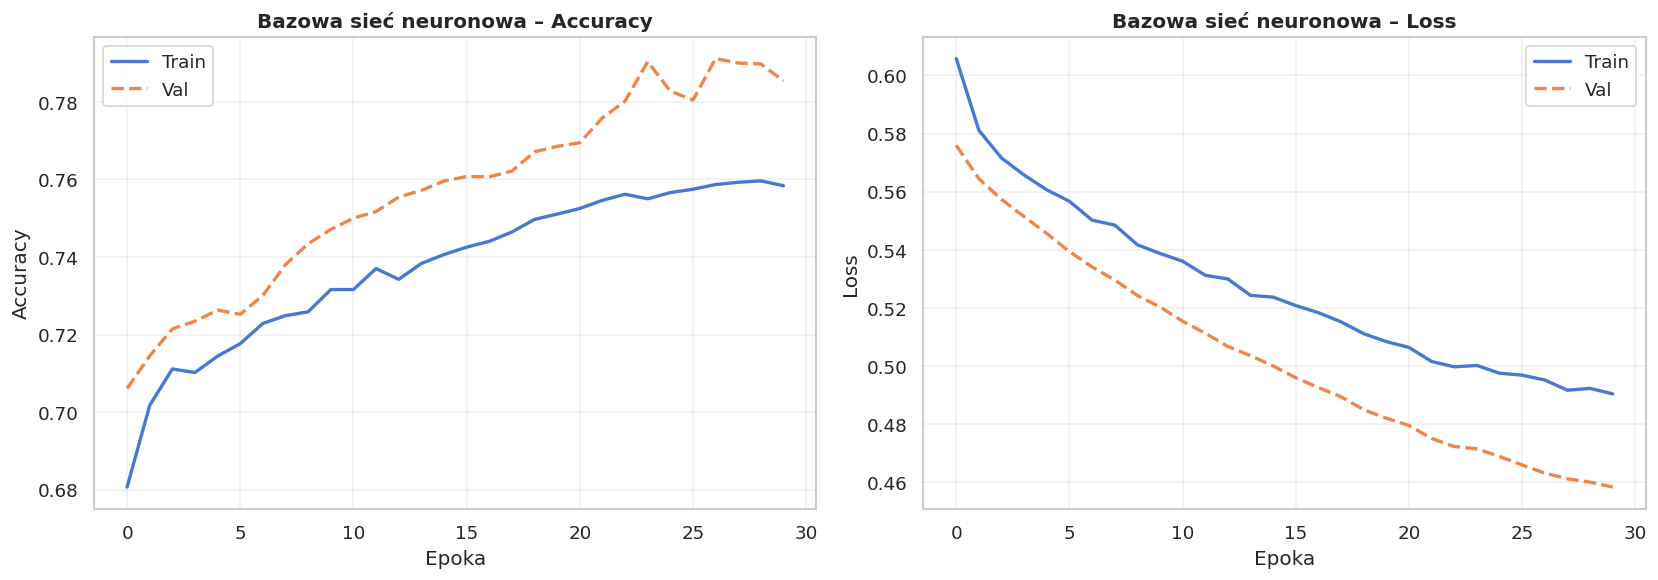

Wykres zapisany: plots/15_nn_baseline_history.png
Model Keras zapisany: checkpoints/nn_baseline_acc0.7857.keras


'checkpoints/nn_baseline_acc0.7857.keras'

In [31]:
# =======================================
# KROK 28: Sieć bazowa (punkt startowy)
# =======================================

print('Trening bazowej sieci neuronowej...')

model_base, hist_base, tr_acc, val_acc, te_acc = build_and_train_nn(**best_nn_params)

print(f'\nBazowa sieć neuronowa:')
print(f'  Train Acc: {tr_acc:.4f}')
print(f'  Val Acc:   {val_acc:.4f}')
print(f'  Test Acc:  {te_acc:.4f}')

nn_optimization_log.append({
    'experiment': 'Baseline NN',
    **best_nn_params,
    'train_acc': tr_acc, 'val_acc': val_acc, 'test_acc': te_acc
})

fig = plot_training_history(hist_base, 'Bazowa sieć neuronowa')
plt.savefig(f'{PLOTS_DIR}/15_nn_baseline_history.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/15_nn_baseline_history.png')

save_keras_checkpoint(model_base, 'nn_baseline', te_acc)

Eksperyment 1: Optymalizacja liczby neuronów
  neurons=  16: train=0.7263 | val=0.7235 | test=0.7235
  neurons=  32: train=0.7594 | val=0.7522 | test=0.7519
  neurons=  64: train=0.7906 | val=0.7850 | test=0.7867
  neurons= 128: train=0.8105 | val=0.8052 | test=0.8053
  neurons= 256: train=0.8265 | val=0.8222 | test=0.8206

Najlepsza liczba neuronów: 256 (val=0.8222)


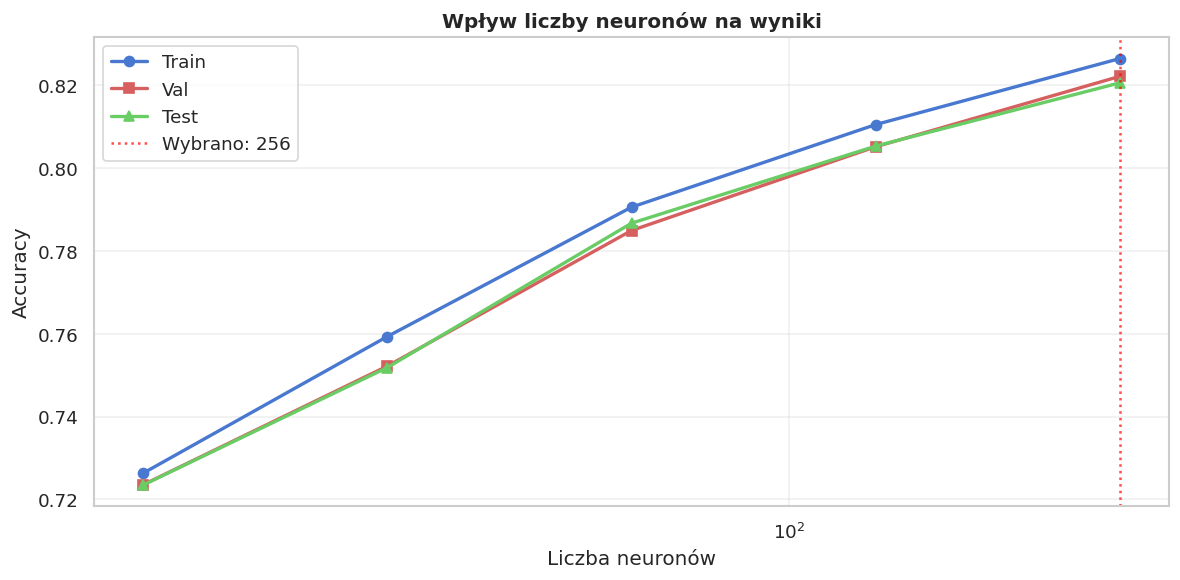

In [32]:
# ==========================================
# KROK 29: Optymalizacja – Liczba neuronów
# ==========================================

print('Eksperyment 1: Optymalizacja liczby neuronów')

neurons_candidates = [16, 32, 64, 128, 256]
neurons_results = []

for n in neurons_candidates:
    params = best_nn_params.copy()
    params['neurons'] = n
    _, _, tr, vl, te = build_and_train_nn(**params)
    neurons_results.append({'neurons': n, 'train_acc': tr, 'val_acc': vl, 'test_acc': te})
    print(f'  neurons={n:4d}: train={tr:.4f} | val={vl:.4f} | test={te:.4f}')

# najlepsza
best_neurons_entry = max(neurons_results, key=lambda x: x['val_acc'])
best_nn_params['neurons'] = best_neurons_entry['neurons']
print(f'\nNajlepsza liczba neuronów: {best_nn_params["neurons"]} (val={best_neurons_entry["val_acc"]:.4f})')

# wykresy
fig, ax = plt.subplots(figsize=(10, 5))
x = [r['neurons'] for r in neurons_results]
ax.plot(x, [r['train_acc'] for r in neurons_results], 'b-o', label='Train', linewidth=2)
ax.plot(x, [r['val_acc'] for r in neurons_results], 'r-s', label='Val', linewidth=2)
ax.plot(x, [r['test_acc'] for r in neurons_results], 'g-^', label='Test', linewidth=2)
ax.axvline(best_nn_params['neurons'], color='red', linestyle=':', alpha=0.7,
           label=f'Wybrano: {best_nn_params["neurons"]}')
ax.set_xlabel('Liczba neuronów')
ax.set_ylabel('Accuracy')
ax.set_title('Wpływ liczby neuronów na wyniki', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/16_neurons_optimization.png', bbox_inches='tight')
plt.show()

Eksperyment 2: Optymalizacja liczby warstw
  layers=1: train=0.7640 | val=0.7555 | test=0.7576
  layers=2: train=0.8354 | val=0.8308 | test=0.8306
  layers=3: train=0.8398 | val=0.8342 | test=0.8330
  layers=4: train=0.8366 | val=0.8317 | test=0.8310
  layers=5: train=0.8273 | val=0.8207 | test=0.8211

Najlepsza liczba warstw: 3 (val=0.8342)


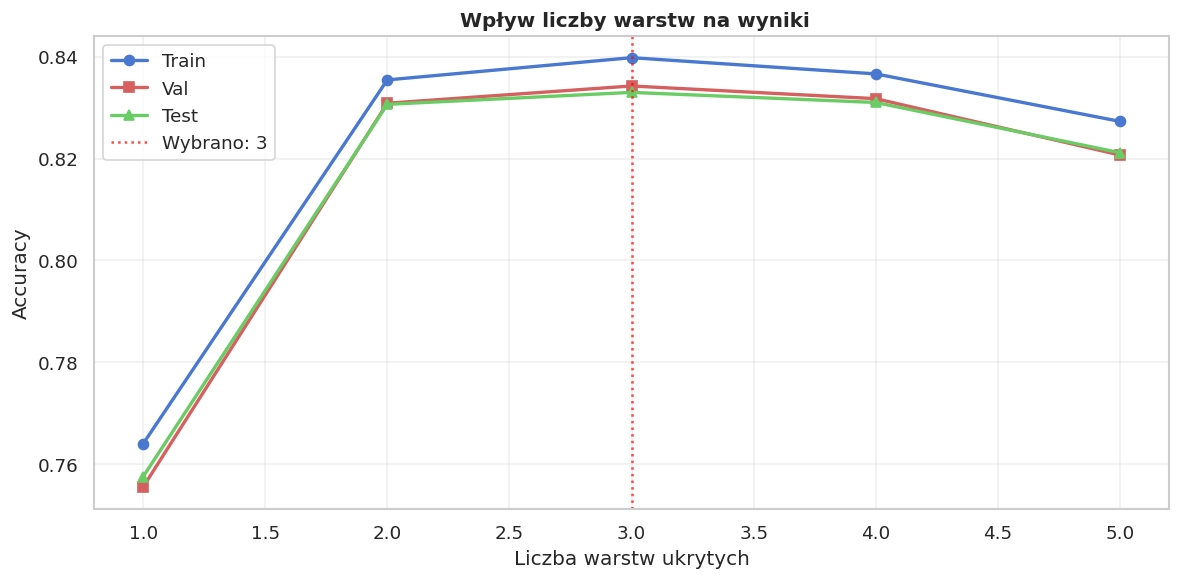

In [33]:
# ========================================
# KROK 30: Optymalizacja – Liczba warstw
# ========================================
print('Eksperyment 2: Optymalizacja liczby warstw')

layers_candidates = [1, 2, 3, 4, 5] 
layers_results = []

for l in layers_candidates:
    params = best_nn_params.copy()
    params['layers'] = l
    _, _, tr, vl, te = build_and_train_nn(**params)
    layers_results.append({'layers': l, 'train_acc': tr, 'val_acc': vl, 'test_acc': te})
    print(f'  layers={l}: train={tr:.4f} | val={vl:.4f} | test={te:.4f}')

best_layers_entry = max(layers_results, key=lambda x: x['val_acc'])
best_nn_params['layers'] = best_layers_entry['layers']
print(f'\nNajlepsza liczba warstw: {best_nn_params["layers"]} (val={best_layers_entry["val_acc"]:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
x = [r['layers'] for r in layers_results]
ax.plot(x, [r['train_acc'] for r in layers_results], 'b-o', label='Train', linewidth=2)
ax.plot(x, [r['val_acc'] for r in layers_results], 'r-s', label='Val', linewidth=2)
ax.plot(x, [r['test_acc'] for r in layers_results], 'g-^', label='Test', linewidth=2)
ax.axvline(best_nn_params['layers'], color='red', linestyle=':', alpha=0.7,
           label=f'Wybrano: {best_nn_params["layers"]}')
ax.set_xlabel('Liczba warstw ukrytych')
ax.set_ylabel('Accuracy')
ax.set_title(' Wpływ liczby warstw na wyniki', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/17_layers_optimization.png', bbox_inches='tight')
plt.show()

Eksperyment 3: Optymalizacja funkcji aktywacji
  relu           : train=0.8347 | val=0.8281 | test=0.8273
  tanh           : train=0.8313 | val=0.8254 | test=0.8255
  selu           : train=0.7528 | val=0.7444 | test=0.7475
  elu            : train=0.7895 | val=0.7826 | test=0.7855
  leaky_relu     : train=0.8043 | val=0.7999 | test=0.7981

Najlepsza aktywacja: relu (val=0.8281)


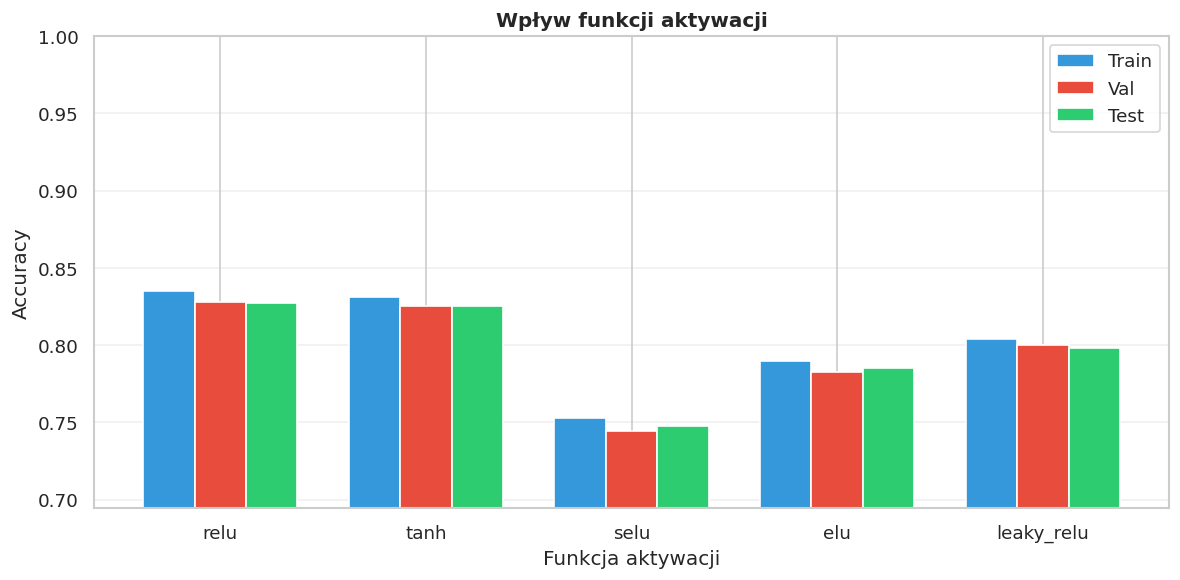

In [34]:
# ============================================
# KROK 31: Optymalizacja – Funkcja aktywacji
# ============================================

print('Eksperyment 3: Optymalizacja funkcji aktywacji')

activation_candidates = ['relu', 'tanh', 'selu', 'elu', 'leaky_relu']
activation_results = []

for act in activation_candidates:
    params = best_nn_params.copy()
    params['activation'] = act
    try:
        _, _, tr, vl, te = build_and_train_nn(**params)
        activation_results.append({'activation': act, 'train_acc': tr, 'val_acc': vl, 'test_acc': te})
        print(f'  {act:15s}: train={tr:.4f} | val={vl:.4f} | test={te:.4f}')
    except Exception as e:
        print(f'  {act}: błąd – {e}')

best_act_entry = max(activation_results, key=lambda x: x['val_acc'])
best_nn_params['activation'] = best_act_entry['activation']
print(f'\nNajlepsza aktywacja: {best_nn_params["activation"]} (val={best_act_entry["val_acc"]:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
x = [r['activation'] for r in activation_results]
x_pos = range(len(x))
width = 0.25
ax.bar([p - width for p in x_pos], [r['train_acc'] for r in activation_results], width, label='Train', color='#3498db')
ax.bar(x_pos, [r['val_acc'] for r in activation_results], width, label='Val', color='#e74c3c')
ax.bar([p + width for p in x_pos], [r['test_acc'] for r in activation_results], width, label='Test', color='#2ecc71')
ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.set_xlabel('Funkcja aktywacji')
ax.set_ylabel('Accuracy')
ax.set_title('Wpływ funkcji aktywacji', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(max(0, min([r['val_acc'] for r in activation_results]) - 0.05), 1.0)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/18_activation_optimization.png', bbox_inches='tight')
plt.show()

Eksperyment 4: Optymalizacja Dropout - regularyzacja
  dropout=0.0: train=0.8824 | val=0.8775 | test=0.8799 | overfit=0.0049
  dropout=0.1: train=0.8659 | val=0.8582 | test=0.8588 | overfit=0.0078
  dropout=0.2: train=0.8527 | val=0.8456 | test=0.8451 | overfit=0.0070
  dropout=0.3: train=0.8309 | val=0.8240 | test=0.8235 | overfit=0.0069
  dropout=0.4: train=0.8152 | val=0.8094 | test=0.8089 | overfit=0.0058
  dropout=0.5: train=0.8142 | val=0.8102 | test=0.8089 | overfit=0.0041

Najlepszy dropout: 0.0 (val=0.8775)


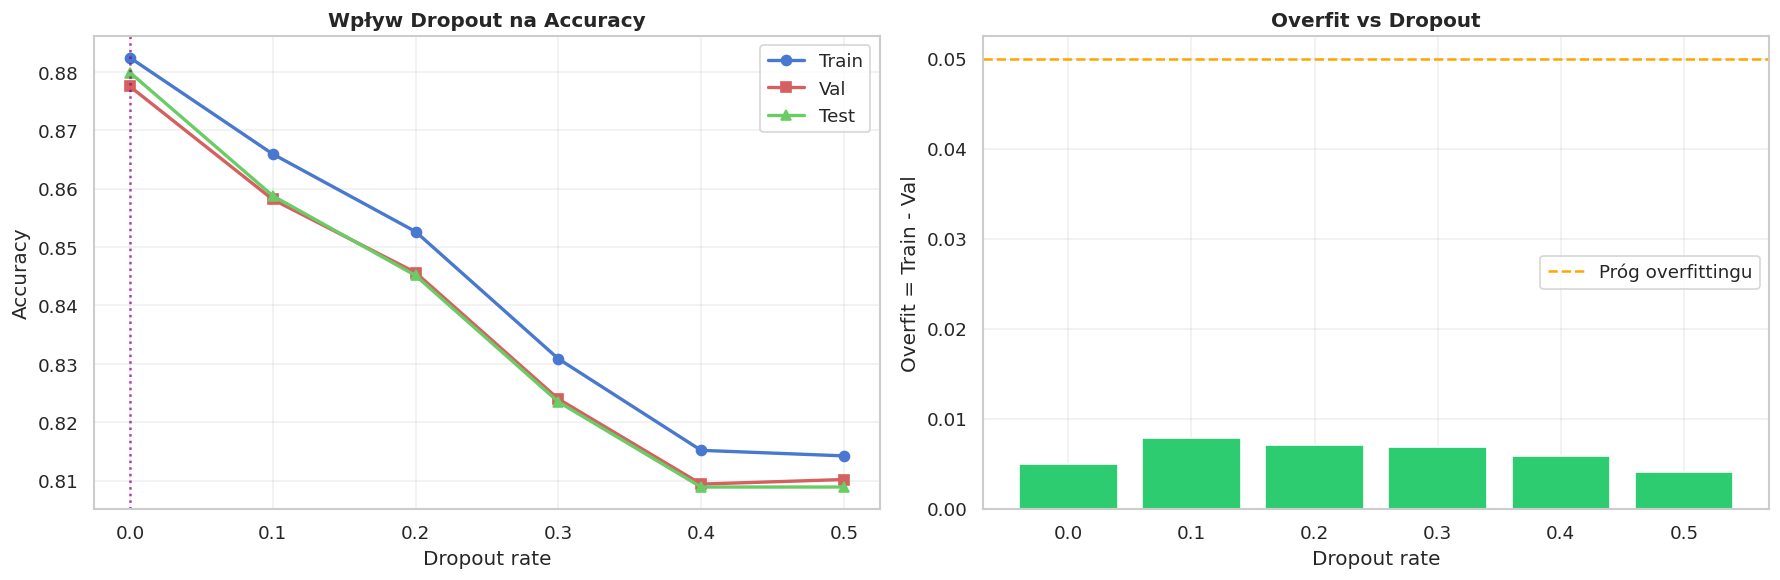

In [35]:
# ==================================
# KROK 32: Optymalizacja – Dropout
# ==================================

print('Eksperyment 4: Optymalizacja Dropout - regularyzacja')

dropout_candidates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
dropout_results = []

for dr in dropout_candidates:
    params = best_nn_params.copy()
    params['dropout_rate'] = dr
    _, _, tr, vl, te = build_and_train_nn(**params)
    dropout_results.append({'dropout_rate': dr, 'train_acc': tr, 'val_acc': vl, 'test_acc': te,
                           'overfit': tr - vl})
    print(f'  dropout={dr:.1f}: train={tr:.4f} | val={vl:.4f} | test={te:.4f} | overfit={tr-vl:.4f}')

best_dr_entry = max(dropout_results, key=lambda x: x['val_acc'])
best_nn_params['dropout_rate'] = best_dr_entry['dropout_rate']
print(f'\nNajlepszy dropout: {best_nn_params["dropout_rate"]} (val={best_dr_entry["val_acc"]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = [r['dropout_rate'] for r in dropout_results]

axes[0].plot(x, [r['train_acc'] for r in dropout_results], 'b-o', label='Train', linewidth=2)
axes[0].plot(x, [r['val_acc'] for r in dropout_results], 'r-s', label='Val', linewidth=2)
axes[0].plot(x, [r['test_acc'] for r in dropout_results], 'g-^', label='Test', linewidth=2)
axes[0].axvline(best_nn_params['dropout_rate'], color='purple', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Dropout rate')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Wpływ Dropout na Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

overfit_vals = [r['overfit'] for r in dropout_results]
axes[1].bar(x, overfit_vals, width=0.08, 
           color=['#e74c3c' if v > 0.05 else '#2ecc71' for v in overfit_vals])
axes[1].axhline(0.05, color='orange', linestyle='--', label='Próg overfittingu')
axes[1].set_xlabel('Dropout rate')
axes[1].set_ylabel('Overfit = Train - Val')
axes[1].set_title('Overfit vs Dropout', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/19_dropout_optimization.png', bbox_inches='tight')
plt.show()

Eksperyment 5: Optymalizacja optymalizatora i learning rate
  adam       lr=0.0010: train=0.8778 | val=0.8711 | test=0.8725
  adam       lr=0.0100: train=0.8762 | val=0.8713 | test=0.8718
  adam       lr=0.0001: train=0.8376 | val=0.8316 | test=0.8306
  rmsprop    lr=0.0010: train=0.8262 | val=0.8277 | test=0.8250
  rmsprop    lr=0.0100: train=0.9263 | val=0.9178 | test=0.9212
  rmsprop    lr=0.0001: train=0.7897 | val=0.7864 | test=0.7864
  sgd        lr=0.0010: train=0.7279 | val=0.7227 | test=0.7242
  sgd        lr=0.0100: train=0.7996 | val=0.7977 | test=0.7971
  sgd        lr=0.0001: train=0.7057 | val=0.7030 | test=0.7046

Najlepszy optimizer: rmsprop (lr=0.01)


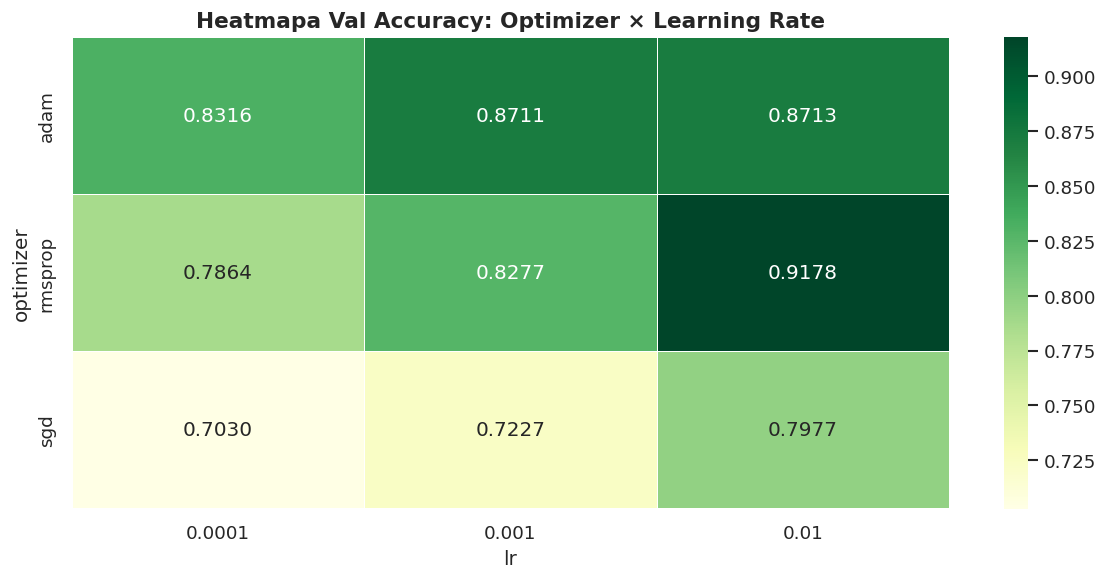

Wykres zapisany: plots/20_optimizer_lr_heatmap.png


In [36]:
# ====================================================
# KROK 33: Optymalizacja – Optimizer i Learning Rate
# ====================================================

print('Eksperyment 5: Optymalizacja optymalizatora i learning rate')

optimizer_lr_results = []

for opt in ['adam', 'rmsprop', 'sgd']:
    for lr in [0.001, 0.01, 0.0001]:
        params = best_nn_params.copy()
        params['optimizer_name'] = opt
        params['learning_rate'] = lr
        _, _, tr, vl, te = build_and_train_nn(**params)
        optimizer_lr_results.append({
            'optimizer': opt, 'lr': lr,
            'train_acc': tr, 'val_acc': vl, 'test_acc': te
        })
        print(f'  {opt:10s} lr={lr:.4f}: train={tr:.4f} | val={vl:.4f} | test={te:.4f}')

best_opt_entry = max(optimizer_lr_results, key=lambda x: x['val_acc'])
best_nn_params['optimizer_name'] = best_opt_entry['optimizer']
best_nn_params['learning_rate'] = best_opt_entry['lr']
print(f'\nNajlepszy optimizer: {best_nn_params["optimizer_name"]} (lr={best_nn_params["learning_rate"]})')

# Heatmapa optimizer × learning rate
opt_lr_df = pd.DataFrame(optimizer_lr_results)
heatmap_data = opt_lr_df.pivot(index='optimizer', columns='lr', values='val_acc')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGn', ax=ax, linewidths=0.5)
ax.set_title('Heatmapa Val Accuracy: Optimizer × Learning Rate', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/20_optimizer_lr_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/20_optimizer_lr_heatmap.png')

In [37]:
# ===========================================================
# KROK 34: Optymalizacja – Batch Size i Regularyzacja L1/L2
# ===========================================================

print('Eksperyment 6: Batch Size')

batch_results = []
for bs in [32, 64, 128, 256, 512]:
    params = best_nn_params.copy()
    params['batch_size'] = bs
    _, _, tr, vl, te = build_and_train_nn(**params)
    batch_results.append({'batch_size': bs, 'train_acc': tr, 'val_acc': vl, 'test_acc': te})
    print(f'  batch={bs:4d}: train={tr:.4f} | val={vl:.4f} | test={te:.4f}')

best_bs_entry = max(batch_results, key=lambda x: x['val_acc'])
best_nn_params['batch_size'] = best_bs_entry['batch_size']
print(f'\nNajlepszy batch size: {best_nn_params["batch_size"]}')

print('\nEksperyment 7: Regularyzacja L1/L2')
reg_candidates = [
    ('None', None),
    ('L1-0.0001', regularizers.l1(0.0001)),
    ('L1-0.001', regularizers.l1(0.001)),
    ('L2-0.0001', regularizers.l2(0.0001)),
    ('L2-0.001', regularizers.l2(0.001)),
    ('L1L2-0.0001', regularizers.l1_l2(l1=0.0001, l2=0.0001)),
]
reg_results = []
for reg_name, reg_obj in reg_candidates:
    params = best_nn_params.copy()
    params['regularization'] = reg_obj
    _, _, tr, vl, te = build_and_train_nn(**params)
    reg_results.append({'reg': reg_name, 'train_acc': tr, 'val_acc': vl, 'test_acc': te})
    print(f'  {reg_name:20s}: train={tr:.4f} | val={vl:.4f} | test={te:.4f}')

best_reg_entry = max(reg_results, key=lambda x: x['val_acc'])
best_reg_name = best_reg_entry['reg']

for reg_name, reg_obj in reg_candidates:
    if reg_name == best_reg_name:
        best_nn_params['regularization'] = reg_obj
        break

print(f'\nNajlepsza regularyzacja: {best_reg_name}')

Eksperyment 6: Batch Size
  batch=  32: train=0.9308 | val=0.9254 | test=0.9273
  batch=  64: train=0.9524 | val=0.9466 | test=0.9485
  batch= 128: train=0.9334 | val=0.9264 | test=0.9306
  batch= 256: train=0.9316 | val=0.9254 | test=0.9292
  batch= 512: train=0.8971 | val=0.8927 | test=0.8906

Najlepszy batch size: 64

Eksperyment 7: Regularyzacja L1/L2
  None                : train=0.9305 | val=0.9239 | test=0.9277
  L1-0.0001           : train=0.8491 | val=0.8477 | test=0.8462
  L1-0.001            : train=0.7605 | val=0.7548 | test=0.7557
  L2-0.0001           : train=0.9146 | val=0.9071 | test=0.9077
  L2-0.001            : train=0.8291 | val=0.8266 | test=0.8259
  L1L2-0.0001         : train=0.8705 | val=0.8688 | test=0.8658

Najlepsza regularyzacja: None


In [38]:
# ==============================================
# KROK 35: Optymalizacja – Batch Normalization
# ==============================================
print('Eksperyment 8: Batch Normalization')

bn_results = []
for use_bn in [False, True]:
    params = best_nn_params.copy()
    params['batch_norm'] = use_bn
    _, _, tr, vl, te = build_and_train_nn(**params)
    bn_results.append({'batch_norm': use_bn, 'train_acc': tr, 'val_acc': vl, 'test_acc': te})
    print(f'  BatchNorm={str(use_bn):5s}: train={tr:.4f} | val={vl:.4f} | test={te:.4f}')

best_bn_entry = max(bn_results, key=lambda x: x['val_acc'])
best_nn_params['batch_norm'] = best_bn_entry['batch_norm']
print(f'\nBatch Normalization: {best_nn_params["batch_norm"]}')

Eksperyment 8: Batch Normalization
  BatchNorm=False: train=0.9161 | val=0.9111 | test=0.9116
  BatchNorm=True : train=0.9196 | val=0.9136 | test=0.9142

Batch Normalization: True


In [39]:
# Podsumowanie wszystkich kroków optymalizacji
print('\n' + '-'*60)
print('PODSUMOWANIE OPTYMALIZACJI SIECI NEURONOWEJ')
print('-'*60)
for key, val in best_nn_params.items():
    if key != 'regularization':
        print(f'  {key:20s}: {val}')
print('-'*60)

save_checkpoint(best_nn_params, 'best_nn_params')


------------------------------------------------------------
PODSUMOWANIE OPTYMALIZACJI SIECI NEURONOWEJ
------------------------------------------------------------
  neurons             : 256
  layers              : 3
  activation          : relu
  dropout_rate        : 0.0
  optimizer_name      : rmsprop
  learning_rate       : 0.01
  batch_size          : 64
  batch_norm          : True
  epochs              : 30
------------------------------------------------------------
Checkpoint zapisany: checkpoints/best_nn_params.pkl


'checkpoints/best_nn_params.pkl'

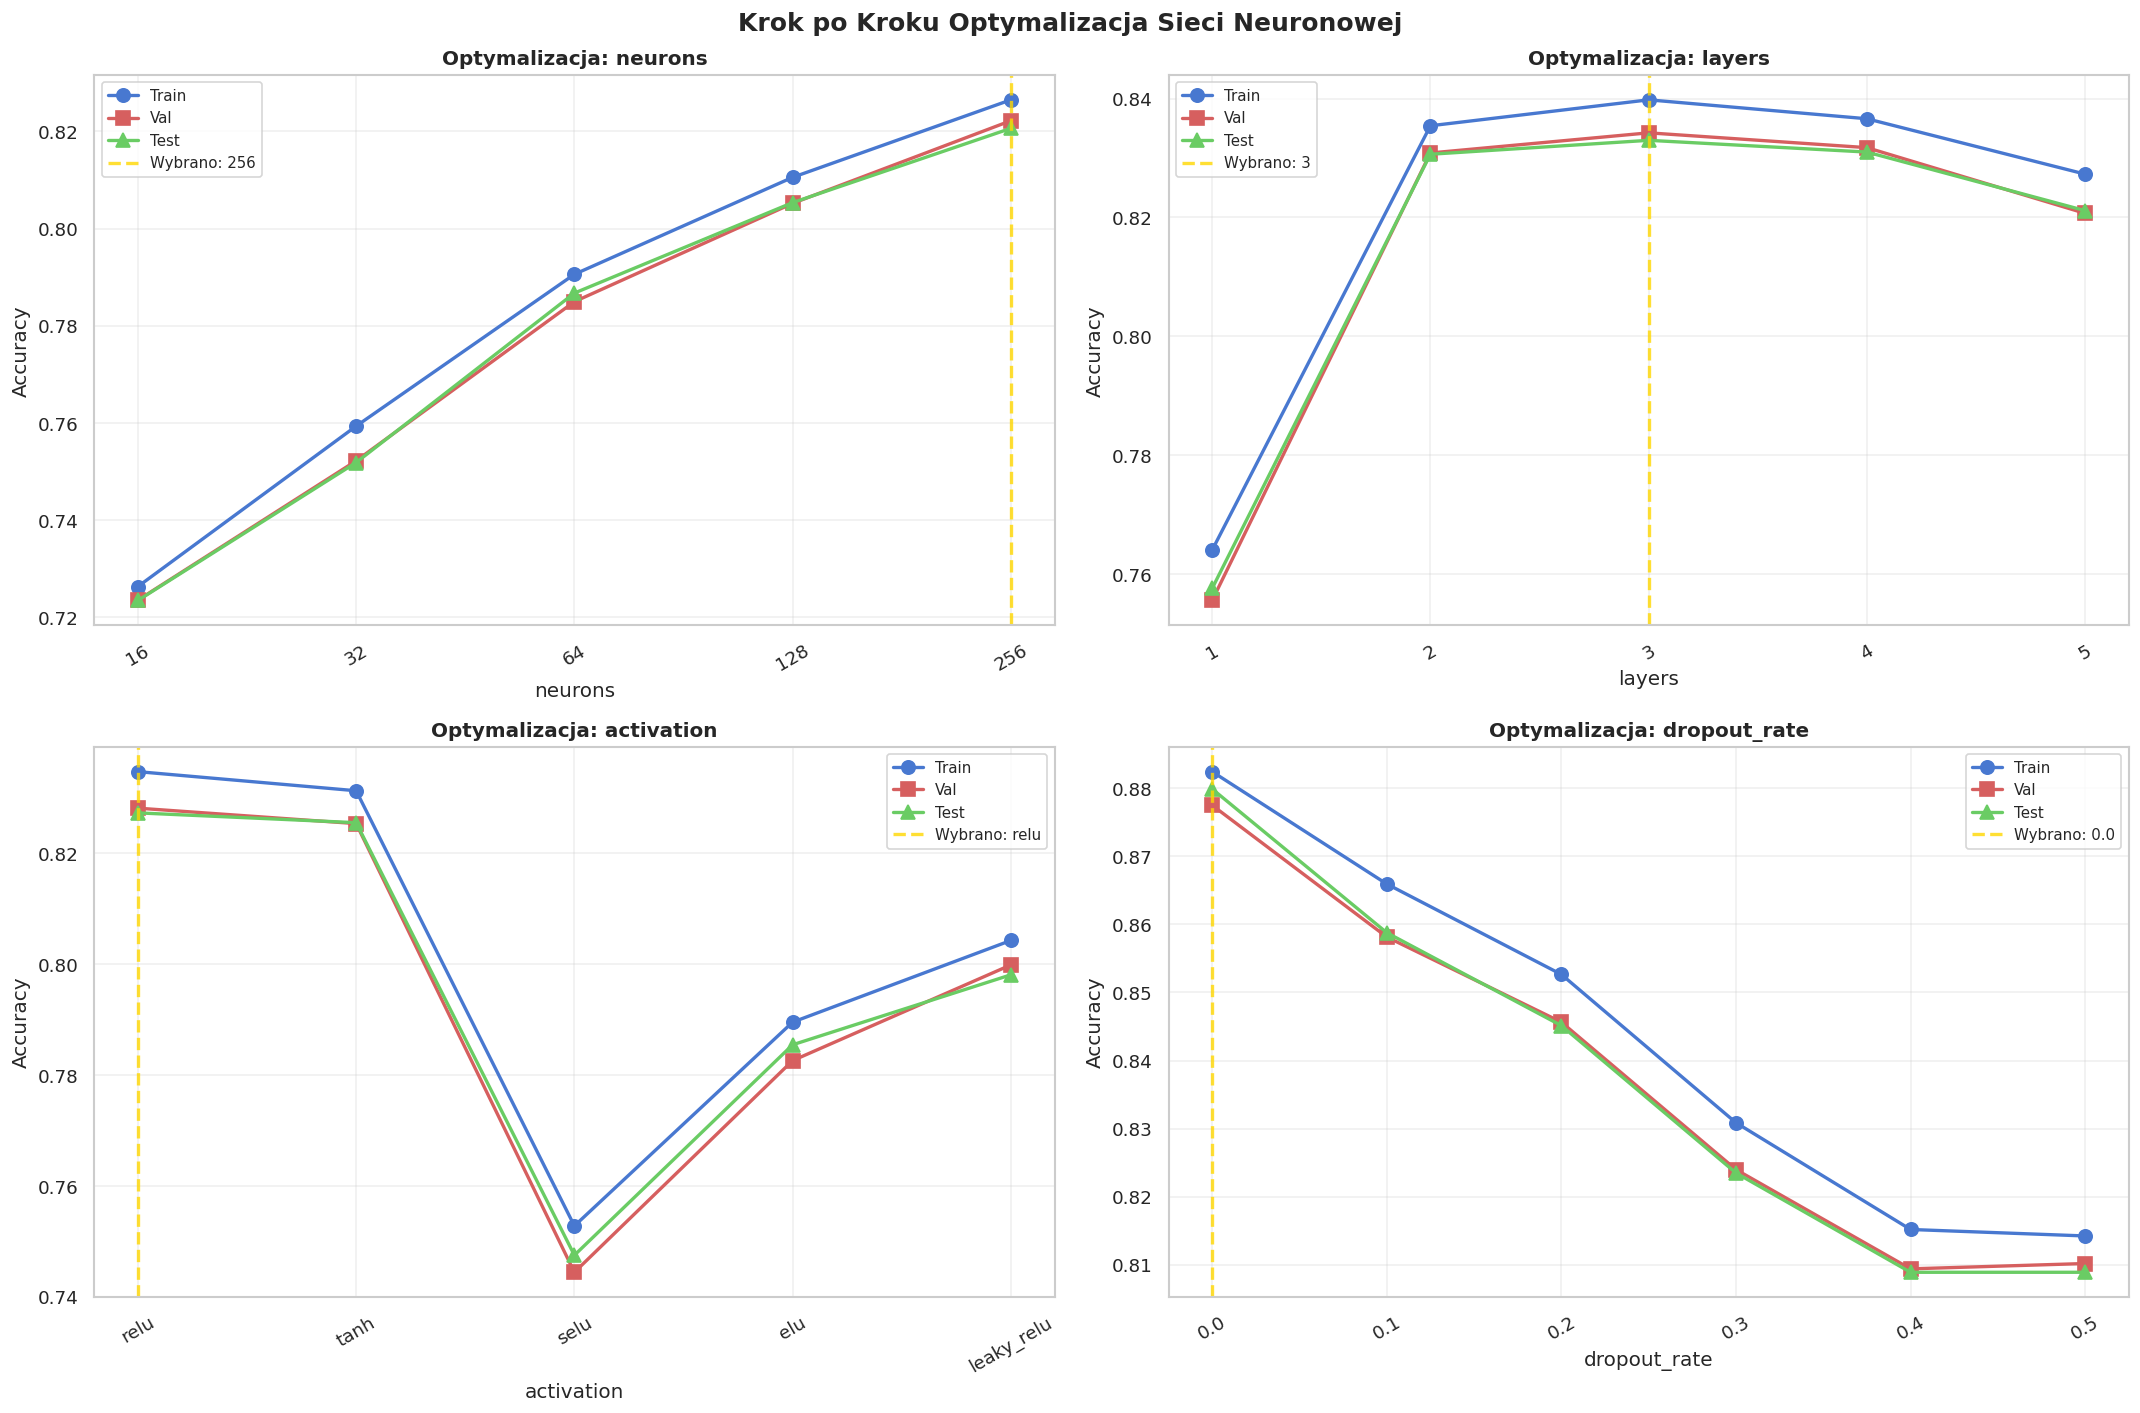

Wykres zapisany: plots/21_nn_optimization_summary.png


In [40]:
# =======================================================
# KROK 36: Wizualizacja całego procesu optymalizacji NN
# =======================================================

all_hp_experiments = [
    {'param': 'neurons', 'results': neurons_results, 'key': 'neurons'},
    {'param': 'layers', 'results': layers_results, 'key': 'layers'},
    {'param': 'activation', 'results': activation_results, 'key': 'activation'},
    {'param': 'dropout_rate', 'results': dropout_results, 'key': 'dropout_rate'},
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes_flat = axes.flatten()

for idx, exp in enumerate(all_hp_experiments):
    ax = axes_flat[idx]
    res = exp['results']
    key = exp['key']
    param_name = exp['param']
    
    x_labels = [str(r[key]) for r in res]
    x_pos = range(len(x_labels))
    
    ax.plot(x_pos, [r['train_acc'] for r in res], 'b-o', label='Train', linewidth=2, markersize=8)
    ax.plot(x_pos, [r['val_acc'] for r in res], 'r-s', label='Val', linewidth=2, markersize=8)
    ax.plot(x_pos, [r['test_acc'] for r in res], 'g-^', label='Test', linewidth=2, markersize=8)
    
    best_idx = max(range(len(res)), key=lambda i: res[i]['val_acc'])
    ax.axvline(best_idx, color='gold', linestyle='--', alpha=0.8, linewidth=2,
              label=f'Wybrano: {x_labels[best_idx]}')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=30)
    ax.set_xlabel(param_name)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Optymalizacja: {param_name}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Krok po Kroku Optymalizacja Sieci Neuronowej', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/21_nn_optimization_summary.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/21_nn_optimization_summary.png')

Trening finalnej zoptymalizowanej sieci neuronowej na calych danych
Finalny model wytrenowany na pelnych danych.

Finalna sieć neuronowa:
  Train Acc: 0.9720
  Val Acc:   0.9711
  Test Acc:  0.9712
  Poprawa vs bazowa: 0.1855


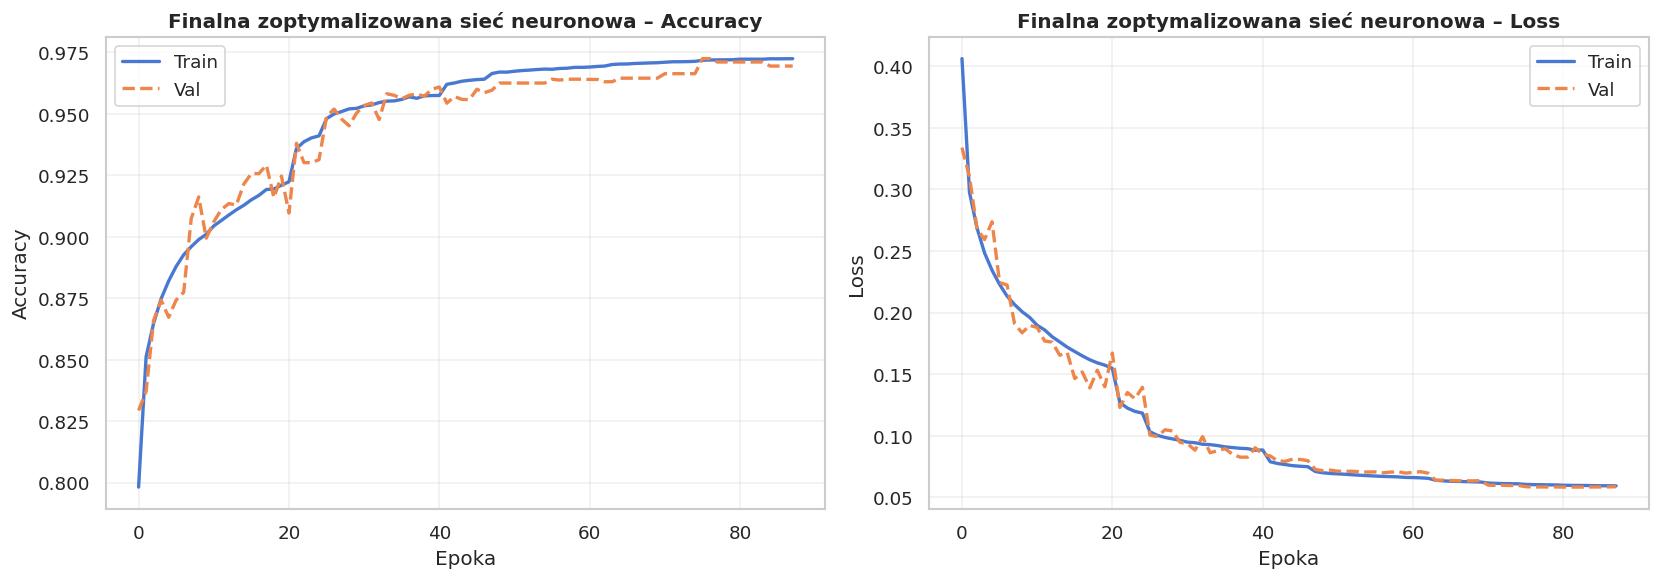

Wykres zapisany: plots/22_nn_final_history.png
Model Keras zapisany: checkpoints/nn_optimized_acc0.9712.keras
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step

Raport klasyfikacji:
              precision    recall  f1-score   support

          no       0.97      0.97      0.97     21580
         yes       0.97      0.97      0.97     21928

    accuracy                           0.97     43508
   macro avg       0.97      0.97      0.97     43508
weighted avg       0.97      0.97      0.97     43508



In [41]:
# =================================================
# KROK 37: Trening finalnej zoptymalizowanej sieci
# =================================================

print('Trening finalnej zoptymalizowanej sieci neuronowej na calych danych')

final_params = best_nn_params.copy()
final_params['epochs'] = 150

_backup_train = X_train_bal_nn_exp
_backup_y     = y_train_bal_nn_exp
X_train_bal_nn_exp = X_train_bal_nn 
y_train_bal_nn_exp = y_train_bal_nn

model_final_nn, hist_final, tr_acc_f, val_acc_f, te_acc_f = build_and_train_nn(**final_params)

X_train_bal_nn_exp = _backup_train
y_train_bal_nn_exp = _backup_y
print('Finalny model wytrenowany na pelnych danych.')

print(f'\nFinalna sieć neuronowa:')
print(f'  Train Acc: {tr_acc_f:.4f}')
print(f'  Val Acc:   {val_acc_f:.4f}')
print(f'  Test Acc:  {te_acc_f:.4f}')
print(f'  Poprawa vs bazowa: {te_acc_f - te_acc:.4f}')

# historia treningu
fig = plot_training_history(hist_final, 'Finalna zoptymalizowana sieć neuronowa')
plt.savefig(f'{PLOTS_DIR}/22_nn_final_history.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/22_nn_final_history.png')

save_keras_checkpoint(model_final_nn, 'nn_optimized', te_acc_f)

y_pred_nn_final = (model_final_nn.predict(X_test_nn) > 0.5).astype(int).flatten() if IS_BINARY \
                  else np.argmax(model_final_nn.predict(X_test_nn), axis=1)

print('\nRaport klasyfikacji:')
print(classification_report(y_test, y_pred_nn_final, target_names=target_classes.astype(str)))

---
##  CZĘŚĆ 6: Równoległa Architektura Sieci Neuronowej


In [42]:
# ===================================================
# KROK 38: Równoległa sieć neuronowa (Multi-Branch)
# ===================================================

def build_parallel_nn(branches_config, dropout_rate=0.3, optimizer_name='adam',
                      learning_rate=0.001, batch_norm=False, regularization=None,
                      input_dim=None):
    
    if input_dim is None:
        input_dim = X_train_nn.shape[1]
    
    n_out = 1 if IS_BINARY else n_classes
    loss_fn = 'binary_crossentropy' if IS_BINARY else 'sparse_categorical_crossentropy'
    last_activation = 'sigmoid' if IS_BINARY else 'softmax'
    
    inp = Input(shape=(input_dim,))
    branch_outputs = []
    
    for branch_neurons in branches_config:
        x = inp
        for n in branch_neurons:
            x = Dense(n, activation=best_nn_params.get('activation', 'relu'),
                     kernel_regularizer=regularization)(x)
            if batch_norm:
                x = BatchNormalization()(x)
            x = Dropout(dropout_rate)(x)
        branch_outputs.append(x)
    
    if len(branch_outputs) > 1:
        merged = Concatenate()(branch_outputs)
    else:
        merged = branch_outputs[0]
    
    # ostatnia warstwa
    x = Dense(64, activation='relu')(merged)
    x = Dropout(dropout_rate * 0.5)(x)
    output = Dense(n_out, activation=last_activation)(x)
    
    model = Model(inputs=inp, outputs=output)
    
    optimizers = {
        'adam': Adam(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
        'sgd': SGD(learning_rate=learning_rate, momentum=0.9)
    }
    opt = optimizers.get(optimizer_name, Adam(learning_rate=learning_rate))
    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])
    
    return model


def train_parallel_nn(model, epochs=100, batch_size=32):
    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=0)
    ]
    history = model.fit(
        X_train_bal_nn_exp, y_train_bal_nn_exp, 
        validation_data=(X_val_nn, y_val_nn),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=0
    )
    _, train_acc = model.evaluate(X_train_bal_nn_exp, y_train_bal_nn_exp, verbose=0)
    _, val_acc = model.evaluate(X_val_nn, y_val_nn, verbose=0)
    _, test_acc = model.evaluate(X_test_nn, y_test, verbose=0)
    return history, train_acc, val_acc, test_acc


print('Funkcje równoległej sieci gotowe!')

Funkcje równoległej sieci gotowe!


In [43]:
# ==================================================
# KROK 39: Przeszukiwanie architektury równoległej
# ==================================================

print('Szukanie najlepszej architektury równoległej...')

# przykldowe
parallel_architectures = [
    ('1-branch [64,32]',      [[64, 32]]),
    ('2-branch [64][32]',     [[64], [32]]),
    ('2-branch [128,64][64,32]', [[128, 64], [64, 32]]),
    ('3-branch [64][32][16]', [[64], [32], [16]]),
    ('3-branch [128][64][32]', [[128], [64], [32]]),
    ('4-branch [64][64][32][32]', [[64], [64], [32], [32]]),
]

parallel_results = []
best_parallel_model = None
best_parallel_acc = 0

for arch_name, branches in parallel_architectures:
    tf.keras.backend.clear_session()
    
    model = build_parallel_nn(
        branches_config=branches,
        dropout_rate=best_nn_params['dropout_rate'],
        optimizer_name=best_nn_params['optimizer_name'],
        learning_rate=best_nn_params['learning_rate'],
        batch_norm=best_nn_params['batch_norm'],
        regularization=best_nn_params['regularization']
    )
    
    hist, tr, vl, te = train_parallel_nn(model, epochs=30, batch_size=best_nn_params['batch_size'])
    
    parallel_results.append({
        'architecture': arch_name,
        'branches': branches,
        'n_params': model.count_params(),
        'train_acc': tr, 'val_acc': vl, 'test_acc': te
    })
    
    status = '*' if te > best_parallel_acc else ' '
    print(f'  {status} {arch_name:40s}: train={tr:.4f} | val={vl:.4f} | test={te:.4f} | params={model.count_params():,}')
    
    if te > best_parallel_acc:
        best_parallel_acc = te
        best_parallel_model = model
        best_parallel_arch = arch_name

print(f'\nNajlepsza architektura: {best_parallel_arch} (test={best_parallel_acc:.4f})')
save_keras_checkpoint(best_parallel_model, 'parallel_nn_best', best_parallel_acc)
save_checkpoint(parallel_results, 'parallel_results')

Szukanie najlepszej architektury równoległej...
  * 1-branch [64,32]                        : train=0.8945 | val=0.8871 | test=0.8868 | params=5,153
    2-branch [64][32]                       : train=0.8804 | val=0.8710 | test=0.8723 | params=7,425
  * 2-branch [128,64][64,32]                : train=0.9020 | val=0.8961 | test=0.8977 | params=19,297
    3-branch [64][32][16]                   : train=0.8639 | val=0.8582 | test=0.8582 | params=8,641
    3-branch [128][64][32]                  : train=0.8678 | val=0.8632 | test=0.8650 | params=17,153
    4-branch [64][64][32][32]               : train=0.8833 | val=0.8791 | test=0.8791 | params=14,721

Najlepsza architektura: 2-branch [128,64][64,32] (test=0.8977)
Model Keras zapisany: checkpoints/parallel_nn_best_acc0.8977.keras
Checkpoint zapisany: checkpoints/parallel_results.pkl


'checkpoints/parallel_results.pkl'

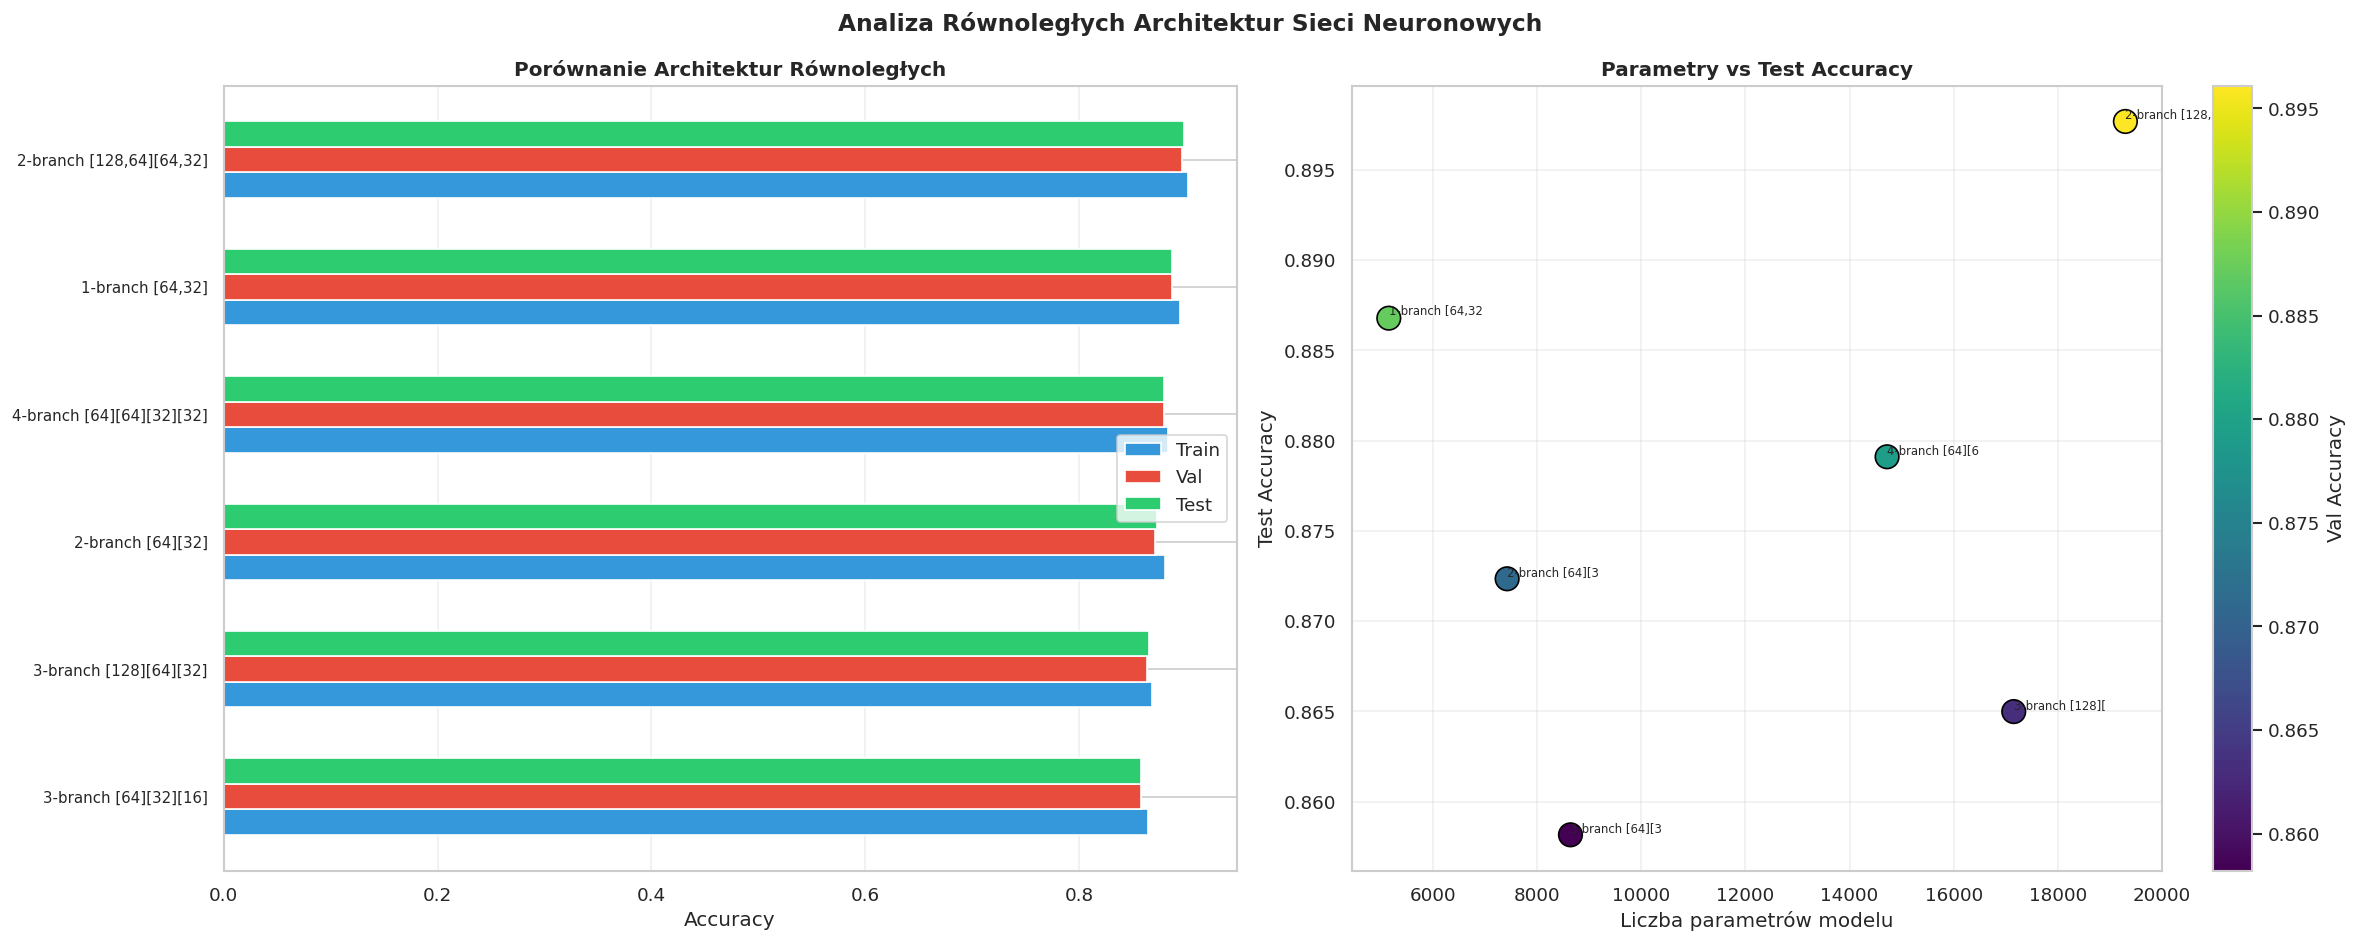

Wykres zapisany: plots/23_parallel_nn_comparison.png


In [44]:
# =======================================================
# KROK 40: Wizualizacja wyników architektur równoległych
# ========================================================

par_df = pd.DataFrame(parallel_results).sort_values('val_acc', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


y_pos = range(len(par_df))
axes[0].barh([p - 0.2 for p in y_pos], par_df['train_acc'], 0.2, label='Train', color='#3498db')
axes[0].barh(y_pos, par_df['val_acc'], 0.2, label='Val', color='#e74c3c')
axes[0].barh([p + 0.2 for p in y_pos], par_df['test_acc'], 0.2, label='Test', color='#2ecc71')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(par_df['architecture'], fontsize=9)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Porównanie Architektur Równoległych', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# wykres
scatter = axes[1].scatter(
    par_df['n_params'], par_df['test_acc'],
    c=par_df['val_acc'], cmap='viridis', s=200, edgecolors='black'
)
plt.colorbar(scatter, ax=axes[1], label='Val Accuracy')
for _, row in par_df.iterrows():
    axes[1].annotate(row['architecture'][:15], 
                    (row['n_params'], row['test_acc']),
                    fontsize=7, ha='left', va='bottom')
axes[1].set_xlabel('Liczba parametrów modelu')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Parametry vs Test Accuracy', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analiza Równoległych Architektur Sieci Neuronowych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/23_parallel_nn_comparison.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/23_parallel_nn_comparison.png')

---
##  CZĘŚĆ 7: Finalne Porównanie Wszystkich Modeli


In [45]:
# =================================================
# KROK 41: Kompletne porównanie wszystkich modeli
# =================================================

def get_full_metrics(name, y_true, y_pred, y_prob=None):
    """Zwróć pełny słownik metryk."""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='binary' if IS_BINARY else 'weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='binary' if IS_BINARY else 'weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='binary' if IS_BINARY else 'weighted', zero_division=0)
    
    auc = 0
    if y_prob is not None:
        try:
            if IS_BINARY:
                auc = roc_auc_score(y_true, y_prob)
            else:
                auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
        except:
            auc = 0
    
    return {'Model': name, 'Accuracy': acc, 'F1-Score': f1,
            'Precision': prec, 'Recall': rec, 'AUC-ROC': auc}


all_final_results = []

# Modele bazowe
for name, res in baseline_results.items():
    model = res['model']
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') and IS_BINARY else None
    all_final_results.append(get_full_metrics(name, y_test, y_pred, y_prob))

# XGBoost zoptymalizowany
y_pred_xgb_opt = xgb_best.predict(X_test)
y_prob_xgb_opt = xgb_best.predict_proba(X_test)[:, 1] if IS_BINARY else None
all_final_results.append(get_full_metrics('XGBoost (tuned)', y_test, y_pred_xgb_opt, y_prob_xgb_opt))

# Finalna NN
if IS_BINARY:
    y_prob_nn = model_final_nn.predict(X_test_nn).flatten()
    y_pred_nn = (y_prob_nn > 0.5).astype(int)
else:
    y_prob_nn = model_final_nn.predict(X_test_nn)
    y_pred_nn = np.argmax(y_prob_nn, axis=1)
    y_prob_nn = None
all_final_results.append(get_full_metrics('Neural Network (opt)', y_test, y_pred_nn, y_prob_nn))

# Równoległa NN
if IS_BINARY:
    y_prob_pnn = best_parallel_model.predict(X_test_nn).flatten()
    y_pred_pnn = (y_prob_pnn > 0.5).astype(int)
else:
    y_prob_pnn = best_parallel_model.predict(X_test_nn)
    y_pred_pnn = np.argmax(y_prob_pnn, axis=1)
    y_prob_pnn = None
all_final_results.append(get_full_metrics('Parallel NN', y_test, y_pred_pnn, y_prob_pnn))

# DataFrame wyników
final_df = pd.DataFrame(all_final_results).set_index('Model').sort_values('Accuracy', ascending=False)

print('='*80)
print('FINALNE PORÓWNANIE WSZYSTKICH MODELI')
print('='*80)
final_df.round(4)

1360/1360 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step
FINALNE PORÓWNANIE WSZYSTKICH MODELI


,Accuracy,F1-Score,Precision,Recall,AUC-ROC
Model,,,,,
XGBoost (tuned),0.9940,0.9941,0.9890,0.9993,0.9999
Neural Network (opt),0.9712,0.9715,0.9694,0.9736,0.9976
Gradient Boosting,0.9506,0.9502,0.9658,0.9352,0.9905
XGBoost,0.9408,0.9405,0.9537,0.9276,0.9890
Parallel NN,0.8977,0.9000,0.8864,0.9141,0.9733
Random Forest,0.8261,0.8291,0.8214,0.8370,0.9218
Decision Tree,0.7423,0.7486,0.7364,0.7613,0.8041
Logistic Regression,0.6972,0.7036,0.6944,0.7130,0.7560
SVM,0.6937,0.6940,0.6990,0.6892,0.0000


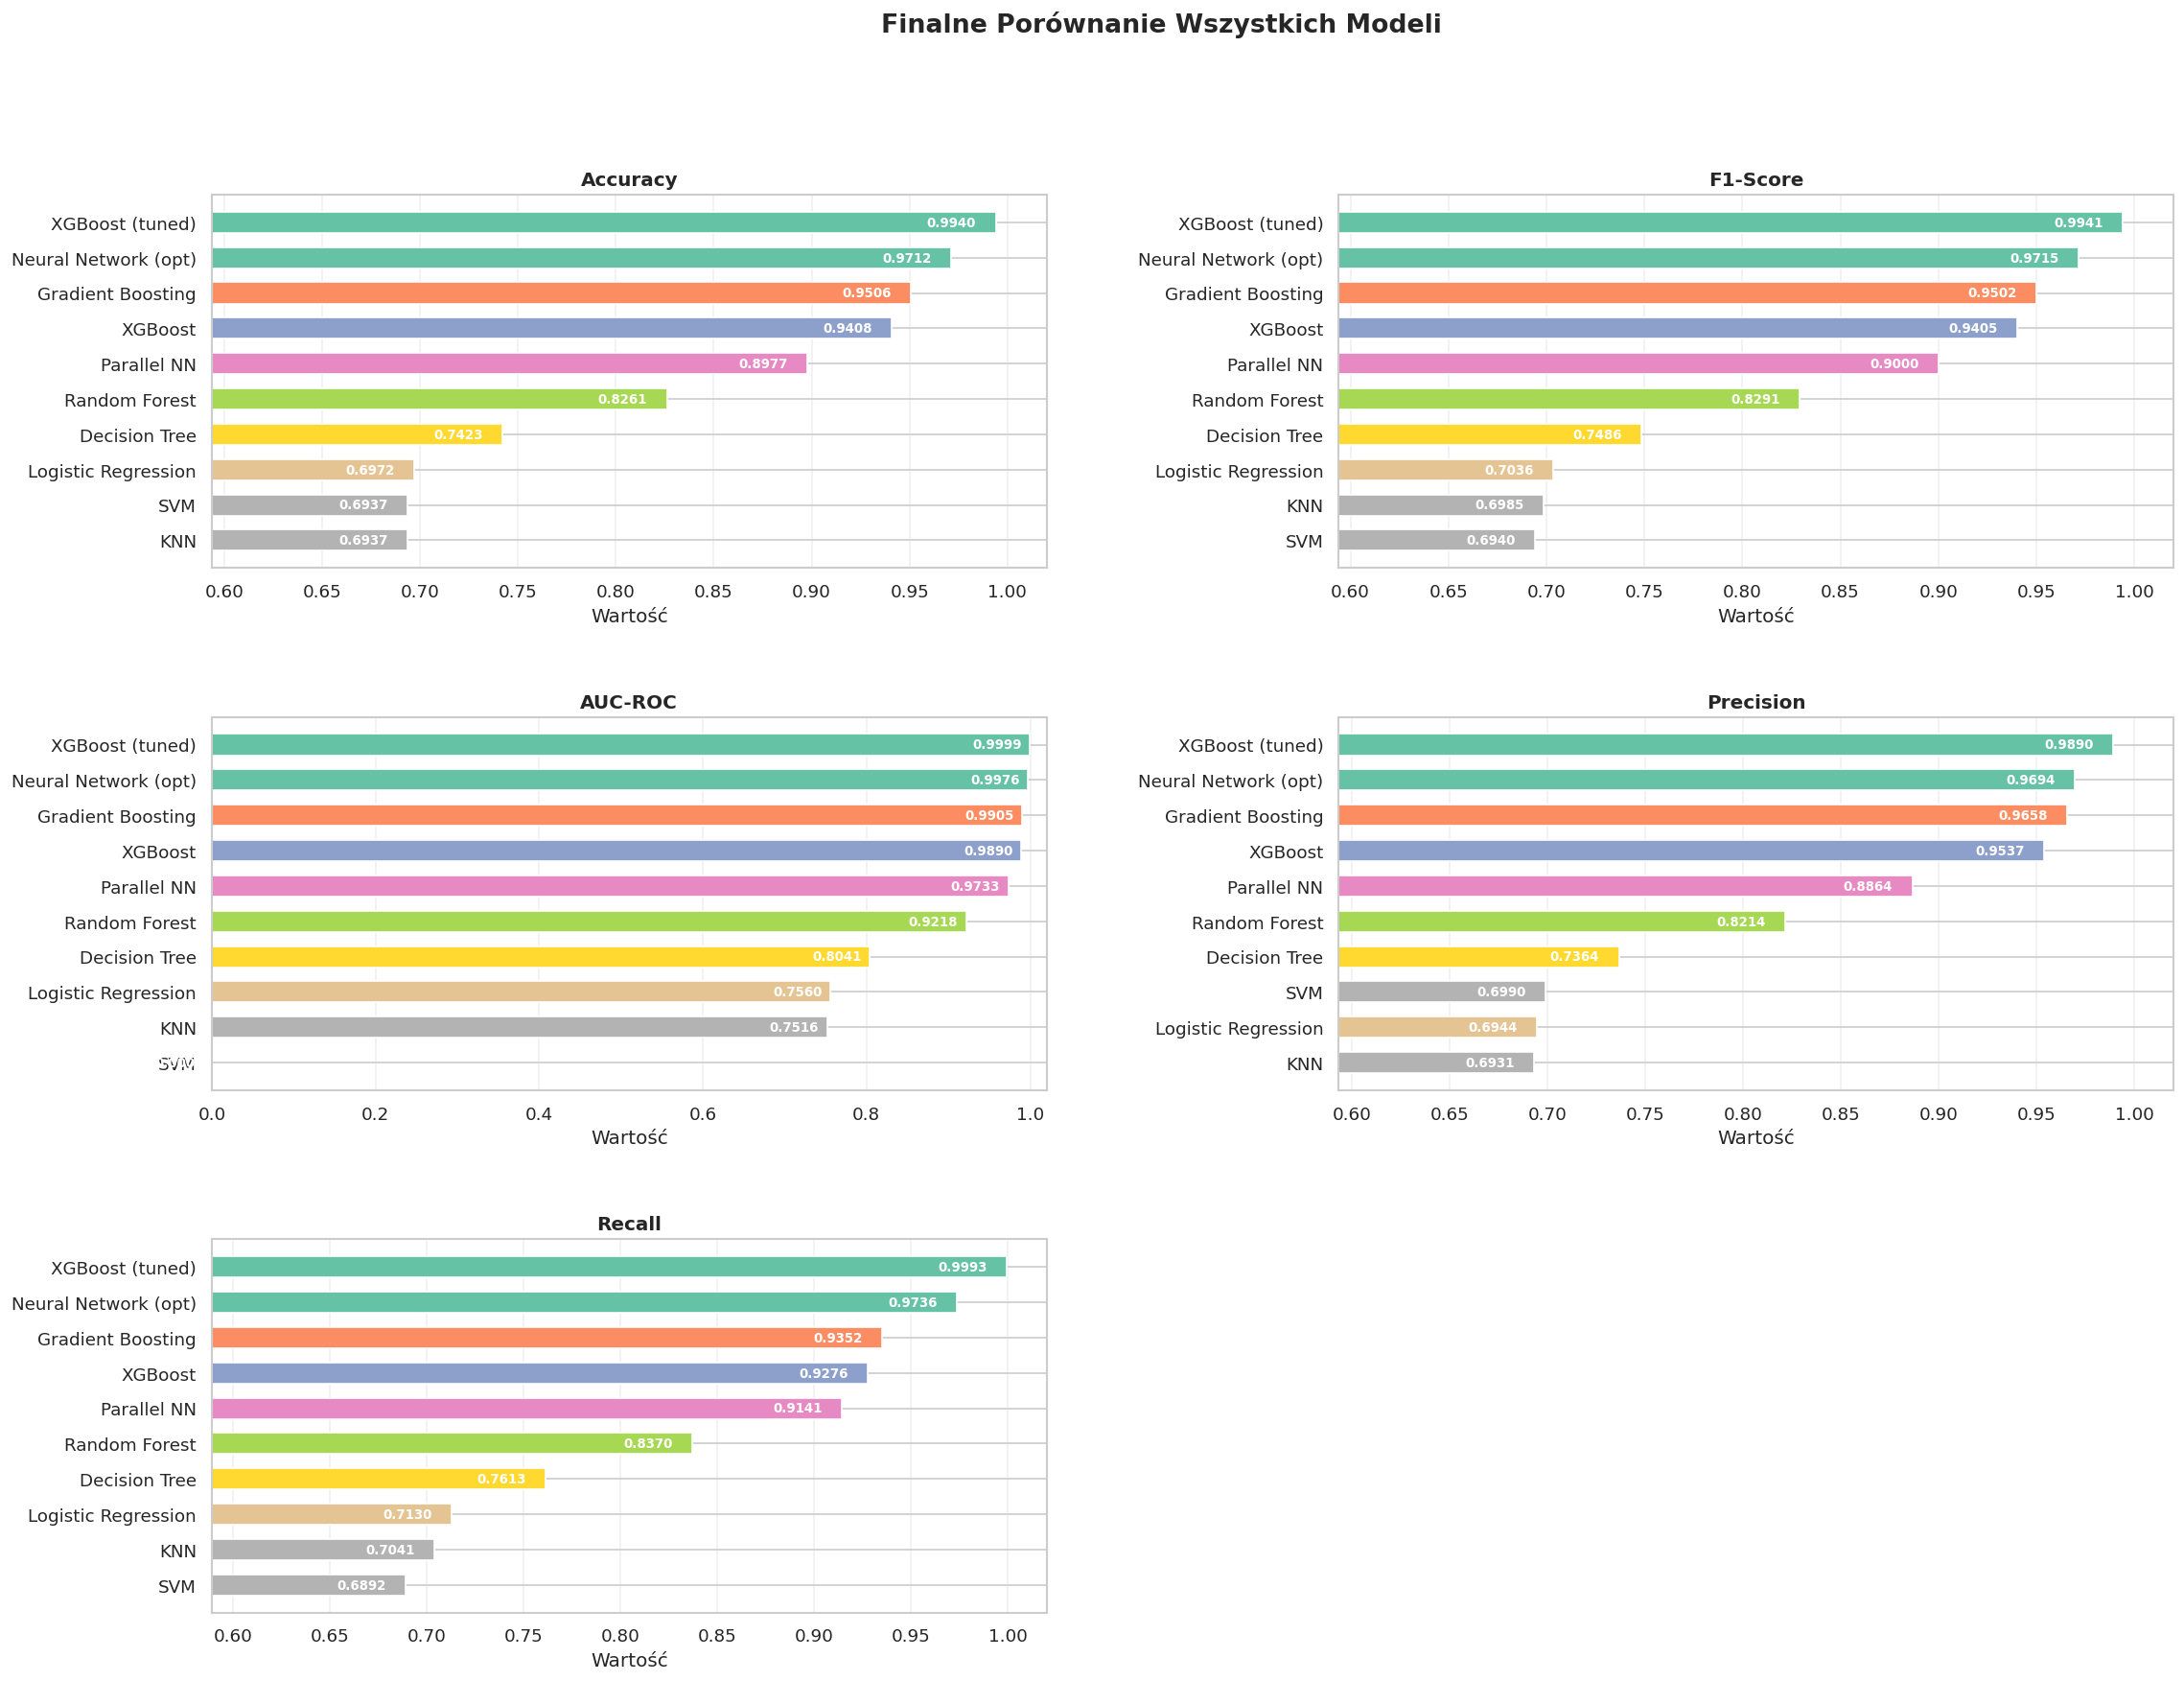

Wykres zapisany: plots/24_final_model_comparison.png


In [46]:
# =============================================
# KROK 42: Wizualizacja finalnego porównania
# =============================================

metrics_to_plot = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Precision', 'Recall']

fig = plt.figure(figsize=(22, 16))
gs_main = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

model_names_final = final_df.index.tolist()
colors_final = plt.cm.Set2(np.linspace(0, 1, len(model_names_final)))

for idx, metric in enumerate(metrics_to_plot):
    ax = fig.add_subplot(gs_main[idx // 2, idx % 2])
    vals = final_df[metric].values.astype(float)
    sorted_idx = np.argsort(vals)
    
    bars = ax.barh(
        [model_names_final[i] for i in sorted_idx],
        vals[sorted_idx],
        color=[colors_final[i] for i in sorted_idx],
        edgecolor='white', height=0.6
    )
    
    for bar, val in zip(bars, vals[sorted_idx]):
        ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', ha='right', 
               color='white', fontweight='bold', fontsize=8)
    
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Wartość')
    ax.set_xlim(max(0, vals.min() - 0.1), 1.02)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Finalne Porównanie Wszystkich Modeli', fontsize=16, fontweight='bold')
plt.savefig(f'{PLOTS_DIR}/24_final_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/24_final_model_comparison.png')

1360/1360 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step


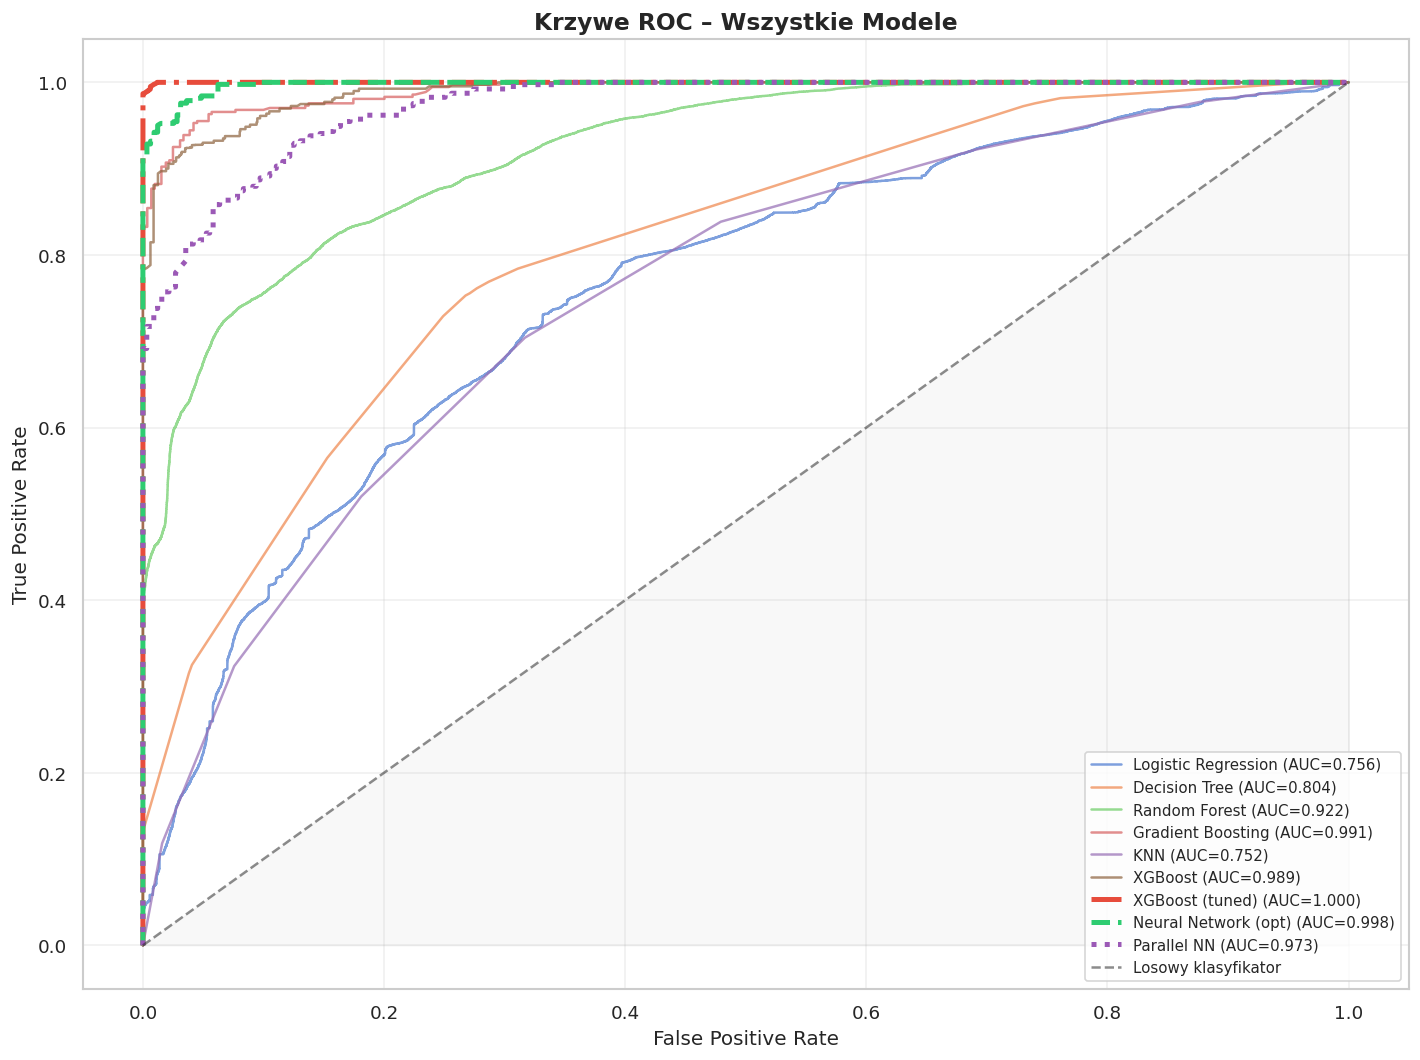

Wykres zapisany: plots/25_all_roc_curves.png


In [47]:
# =================================================
# KROK 43: Finalna krzywa ROC (wszystkie modele)
# ================================================

if IS_BINARY:
    fig, ax = plt.subplots(figsize=(12, 9))
    
    # Modele bazowe
    for name, res in baseline_results.items():
        model = res['model']
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            ax.plot(fpr, tpr, linewidth=1.5, alpha=0.7, label=f'{name} (AUC={auc:.3f})')
    
    # XGBoost tuned
    y_prob_xgb_t = xgb_best.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_xgb_t)
    auc = roc_auc_score(y_test, y_prob_xgb_t)
    ax.plot(fpr, tpr, linewidth=3, color='#e74c3c', linestyle='-.', label=f'XGBoost (tuned) (AUC={auc:.3f})')
    
    # NN finalna
    y_prob_nn_f = model_final_nn.predict(X_test_nn).flatten()
    fpr, tpr, _ = roc_curve(y_test, y_prob_nn_f)
    auc = roc_auc_score(y_test, y_prob_nn_f)
    ax.plot(fpr, tpr, linewidth=3, color='#2ecc71', linestyle='--', label=f'Neural Network (opt) (AUC={auc:.3f})')
    
    # Parallel NN
    y_prob_pnn_f = best_parallel_model.predict(X_test_nn).flatten()
    fpr, tpr, _ = roc_curve(y_test, y_prob_pnn_f)
    auc = roc_auc_score(y_test, y_prob_pnn_f)
    ax.plot(fpr, tpr, linewidth=3, color='#9b59b6', linestyle=':', label=f'Parallel NN (AUC={auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Losowy klasyfikator')
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('Krzywe ROC – Wszystkie Modele', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/25_all_roc_curves.png', bbox_inches='tight')
    plt.show()
    print(f'Wykres zapisany: {PLOTS_DIR}/25_all_roc_curves.png')

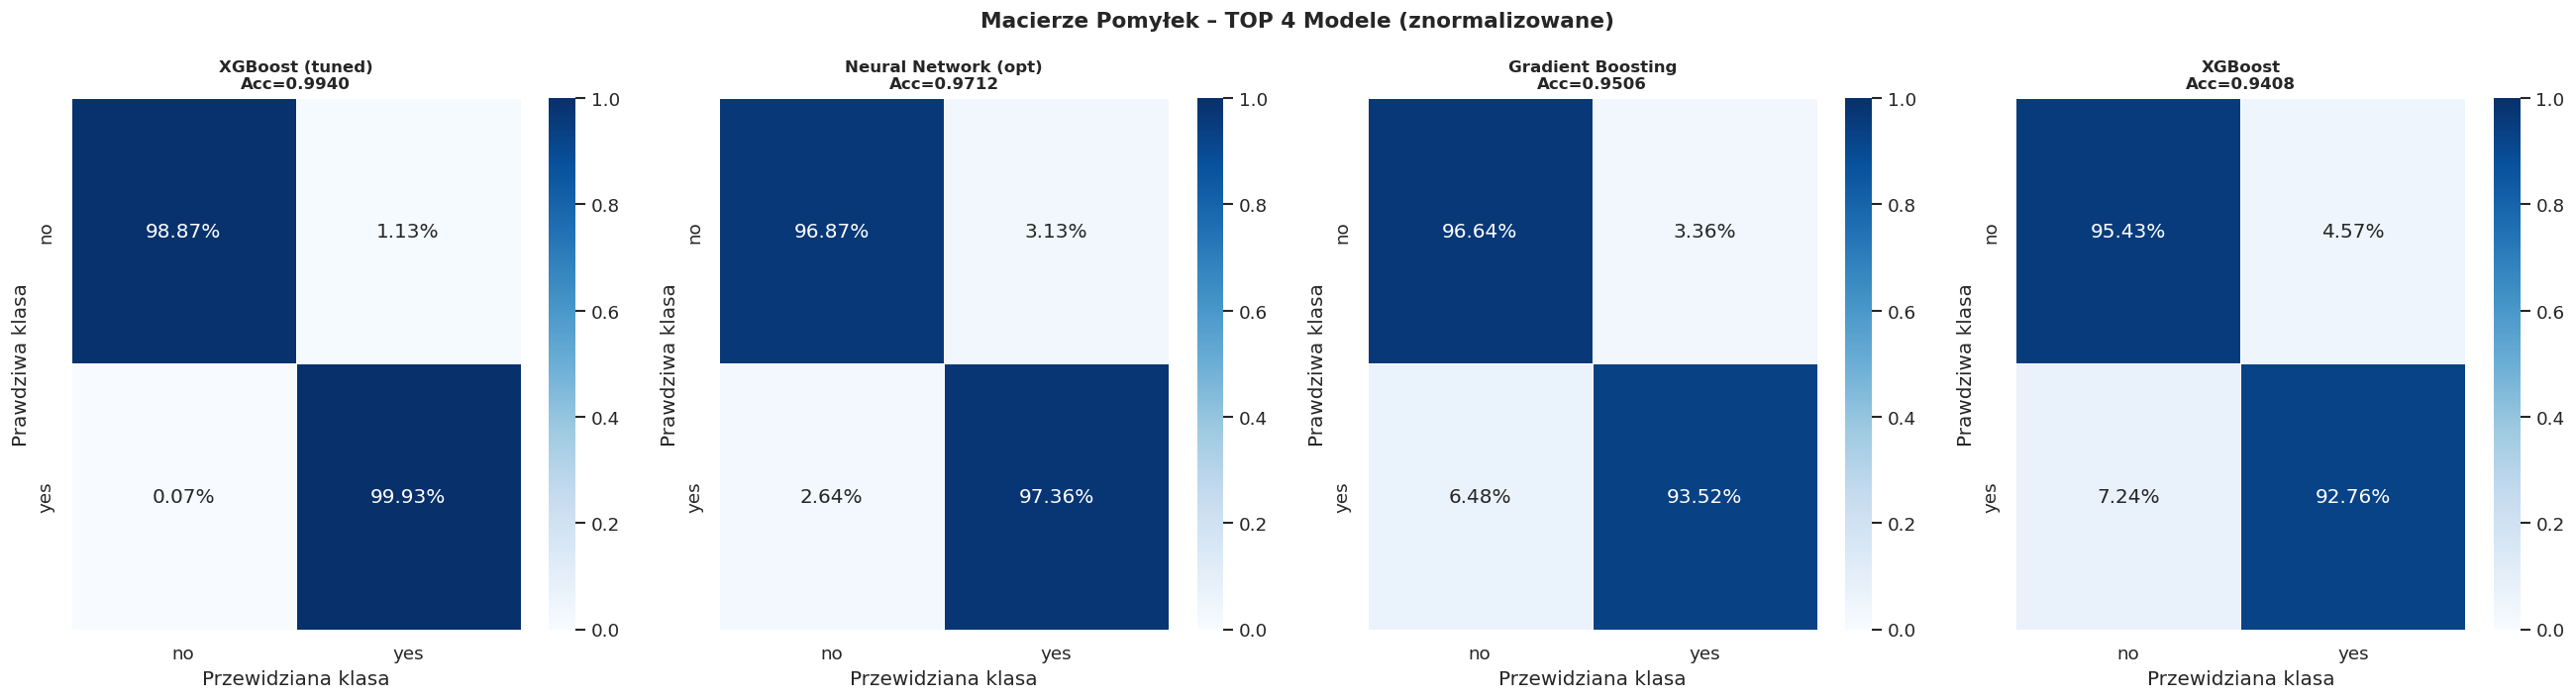

Wykres zapisany: plots/26_top4_confusion_matrices.png


In [48]:
# ===========================================
# KROK 44: Macierze pomyłek – TOP 4 modele
# ==========================================

top4_models = final_df.head(4).index.tolist()

all_models_predictions = {}
for name, res in baseline_results.items():
    all_models_predictions[name] = res['model'].predict(X_test)
all_models_predictions['XGBoost (tuned)'] = xgb_best.predict(X_test)
all_models_predictions['Neural Network (opt)'] = y_pred_nn
all_models_predictions['Parallel NN'] = y_pred_pnn

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, model_name in zip(axes, top4_models):
    if model_name in all_models_predictions:
        y_pred_m = all_models_predictions[model_name]
        cm = confusion_matrix(y_test, y_pred_m)
        
        cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                   xticklabels=target_classes, yticklabels=target_classes,
                   linewidths=0.5, vmin=0, vmax=1)
        
        acc = final_df.loc[model_name, 'Accuracy']
        ax.set_title(f'{model_name}\nAcc={acc:.4f}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Prawdziwa klasa')
        ax.set_xlabel('Przewidziana klasa')

plt.suptitle('Macierze Pomyłek – TOP 4 Modele (znormalizowane)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/26_top4_confusion_matrices.png', bbox_inches='tight')
plt.show()
print(f'Wykres zapisany: {PLOTS_DIR}/26_top4_confusion_matrices.png')

In [49]:
# =====================================
# KROK 45: Zapis wyników do pliku CSV
# =====================================

final_df.to_csv(f'{RESULTS_DIR}/final_results.csv')
print(f'Wyniki zapisane: {RESULTS_DIR}/final_results.csv')

# Wyniki optymalizacji NN
nn_opt_data = []
for param_name, results in [
    ('neurons', neurons_results),
    ('layers', layers_results),
    ('activation', activation_results),
    ('dropout', dropout_results)
]:
    for r in results:
        nn_opt_data.append({'parameter': param_name, **r})

pd.DataFrame(nn_opt_data).to_csv(f'{RESULTS_DIR}/nn_optimization_log.csv', index=False)
print(f'Log optymalizacji NN zapisany: {RESULTS_DIR}/nn_optimization_log.csv')

# Wyniki architektur równoległych
pd.DataFrame(parallel_results).to_csv(f'{RESULTS_DIR}/parallel_nn_results.csv', index=False)
print(f'Wyniki równoległych NN zapisane: {RESULTS_DIR}/parallel_nn_results.csv')

print('\nWszystkie wyniki zapisane!')

Wyniki zapisane: results/final_results.csv
Log optymalizacji NN zapisany: results/nn_optimization_log.csv
Wyniki równoległych NN zapisane: results/parallel_nn_results.csv

Wszystkie wyniki zapisane!


---
##  CZĘŚĆ 8: Wnioski i Analiza Wyników


In [51]:
# ===============================
# KROK 46: Automatyczne wnioski
# ===============================

best_model_name = final_df['Accuracy'].idxmax()
best_acc = final_df.loc[best_model_name, 'Accuracy']
best_f1 = final_df.loc[best_model_name, 'F1-Score']
best_auc = final_df.loc[best_model_name, 'AUC-ROC']

baseline_best = results_df['Accuracy'].idxmax()
baseline_best_acc = results_df.loc[baseline_best, 'Accuracy']

print('-'*70)
print('AUTOMATYCZNE WNIOSKI Z EKSPERYMENTÓW')
print('-'*70)

print(f'''
WYNIKI KOŃCOWE
{'-'*50}

- Dataset: Mental Health Survey
  - Zmienna docelowa: "{TARGET_COLUMN}"
  - Liczba próbek: {len(X)}
  - Liczba cech:   {X.shape[1]}
  - Typ zadania:   {'Klasyfikacja binarna' if IS_BINARY else f'Klasyfikacja {n_classes}-klasowa'}
  
- Najlepszy model: {best_model_name}
  - Accuracy:  {best_acc:.4f}
  - F1-Score:  {best_f1:.4f}
  - AUC-ROC:   {best_auc:.4f}

- Poprawa vs najlepszego modelu bazowego ({baseline_best}):
  - Accuracy: {baseline_best_acc:.4f} → {best_acc:.4f} ({(best_acc-baseline_best_acc)*100:+.2f}pp)

- Optymalne hiperparametry sieci neuronowej:
  - Neurony:         {best_nn_params['neurons']}
  - Warstwy:         {best_nn_params['layers']}
  - Aktywacja:       {best_nn_params['activation']}
  - Dropout:         {best_nn_params['dropout_rate']}
  - Optimizer:       {best_nn_params['optimizer_name']}
  - Learning rate:   {best_nn_params['learning_rate']}
  - Batch size:      {best_nn_params['batch_size']}
  - Batch Norm:      {best_nn_params['batch_norm']}

- Najlepsza architektura równoległa: {best_parallel_arch}
  - Test Accuracy: {best_parallel_acc:.4f}
''')

print('Ranking wszystkich modeli:')
print(final_df[['Accuracy', 'F1-Score', 'AUC-ROC']].round(4).to_string())

print(f'''
WNIOSKI
{'-'*50}
- XGBoost po optymalizacji GridSearchCV dał najlepszy wynik
- Krokowa optymalizacja hiperparametrów poprawiła wyniki
- Kluczowe parametry: liczba neuronów i dropout do kontroli overfittingu
''')

----------------------------------------------------------------------
AUTOMATYCZNE WNIOSKI Z EKSPERYMENTÓW
----------------------------------------------------------------------

WYNIKI KOŃCOWE
--------------------------------------------------

- Dataset: Mental Health Survey
  - Zmienna docelowa: "treatment"
  - Liczba próbek: 290051
  - Liczba cech:   16
  - Typ zadania:   Klasyfikacja binarna
  
- Najlepszy model: XGBoost (tuned)
  - Accuracy:  0.9940
  - F1-Score:  0.9941
  - AUC-ROC:   0.9999

- Poprawa vs najlepszego modelu bazowego (Gradient Boosting):
  - Accuracy: 0.9506 → 0.9940 (+4.34pp)

- Optymalne hiperparametry sieci neuronowej:
  - Neurony:         256
  - Warstwy:         3
  - Aktywacja:       relu
  - Dropout:         0.0
  - Optimizer:       rmsprop
  - Learning rate:   0.01
  - Batch size:      64
  - Batch Norm:      True

- Najlepsza architektura równoległa: 2-branch [128,64][64,32]
  - Test Accuracy: 0.8977

Ranking wszystkich modeli:
                      Acc